In [13]:
from src.reference_database.sequence_import import CustomFastaImport

fasta = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/diat-barcode-taxa_harmonized.fasta"
dt_class = CustomFastaImport(fasta)
dt_class.read_fasta(fasta)
dt_class.data

FileNotFoundError: Input file does not exist in the directory.

In [ ]:
pre_processed = dt_class.pre_process_harmonized_fasta()
pre_processed

: 

In [ ]:
import pandas as pd
dt_class.data = pd.concat(
            [dt_class.data, dt_class.data["taxa_info"].str.split("|", expand=True)], axis=1
        )

: 

In [ ]:
dt_class.data.columns = [
            "seq_id",
            "sequence",
            "length",
            "all_taxa_info",
            "original_taxa_info",
            "scientificName",
            "rank",
            "kingdom",
            "phylum",
            "class",
            "order",
            "family",
            "genus"
        ]

: 

In [ ]:
dt_class.data[dt_class.data['rank'] == 'CLASS']

: 

In [ ]:
dt_class.data['rank'] = dt_class.data['rank'].str.lower()

: 

In [ ]:
non_interest_ranks = ['kingdom', 'phylum', 'class', 'order']
dt_class.data = dt_class.data = dt_class.data[~dt_class.data['rank'].isin(non_interest_ranks)]

: 

In [ ]:
dt_class.data[dt_class.data['rank'] == 'class']

: 

In [ ]:
import numpy as np
dt_class.data = dt_class.data.replace("-", np.nan)

: 

In [ ]:
# Check entries with missing values for 'scientificName'
dt_class.data[dt_class.data['scientificName'].isnull()]

: 

In [ ]:
dt_class.data = dt_class.data.dropna(subset=["scientificName"], how="all")

: 

In [ ]:
# Check entries with missing values for 'scientificName'
dt_class.data[dt_class.data['scientificName'].isnull()]

: 

In [ ]:
species_variants = ['species', 'form', 'variety', 'subspecies']
dt_class.data['species'] = np.where(
    dt_class.data['rank'].str.lower().isin(species_variants),
    dt_class.data['scientificName'],  # Assign scientificName if condition is met
    np.nan  # Assign NaN otherwise
)
dt_class.data['species'] = dt_class.data['species'].str.split(' ').str[0] + ' ' + dt_class.data['species'].str.split(' ').str[1]

: 

In [ ]:
dt_class.data

: 

In [ ]:
otl_path = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/dia/Austria_taxonlist_diatoms_harmonized.tsv"

: 

In [ ]:
from src.marker_scoring.metrics_system import *

otl_handler = OtlHandler(otl_path)

otl = otl_handler.import_otl()
otl

: 

In [ ]:
tax = all_comp['taxa_info']
unq_taxa = tax.unique()
len(unq_taxa)

: 

In [ ]:
from src.reference_database.sequence_import import CustomFastaImport

fasta = "../data/test_data/fasta_example_file.fasta"
dt_class = CustomFastaImport(fasta)
dt_class.read_fasta(fasta)
dt_class.get_sequences()
dt_class.data


: 

In [ ]:
dt_class.get_mapping_between_seq_id_taxonomy()

: 

In [ ]:
from src.reference_database.sequence_import import CustomFastaImport

fasta = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/data/input_data/diat-barcode-taxa.fasta"
dt_class = CustomFastaImport(fasta)
dt_class.read_fasta(fasta)
diat_data_df = dt_class.data
diat_data_df.to_csv("try.csv")


: 

In [ ]:
dt_class.get_sequence_ids()

: 

In [ ]:
dt_class.get_sequence_lengths()

: 

-----------

In [ ]:
from src.reference_database.sequence_import import *

: 

In [ ]:
fasta= '../data/input_data/diat-barcode.fasta'
cls = CustomFastaImport(fasta)
cls.read_fasta(fasta)

: 

In [ ]:
dt_class.lineage_file

: 

In [ ]:
dt_class.lineage_file.columns.to_list()

: 

In [ ]:
from src.reference_database.db_curation import *
crabs = CrabsScriptGenerator()
json_file = "../src/reference_database/assign_tax_parameters.json"
crabs.run_assign_tax_command(json_file)

: 

## Test with Trial example
Issue: Fasta is not formatted as it should. Should not have tax id separated by ID -> affecting how PGA reads sequences

In [ ]:
def clean_fasta_headers(input_file, output_file):
    unique_tax = set()
    with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
        for line in infile:
            if line.startswith('>'):
                header = line.split(";", 2)
                seq_id = header[0].strip()
                tax_id = header[1].strip()
                unique_tax.add(tax_id)
                formatted_header = seq_id + " | " + tax_id + "\n"
                # print(formatted_header)
                outfile.write(formatted_header)
            else:
                outfile.write(line)

        print(len(unique_tax))

clean_fasta_headers("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/previous_software/reference.fasta", "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/previous_software/reference-taxa.fasta")

: 

In [ ]:
from src.in_silico_analysis.amplification import InSilicoAmplification
data = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/data/input_data/diat-barcode-taxa.fasta"
primer_table = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/data/input_data/diat-barcode-primers.tsv"
run_name = "diat-barcode-testimport"
cutadapt = InSilicoAmplification(data, run_name=run_name)
cutadapt.run_in_silico_analysis(primer_table=primer_table)

: 

### MultiBarcodeTools

In [ ]:
from src.marker_scoring.scoring_utils import create_MultiBarcodeTools_input

insert_path = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/data/output_data/diat-barcode-test/insert/filtered"
output_dir = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/data/output_data/diat-barcode-test/diat-multibarcode-insert.tsv"
create_MultiBarcodeTools_input(insert_path, output_dir)

: 

#### With joined incomplete pbs

In [ ]:
from src.marker_scoring.metrics_system import *

trait = TraitsAndResolution(results_folder="/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/diatoms-NEWRUN", otl="/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/dia/Austria_taxonlist_diatoms_harmonized.tsv")
output_str = trait.run_multibarcode_pipeline()
trait.parse_multibarcode_output(output_str)

mozaiko INFO: MultiBarcodeTools file created to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/diatoms-NEWRUN/insert/multibarcode/multibarcode_input.tsv
mozaiko INFO: MultiBarcodePipeline completed. Output in /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/diatoms-NEWRUN/insert/multibarcode


,primer,additional_resolved_species,cumulative_resolved_species
0,rbcL_708F_DEG_R3_DEG,912,912
1,rbcL_404F_646R,87,999
2,rbcL_39F_404R,46,1045
3,rbcL_998F_1229R,26,1071
4,rbcL_646F_998R,8,1079


: 

In [ ]:
trait.compute_taxonomic_resolution_per_taxon()

,input_taxa,family,genus,species,rank,rbcL_708F_DEG_R3_DEG,rbcL_404F_646R,rbcL_39F_404R,rbcL_998F_1229R,rbcL_646F_998R
0,Achnanthes brevipes var. brevipes,Achnanthaceae,Achnanthes,Achnanthes brevipes,species,NaN,NaN,NaN,NaN,NaN
1,Achnanthes brevipes var. intermedia Kutzing Cl...,Achnanthaceae,Achnanthes,Achnanthes intermedia,species,NaN,NaN,NaN,NaN,NaN
2,Achnanthes coarctata Brebisson ex W.Smith Grun...,Achnanthaceae,Achnanthes,Achnanthes coarctata,species,NaN,NaN,NaN,NaN,NaN
3,Achnanthes curtissima J.R.Carter 1963,Achnanthidiaceae,Psammothidium,Psammothidium microscopicum,species,NaN,NaN,NaN,NaN,NaN
4,Achnanthes exigua Grunow 1880,Achnanthaceae,Achnanthes,Achnanthes exigua,species,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1861,Zygnema pectinatum Vaucher C.Agardh,Zygnemataceae,Zygnema,Zygnema pectinatum,species,NaN,NaN,NaN,NaN,NaN
1862,Zygnema ralfsii Hassall de Bary,Zygnemataceae,Zygnema,Zygnema ralfsii,species,NaN,NaN,NaN,NaN,NaN
1863,Zygnema C.Agardh 1816,Zygnemataceae,Zygnema,NaN,genus,NaN,NaN,NaN,NaN,NaN
1864,Zygnema stellinum Vaucher C.Agardh,Zygnemataceae,Zygnema,Zygnema stellinum,species,NaN,NaN,NaN,NaN,NaN


: 

In [ ]:
from src.marker_scoring.metrics_system import *

trait.get_taxonomic_resolution()

,primer,total_taxa,n_taxa_above_cutoff,taxonomic_resolution
0,rbcL_708F_DEG_R3_DEG,1866,64,3.43
1,rbcL_404F_646R,1866,36,1.93
2,rbcL_39F_404R,1866,35,1.88
3,rbcL_998F_1229R,1866,49,2.63
4,rbcL_646F_998R,1866,58,3.11


: 

In [ ]:
trait.load_nucleotide_distance()

: 

#### without joined incomplete PBS

In [ ]:
from src.marker_scoring.metrics_system import *

trait = TraitsAndResolution(results_folder="/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/data/output_data/diat-barcode-test")
output_str = trait.run_multibarcode_pipeline()
trait.parse_multibarcode_output(output_str)

: 

In [ ]:
from src.reference_database.sequence_import import CustomFastaImport

insert_path = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/data/output_data/diat-barcode/all_inserts/rbcL_646F_998R.fasta"
cls = CustomFastaImport()
cls.read_fasta(insert_path)

: 

### Binding

In [ ]:
from src.marker_scoring.metrics_system import MetricsSystemExecutor

output_folder = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/old-diatoms-dereped"
otl1 = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/dia/Portugal_taxonlist_diatoms_harmonized.tsv"

cls = MetricsSystemExecutor(results_folder=output_folder, otl=otl1, primer_table='/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/DIA/diat-barcode-primers.tsv')

Set insert_folder_path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/old-diatoms-dereped/insert/filtered, amplicon_folder_path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/old-diatoms-dereped/amplicon and incomplete_pbs_path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/old-diatoms-dereped/incomplete_pbs/filtered.


: 

In [ ]:
cls.sort_otl_level_results()

: 

In [ ]:
abc = cls.get_reference_database_quality()
abc

: 

In [ ]:
primer_pbs, gc = cls.get_primer_pbs_analysis()

: 

In [ ]:
primerex = primer_pbs['rbcL_646F_998R']

: 

In [ ]:
primerex

: 

In [ ]:
primerex.to_csv("primerex.csv")

: 

In [ ]:
from src.marker_scoring.metrics_system import *

bind = Binding(otl=cls.otl)
result_full_len = bind.process_analysis_per_taxon(primerex, 'sum', 'full_len_mismatch_sum')

: 

In [ ]:
result_three_end = bind.process_analysis_per_taxon(primerex, 'max', 'three_end_mismatch_sum')

: 

In [ ]:
# GC Match Analysis
bind.get_total_gc_matches(primerex)
tax_lev_gc = bind.process_analysis_per_taxon(primerex, operation="min", analysis_name="gc_matches_score")
# Temperature Melting (Tm) Analysis
tax_lev_min_tm = bind.process_analysis_per_taxon(primerex, operation="min", analysis_name="min_tm")

: 

In [ ]:
ref_qual = cls.comprehensive_primer_analysis(output_folder, save_otl_level_results=True)

mozaiko INFO: Retrieving primer-PBS statistics.
mozaiko INFO: Retriving information on the Reference Database Quality.
mozaiko INFO: Calculating the number of barcodes per FASTA.
mozaiko INFO: Calculating the number of barcodes per FASTA.


: 

In [ ]:
ref_qual

,barcoded_taxa_one_plus,ratio_barcoded_taxa,mismatch_score,priming_ratio,gc_matches_across_taxon,min_tm_cv,tm_score
primer,,,,,,,
rbcL_708F_DEG_R3_DEG,32.74,0.36,0.68,0.10,0.0,0.66,17.73
rbcL_646F_998R,30.34,0.35,0.52,0.58,0.0,2.20,45.59


: 

In [ ]:
ref_qual

,barcoded_taxa_one_plus,ratio_barcoded_taxa,mismatch_score,priming_ratio_sum,gc_matches_across_taxon,min_tm_cv,tm_score
primer,,,,,,,
rbcL_708F_DEG_R3_DEG,32.74,0.36,0.68,10.23,0.0,0.66,17.73
rbcL_646F_998R,30.34,0.35,0.52,41.92,0.0,2.20,45.59


: 

In [ ]:
len(ref_qual[~ref_qual['full_len_mismatch_sum'].isnull()])

200

: 

In [ ]:
tax_lev_max_ms_full_len = cls.process_analysis_per_taxon(
    primer_pbs['rbcL_646F_998R'],
    operation="max",
    analysis_name="full_len_mismatch_sum",
)

AttributeError: 'MetricsSystemExecutor' object has no attribute 'process_analysis_per_taxon'

: 

In [ ]:
cls.get_traits_and_resolution()

: 

In [ ]:
metrics_df = cls.join_analysis_results()
metrics_df

: 

In [ ]:
ranked_df = cls.rank_primers(metrics_df, save_intermediate_ranks=False)
ranked_df

: 

##### ----------------------------------- END OF BINDING ---------------------------------------------

In [ ]:
from src.marker_scoring.scoring_utils import sequence_count_tracking

og_db = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/previous_software/reference-taxa.fasta"
analysis_fold = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/data/output_data/12S"
sequence_count_tracking(og_db, analysis_fold, save_results=False)

: 

## Mismatches

In [ ]:
from src.marker_scoring.metrics_system import *
from src.marker_scoring.scoring_utils import *

amp_folder = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/data/output_data/diat-barcode-harmonized-consensus/amplicon/filtered"
insert_folder = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/data/output_data/diat-barcode-harmonized-consensus/insert/filtered"
primer_table = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/DNAquaIMG/data/input_data/diat-barcode-primers.tsv"


cls_instance = Binding()
analysis_results, gc = cls_instance.primer_pbs_analysis(amp_folder, insert_folder, primer_table)

: 

In [ ]:
gc

: 

In [ ]:
otl = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/dia/Austria_taxonlist_diatoms_harmonized.tsv"

from src.marker_scoring.metrics_system import *

otl_handler = OtlHandler(otl)
otl_handler.import_otl()
total_otl_taxa_count = otl_handler.total_taxa
otl_unique_taxa_set = otl_handler.otl_taxa_set

: 

In [ ]:
process = cls_instance.iterate_over_primer_pbs_df(analysis_results, add_otl_taxa=False, otl_taxa_set=otl_unique_taxa_set)

: 

In [ ]:
attempt = cls_instance.get_primer_df('rbcL_708F_DEG_R3_DEG')

: 

In [ ]:
primer_pbs_df, primer_gc_df = cls_instance.primer_pbs_analysis(
    "../data/test_data/amplicon-test",
    "../data/test_data/insert-test",
    "../data/test_data/test_primer_table.tsv",
    save_results=False,
)

: 

In [ ]:
primer_pbs_df

: 

In [ ]:
gcm = cls_instance.get_total_gc_matches(attempt)
gcm['gc_matches_score'].max()

: 

In [ ]:
gcm_tax = cls_instance.process_analysis_per_taxon(primer_df=attempt, operation='min', analysis_name='gc_matches_score')
gcm_tax

: 

### -------------------------- HERE ---------------------

In [ ]:
from src.marker_scoring.metrics_system import *

otl = '/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/dia/Portugal_taxonlist_diatoms_harmonized.tsv'
tandres = TraitsAndResolution(otl, results_folder='/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/diat-barcode-test-fixed')
tandres.multibarcode_output_folder = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/diat-barcode-test-fixed/insert/multibarcode"
nuc_mat = tandres.load_nucleotide_distance()


: 

In [ ]:
nuc_mat

: 

In [ ]:
tandres.insert_folder_path

: 

In [ ]:
tandres.get_length_stats_for_amplicon_and_insert('/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/diat-barcode-test-fixed/insert/filtered', '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/diat-barcode-test-fixed/amplicon/filtered')

: 

In [ ]:
divergence2 = tandres.compute_genetic_divergence_per_taxon(save_results=True)

: 

In [ ]:
len(divergence2[divergence2['rbcL_708F3_R3_1'] > 2.0])

: 

In [ ]:
divergence = tandres.get_divergence_score()
divergence

: 

In [ ]:
abc = nuc_mat[(~nuc_mat['rbcL_646F_998R'].isnull()) & (nuc_mat['genus'] == 'Achnanthes')]
abc

: 

In [ ]:
# Transform columns that are not 'input_taxa', family', genus', 'species', 'rank' to numeric
str_columns = ['input_taxa', 'family', 'genus', 'species', 'rank']
numeric_columns = [col for col in nuc_mat.columns if col not in str_columns]
nuc_mat[numeric_columns] = nuc_mat[numeric_columns].apply(pd.to_numeric, errors='coerce')
nuc_mat.dtypes

: 

In [ ]:
abc2 = nuc_mat[(~nuc_mat['rbcL_646F_998R'].isnull()) & (nuc_mat['genus'] == 'Achnanthes')]
abc2

: 

In [ ]:
result = fill_hierarchical_values(abc2, 'min')
result

: 

In [ ]:
tandres.compute_genetic_divergence_per_taxon()

: 

In [ ]:
hyal = nuc_mat.loc[1]
hyal.items()

: 

In [ ]:
nuc_mat_species = nuc_mat['Species']
nuc_mat_species.to_csv("nuc_mat_species.csv")

: 

In [ ]:
import pandas as pd
test_multibarcode_600k = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-600k/insert/multibarcode/bmi_600k_multibarcodetest.tsv", sep="\t", header=None)
new_column_names = ['seq_id', 'primer', 'scientific_name', 'kingdom', 'phylum', 'class', 'order', 'family','seq']
test_multibarcode_600k.columns = new_column_names[:len(test_multibarcode_600k.columns)]
test_multibarcode_600k

: 

In [ ]:
unique_families = test_multibarcode_600k.groupby('family').size()
unique_families.sort_values(ascending=False)


: 

In [ ]:
unique_primers = test_multibarcode_600k.groupby('primer').size()
unique_primers.sort_values(ascending=False)

: 

### Checking largest primer

In [ ]:
largest_primer = test_multibarcode_600k[test_multibarcode_600k['primer'] == 'COI_FwhF2_FwhR2n']
largest_primer = largest_primer[['seq_id', 'primer', 'scientific_name', 'seq']]
largest_primer
# largest_primer.to_csv("fwh.tsv", sep="\t", index=False)

: 

#### By family

In [ ]:
largest_primer = test_multibarcode_600k[test_multibarcode_600k['primer'] == 'COI_FwhF2_FwhR2n']
unique_fam_prim = largest_primer.groupby('family').size()
unique_fam_prim.sort_values(ascending=False)

: 

In [ ]:
primer_subset = test_multibarcode_600k[test_multibarcode_600k[1] == 'COI_FwhF2_FwhR2n']
test_subset = primer_subset[test_multibarcode_600k[7] == 'Cecidomyiidae']
test_subset = test_subset[[0, 1, 2, 8]]
test_subset
test_subset.to_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-600k/insert/filtered/multibarcode/cecidomyiidae_fwh.tsv", sep='\t', index=False)

: 

#### By order

In [ ]:
largest_primer = test_multibarcode_600k[test_multibarcode_600k['primer'] == 'COI_FwhF2_FwhR2n']
unique_fam_prim = largest_primer.groupby('order').size()
unique_fam_prim.sort_values(ascending=False)

: 

In [ ]:
largest_primer = test_multibarcode_600k[test_multibarcode_600k['primer'] == 'COI_FwhF2_FwhR2n']
largest_prim_order =  largest_primer[largest_primer['order'] == 'Diptera']
largest_prim_order = largest_prim_order[['seq_id', 'primer', 'scientific_name', 'seq', ]]
largest_prim_order

: 

In [ ]:
largest_prim_order.to_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-600k/insert/multibarcode/mb-order-diptera/diptera-fwh.tsv", sep='\t', index=False, header=None)

: 

In [ ]:
with open("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-600k/insert/filtered/multibarcode/fwh_diptera.fasta", "w") as fasta_file:
    for _, row in largest_prim_order.iterrows():
        fasta_file.write(f">{row['seq_id']}|{row['scientific_name']}\n{row['seq']}\n")

: 

##### Order, clustered

In [ ]:
diptera_clustered = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-600k/insert/multibarcode/mb-order-diptera/diptera_clustered.csv", sep=",")
diptera_clustered

: 

#### Checking one-seq distribution per family

In [ ]:
def check_unique_families(test_multibarcode_600k, primer_list):
    for primer in primer_list:
        primer_df = test_multibarcode_600k[test_multibarcode_600k['primer'] == primer]

        unique_fam_prim = primer_df.groupby('family').size()
        fams_one_seq = unique_fam_prim[unique_fam_prim < 2].index.tolist()

        filtered_check_single_orders = test_multibarcode_600k[
            (test_multibarcode_600k['primer'] == primer) &
            (test_multibarcode_600k['family'].isin(fams_one_seq))
        ]

        print(f"Number of orders with families of one sequence for primer '{primer}':", filtered_check_single_orders['order'].nunique())

        # Step 6: Iterate over unique 'order' values to check for families not in the selected list
        for order_of_uniq_families in filtered_check_single_orders['order'].unique():
            order_rows = primer_df[primer_df['order'] == order_of_uniq_families]
            families_not_in_list = order_rows[~order_rows['family'].isin(fams_one_seq)]

            if not families_not_in_list.empty:
                print(f"    Order '{order_of_uniq_families}' has entries in 'family' that have more than one sequence.")

primer_list = [
    'COI_BF2_BR2',
    'COI_BF3_BR2',
    'COI_FwhF2_EPTDr2n',
    'COI_FwhF2_FwhR2n',
    'COI_MG2-LCO1490_MG2-univR',
    'COI_MICOIntF_HCO2198',
    'COI_fwhF2_Fol-degen-rev',
    'COI_mICOIintF_jgHCO2198'
]

check_unique_families(test_multibarcode_600k, primer_list)


: 

In [ ]:
fams_one_seq = unique_fam_prim[unique_fam_prim < 2].index.tolist()
print(fams_one_seq)

: 

In [ ]:
filtered_check_single_orders = test_multibarcode_600k[(test_multibarcode_600k['primer'] == 'COI_FwhF2_FwhR2n') & (test_multibarcode_600k['family'].isin(fams_one_seq))]
filtered_check_single_orders
#filtered_check_single_orders['order'].nunique()

: 

In [ ]:
for order_of_uniq_families in filtered_check_single_orders['order'].unique():
    order_rows = filtered_check_single_orders[filtered_check_single_orders['order'] == order_of_uniq_families]
    families_not_in_list = order_rows[~order_rows['family'].isin(fams_one_seq)]

    if not families_not_in_list.empty:
        print(f"Order '{order_of_uniq_families}' has entries in 'family' that only have on sequence:")
        print(families_not_in_list)

: 

In [ ]:
# group by primer, family
family_primer_counts = test_multibarcode_600k.groupby([1, 7]).size().reset_index(name='count')
min_max_per_primer = family_primer_counts.groupby(1)['count'].agg(['min', 'max'])

print(min_max_per_primer)


: 

In [ ]:
# Total: 3703067
import pandas as pd
file_path = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/external_scripts/test_order.tsv"
df = pd.read_csv(file_path, sep='\t')

def get_analysis_order_of_magnitude(df):
    levels = {
        "phylum": 4,
        "class": 5,
        "order": 6,
        "family": 7
    }

    for level, col in levels.items():
        grouped_counts = df.groupby(df.columns[col]).size()

        min_count = grouped_counts.min()
        max_count = grouped_counts.max()
        mean_count = grouped_counts.mean()

        print(f"\nStatistics for {level} level:")
        print(f"  Unique groups: {len(grouped_counts)}")
        print(f"  Min entries per file: {min_count}")
        print(f"  Max entries per file: {max_count}")

get_analysis_order_of_magnitude(df)

: 

In [ ]:
import os
import pandas as pd

def filter_tsv_files(folder_path):
    # List all TSV files in the folder
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".tsv"):
            file_path = os.path.join(folder_path, file_name)

            # Read the TSV file
            df = pd.read_csv(file_path, sep='\t')

            # Check if 'phylum' column exists
            if 'phylum' in df.columns:
                # Filter out unwanted phyla
                df = df[~df['phylum'].isin(['Rhodophyta', 'Chordata', 'Tracheophyta'])]

                # Save the cleaned file (overwrite or create new file)
                output_path = os.path.join(folder_path, f"filtered_{file_name}")
                df.to_csv(output_path, sep='\t', index=False)
                print(f"Processed: {file_name} -> Saved as {output_path}")
            else:
                print(f"Skipping {file_name}: No 'phylum' column found.")

# Example usage
folder_path = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi"
filter_tsv_files(folder_path)

Processed: Poland_taxonlist_bmi_harmonized.tsv -> Saved as /home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_Poland_taxonlist_bmi_harmonized.tsv
Processed: Sweden_taxonlist_bmi_harmonized.tsv -> Saved as /home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_Sweden_taxonlist_bmi_harmonized.tsv
Processed: Austria_taxonlist_bmi_harmonized.tsv -> Saved as /home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_Austria_taxonlist_bmi_harmonized.tsv
Processed: Czech_taxonlist_bmi_harmonized.tsv -> Saved as /home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_Czech_taxonlist_bmi_harmonized.tsv
Processed: Germany_taxonlist_bmi_harmonized.tsv -> Saved as /home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_Germany_taxonlist_bmi_harmonized.tsv
Processed: Portugal_taxonlist_bmi_harmonized.tsv -> Saved as /home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_Portug

: 

In [ ]:
from src.marker_scoring.metrics_system import ReferenceDatabaseQuality

refb = ReferenceDatabaseQuality(all_inserts_path='/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/diat.barcode_earlier_results/insert/filtered', otl='/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/dia/Austria_taxonlist_diatoms_harmonized.tsv')
barcodes_per_entry = refb.calculate_number_of_barcodes_per_fasta_entry()
barcodes_per_entry
# refb.taxa_hierarchy
#refb.calculate_number_of_barcodes_per_otl_taxonomy(barcodes_per_entry, refb.taxa_hierarchy)

: 

## Joining multibarcode results and checking missing entries

In [ ]:
import pandas as pd
merged = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-phyl/mulitbarcode/merged_matrices.csv", sep='\t')
merged

: 

In [ ]:
merged_families = merged['SourceFolder'].unique()
len(merged_families)

: 

In [ ]:
abc = unique_fam_prim
# Retrieve names of families
lista = abc.index.to_list()
# save the list in a file
with open('families.txt', 'w') as filehandle:
    for listitem in lista:
        filehandle.write('%s\n' % listitem)

: 

In [ ]:
# CHheck which families are missing from 'SourceFolder' compared to a file
file = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/families.txt'
merged_families = merged['SourceFolder'].unique()

with open(file, 'r') as f:
    source_families = f.read().splitlines()

missing_families = [fam for fam in source_families if fam not in merged_families]
missing_families

: 

In [ ]:
len(missing_families)

: 

In [ ]:
# Count unqie values in 'SourceFolder' column
merged[['SourceFolder']].nunique()

: 

## Check 'rc' removal

In [ ]:
test_path = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-phyl/mulitbarcode/COI_BF3_BR2"

from src.marker_scoring.scoring_utils import remove_rc_suffix_from_fasta_files

remove_rc_suffix_from_fasta_files(test_path)

: 

In [ ]:
from src.marker_scoring.metrics_system import Binding

results_folder = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/diatoms-additional-primers"
bd = Binding(otl='/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Austria_taxonlist_bmi_harmonized.tsv')
bd.get_outputs_taxa_counts(results_folder)

: 

In [ ]:
from src.marker_scoring.scoring_utils import sequence_count_tracking

og_db = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi_database_processed.fasta"
analysis_fold = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-phyl-just-amplification"
sequence_count_tracking(og_db, analysis_fold, save_results=False)

: 

In [ ]:
from src.marker_scoring.scoring_utils import sequence_count_tracking

og_db = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi_database_processed.fasta"
analysis_fold = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-phyl"
sequence_count_tracking(og_db, analysis_fold, save_results=False)

: 

In [ ]:
from src.marker_scoring.scoring_utils import sequence_count_tracking

og_db = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi_database_processed.fasta"
analysis_fold = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-phyl"
sequence_count_tracking(og_db, analysis_fold, save_results=False)

: 

In [ ]:
from src.marker_scoring.metrics_system import *

insert_folder_path = "data/output_data/DIA-catnip-1st-run/insert/filtered"
incomplete_pbs_path = "data/output_data/DIA-catnip-1st-run/incomplete_pbs/filtered"
otl = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized.tsv"

otl_handler = OtlHandler(otl)
otl_handler.import_otl()
total_otl_taxa_count = otl_handler.total_taxa
otl_unique_taxa_set = otl_handler.otl_taxa_set


with tempfile.TemporaryDirectory() as temp_dir:
    all_inserts_path = os.path.join(temp_dir, "all_inserts")
    os.makedirs(all_inserts_path, exist_ok=True)

    for folder in [insert_folder_path, incomplete_pbs_path]:
        if os.path.exists(folder):
            for file in os.listdir(folder):
                src = os.path.join(folder, file)
                dest = os.path.join(all_inserts_path, file)

                if os.path.isfile(src):
                    shutil.copy(src, dest)

    red_bd_qual = ReferenceDatabaseQuality(
        otl=otl, all_inserts_path=all_inserts_path
    )
    # reference_db_quality = red_bd_qual.barcoded_taxa_ratio(
    #     total_taxa_count=total_otl_taxa_count
    # )

#     barcoded_taxa_five_plus = red_bd_qual.calculate_percentage_of_taxa_w_x_barcodes(
#     total_otl_taxa_count, barcode_threshold=5
# )
    barcoded_taxa_one_plus = red_bd_qual.calculate_percentage_of_taxa_w_x_barcodes(
    total_otl_taxa_count, barcode_threshold=1
)

mozaiko INFO: The OTL does not exist. Exiting...


SystemExit: 1

In [ ]:
barcoded_taxa_five_plus

: 

In [ ]:
barcoded_taxa_one_plus

: 

In [ ]:
# OG
reference_db_quality

: 

In [ ]:
from pathlib import Path

def extract_third_element_from_fasta(fasta_path):
    third_elements = []
    with open(fasta_path, 'r') as file:
        for line in file:
            if line.startswith('>'):
                parts = line[1:].strip().split('|')
                if len(parts) >= 3:
                    third_elements.append(parts[2])
    return third_elements


fasta_file = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-phyl/insert/filtered/COI_FwhF2_FwhR2n.fasta"
third_elements_list = extract_third_element_from_fasta(fasta_file)
print(third_elements_list)

: 

In [ ]:
COI_FwhF2_FwhR2n_taxa =  extract_third_element_from_fasta("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-phyl/insert/filtered/COI_FwhF2_FwhR2n.fasta")
COI_FwhF2_EPTDr2n_taxa =  extract_third_element_from_fasta("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-phyl/insert/filtered/COI_FwhF2_EPTDr2n.fasta")
COI_BF2_BR2_taxa =  extract_third_element_from_fasta("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-phyl/insert/filtered/COI_BF2_BR2.fasta")
COI_BF3_BR2_taxa = extract_third_element_from_fasta("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-phyl/insert/filtered/COI_BF3_BR2.fasta")

: 

In [ ]:
type(COI_BF3_BR2_taxa)

: 

In [ ]:
unique_german_scientific_names = otl_handler.otl['scientificName'].unique()

: 

In [ ]:
len(unique_german_scientific_names)

: 

In [ ]:
common_COI_FwhF2_FwhR2n_taxa= set(COI_FwhF2_FwhR2n_taxa) & set(unique_german_scientific_names)
common_COI_FwhF2_EPTDr2n_taxa = set(COI_FwhF2_EPTDr2n_taxa) & set(unique_german_scientific_names)
common_COI_BF2_BR2_taxa = set(COI_BF2_BR2_taxa) & set(unique_german_scientific_names)
common_COI_BF3_BR2_taxa = set(COI_BF3_BR2_taxa) & set(unique_german_scientific_names)

: 

In [ ]:
print("COI_FwhF2_FwhR2n taxa in OTL:", len(common_COI_FwhF2_FwhR2n_taxa))
print("COI_FwhF2_EPTDr2n taxa in OTL:", len(common_COI_FwhF2_EPTDr2n_taxa))
print("COI_BF2_BR2 taxa in OTL:", len(common_COI_BF2_BR2_taxa))
print("COI_BF3_BR2 taxa in OTL:", len(common_COI_BF3_BR2_taxa))

: 

In [ ]:
from src.in_silico_analysis.amplification import InSilicoAmplification

insil = InSilicoAmplification()

insil.remove_intersection_sequences(input_path="/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/test_data/test_filter_intersection/test_input_path",
                                                    filter_path="/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/test_data/test_filter_intersection/test_filter_path")

: 

In [ ]:
from src.marker_scoring.scoring_utils import sequence_count_tracking

og_db = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/DIA/diat_barcode_hrm_dreped_processed.fasta"
analysis_fold = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/diatoms-NEWRUN"
sequence_count_tracking(og_db, analysis_fold, save_results=False)

: 

In [ ]:
from src.marker_scoring.scoring_utils import sequence_count_tracking

og_db = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/DIA/diat_barcode_hrm_dreped_processed.fasta"
analysis_fold = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/diatoms-NEWRUN"
sequence_count_tracking(og_db, analysis_fold, save_results=False)

mozaiko INFO: Number of sequences in original database: 7297
mozaiko INFO: Percentage calculations completed successfully.


,all_complete_pbs,amplicon,incomplete_pbs,insert,input_B,all_complete_pbs-input_ABC,incomplete_pbs-input_AC,insert-input_A,percentage_of_sequences_with_PBS,percentage_of_amplified_sequences_with_PBS
primer_name,,,,,,,,,,
rbcL_646F_998R,3748,3572,3728,3572,17,3745,3728,3571,95.81,99.53
rbcL_708F-DEG_R3-DEG,4043,3768,4016,3768,23,4039,4016,3767,93.84,99.39
rbcL_rbcL_39F_404R,2617,1930,2568,1930,47,2615,2568,1930,75.60,97.62
rbcL_rbcL_404F_646R,3894,3716,3869,3716,19,3888,3869,3714,96.01,99.49
rbcL_rbcL_998F_1229R,3123,3064,3097,3064,22,3119,3097,3064,98.94,99.29


: 

In [ ]:
from src.marker_scoring.scoring_utils import sequence_count_tracking

og_db = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi_database_processed.fasta"
analysis_fold = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN copy"
sequence_count_tracking(og_db, analysis_fold, save_results=False)

mozaiko INFO: Number of sequences in original database: 623311
mozaiko ERROR: Error processing file /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN copy/insert/COI_JgLCO1490_jgHCO2198.fasta: Command '['grep', '-c', '^>', '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN copy/insert/COI_JgLCO1490_jgHCO2198.fasta']' returned non-zero exit status 1.
mozaiko ERROR: Error processing file /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN copy/insert/input_A/COI_JgLCO1490_jgHCO2198.fasta: Command '['grep', '-c', '^>', '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN copy/insert/input_A/COI_JgLCO1490_jgHCO2198.fasta']' returned non-zero exit status 1.
mozaiko ERROR: Error processing file /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN copy/input_B/COI_JgLCO1490_jgHCO2198

,all_complete_pbs,amplicon,incomplete_pbs,insert,input_B,all_complete_pbs-input_ABC,incomplete_pbs-input_AC,insert-input_A,percentage_of_sequences_with_PBS,percentage_of_amplified_sequences_with_PBS
primer_name,,,,,,,,,,
COI_BF2_BR2,500104.0,5646.0,499640.0,5642.0,458.0,500045.0,499587.0,5638.0,1.22,92.49
COI_BF3_BR2,500136.0,5692.0,499672.0,5688.0,458.0,500076.0,499618.0,5685.0,1.23,92.54
COI_FwhF2_EPTDr2n,587194.0,381907.0,382051.0,381907.0,205076.0,587127.0,382051.0,381882.0,99.97,65.06
COI_FwhF2_FwhR2n,617718.0,599206.0,608757.0,599206.0,8894.0,617639.0,608745.0,599163.0,98.45,98.54
COI_JgLCO1490_jgHCO2198,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
COI_MG2-LCO1490_MG2-univR,234296.0,6148.0,234061.0,6148.0,233.0,234129.0,233896.0,6147.0,2.72,96.35
COI_MICOIntF_HCO2198,493383.0,2007.0,492145.0,2007.0,1234.0,493328.0,492094.0,2004.0,0.66,61.89
COI_fwhF2_Fol-degen-rev,493951.0,2727.0,493329.0,2727.0,618.0,493896.0,493278.0,2723.0,0.68,81.50
COI_mICOIintF_jgHCO2198,493629.0,2679.0,492969.0,2679.0,656.0,493574.0,492918.0,2675.0,0.67,80.31


: 

In [ ]:
import os

def check_taxon_in_fasta_headers(
    base_dir,
    target_folders,
    fasta_filenames,
    taxon_to_find
):
    found_matches = []

    for folder in target_folders:
        folder_path = os.path.join(base_dir, folder)
        # print(f"Checking folder: {folder_path}")
        for fasta_file in fasta_filenames:
            path = os.path.join(folder_path, fasta_file)
            # print(f"Checking file: {path}")
            if not os.path.isfile(path):
                continue

            with open(path, 'r') as f:
                for line in f:
                    if line.startswith('>'):
                        parts = line.strip().lstrip('>').split('|')
                        # print(parts[2].strip())
                        if len(parts) >= 3 and parts[2].strip() == taxon_to_find:
                            found_matches.append((path, line.strip()))
                            break  # One match per file is enough for reporting

    if found_matches:
        print(f"\n Found '{taxon_to_find}' in the following FASTA files:")
        for filepath, header in found_matches:
            print(f"- {filepath}")
    else:
        print(f"\n Taxon '{taxon_to_find}' not found in specified FASTA files.")


base_dir = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN"
target_folders = [
    "all_complete_pbs", "all_complete_pbs/filtered",
    "amplicon", "incomplete_pbs", "incomplete_pbs/filtered",
    "insert", "insert/filtered", "input_B"
]

fasta_filenames = ["COI_BF3_BR2.fasta", "COI_FwhF2_FwhR2n.fasta"]
taxon_to_search = "Abacarus oplismeni"

check_taxon_in_fasta_headers(base_dir, target_folders, fasta_filenames, taxon_to_search)



 Found 'Abacarus oplismeni' in the following FASTA files:
- /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN/all_complete_pbs/COI_FwhF2_FwhR2n.fasta
- /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN/all_complete_pbs/filtered/COI_FwhF2_FwhR2n.fasta
- /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN/amplicon/COI_FwhF2_FwhR2n.fasta
- /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN/incomplete_pbs/COI_FwhF2_FwhR2n.fasta
- /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN/incomplete_pbs/filtered/COI_FwhF2_FwhR2n.fasta
- /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN/insert/COI_FwhF2_FwhR2n.fasta
- /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN/insert/filtered/COI_FwhF2_FwhR2n.

: 

In [ ]:
from src.marker_scoring.metrics_system import MetricsSystemExecutor

output_folder = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN"
otl1 = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/ref-db/referencedatabase_taxonlist_bmi_harmonized.tsv"
primer_table='/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi-primers.tsv'

cls = MetricsSystemExecutor(results_folder=output_folder, otl=otl1, primer_table='/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi-primers.tsv')

Set insert_folder_path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN/insert/filtered, amplicon_folder_path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN/amplicon and incomplete_pbs_path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN/incomplete_pbs/filtered.


: 

In [ ]:
# Intake data
from src.reference_database.sequence_import import *

database_file = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN/incomplete_pbs/filtered/COI_BF3_BR2.fasta"

custom_fasta_import = CustomFastaImport(database_file)
custom_fasta_import.read_fasta(database_file, check_taxid=False)
data = custom_fasta_import.data
data.head()

,seq_id,sequence,length,taxa_info
0,AAGRE003-21,AATAAATAATATAAGTTTTTGATTACTACCCCCCTCATTAACCCTT...,418,Atylotus agrestis|Atylotus agrestis Wiedemann ...
1,ABEE094-17,AATAAATAATATTAGATTTTGATTATTACCACCATCATTAATCTTA...,418,Dioxys cinctus|Dioxys cinctus Jurine 1807|spec...
2,ABEE097-17,AATAAATAATATAAGATTTTGGCTACTCCCCCCTTCAATTCTAATT...,418,Andrena pilipes|Andrena pilipes Fabricius 1781...
3,ABEE104-17,AATAAATAATATAAGATTCTGATTACTAATTCCTTCTTTATTTTTA...,418,Halictus quadricinctus|Halictus quadricinctus ...
4,ABEE111-17,AATAAATAATATGAGATTCTGATTATTACCCCCATCATTAATTATA...,418,Hylaeus sinuatus|Hylaeus sinuatus Schenck 1853...


: 

In [ ]:
processed_data = custom_fasta_import.pre_process_harmonized_fasta_database()
processed_data.head()

mozaiko INFO: This method assumes that the FASTA header has been harmonized andcontains the following pipe-separated information: 
sequence id, original taxonomy, harmonized taxonomy, rank, kingdom, phylum, class, order, family, genus.


,seq_id,sequence,length,all_taxa_info,original_taxa_info,scientificName,rank,kingdom,phylum,class,order,family,genus,species
0,AAGRE003-21,AATAAATAATATAAGTTTTTGATTACTACCCCCCTCATTAACCCTT...,418,Atylotus agrestis|Atylotus agrestis Wiedemann ...,Atylotus agrestis,Atylotus agrestis Wiedemann 1828,species,Animalia,Arthropoda,Insecta,Diptera,Tabanidae,Atylotus,Atylotus agrestis
1,ABEE094-17,AATAAATAATATTAGATTTTGATTATTACCACCATCATTAATCTTA...,418,Dioxys cinctus|Dioxys cinctus Jurine 1807|spec...,Dioxys cinctus,Dioxys cinctus Jurine 1807,species,Animalia,Arthropoda,Insecta,Hymenoptera,Megachilidae,Dioxys,Dioxys cinctus
2,ABEE097-17,AATAAATAATATAAGATTTTGGCTACTCCCCCCTTCAATTCTAATT...,418,Andrena pilipes|Andrena pilipes Fabricius 1781...,Andrena pilipes,Andrena pilipes Fabricius 1781,species,Animalia,Arthropoda,Insecta,Hymenoptera,Andrenidae,Andrena,Andrena pilipes
3,ABEE104-17,AATAAATAATATAAGATTCTGATTACTAATTCCTTCTTTATTTTTA...,418,Halictus quadricinctus|Halictus quadricinctus ...,Halictus quadricinctus,Halictus quadricinctus Fabricius 1776,species,Animalia,Arthropoda,Insecta,Hymenoptera,Halictidae,Halictus,Halictus quadricinctus
4,ABEE111-17,AATAAATAATATGAGATTCTGATTATTACCCCCATCATTAATTATA...,418,Hylaeus sinuatus|Hylaeus sinuatus Schenck 1853...,Hylaeus sinuatus,Hylaeus sinuatus Schenck 1853,species,Animalia,Arthropoda,Insecta,Hymenoptera,Colletidae,Hylaeus,Hylaeus sinuatus


: 

In [ ]:
mask = processed_data['genus'].str.contains('Dysdera', case=False, na=False)
Dysdera = processed_data[mask]

: 

In [ ]:
Dysdera

,seq_id,sequence,length,all_taxa_info,original_taxa_info,scientificName,rank,kingdom,phylum,class,order,family,genus,species
3806,NFN001-13,AATGAATAATTTAAGTTTTTGGTTGTTGCCTCCTTCTTTAATTTTA...,418,Dysdera crocata|Dysdera crocata C.L.Koch 1838|...,Dysdera crocata,Dysdera crocata C.L.Koch 1838,species,Animalia,Arthropoda,Arachnida,Araneae,Dysderidae,Dysdera,Dysdera crocata
16146,ARONT178-09,AATGAATAATTTAAGTTTTTGGTTGTTGCCTCCTTCTTTAATTTTA...,418,Dysdera crocata|Dysdera crocata C.L.Koch 1838|...,Dysdera crocata,Dysdera crocata C.L.Koch 1838,species,Animalia,Arthropoda,Arachnida,Araneae,Dysderidae,Dysdera,Dysdera crocata
341924,KROK062-19,TATAAATAATTTAAGCTTTTGACTTCTACCCCCATCGTTAGTGTTA...,418,Dysdera adriatica|Dysdera adriatica Kulczynski...,Dysdera adriatica,Dysdera adriatica Kulczynski 1897,species,Animalia,Arthropoda,Arachnida,Araneae,Dysderidae,Dysdera,Dysdera adriatica
341929,KROK064-19,TATAAATAATTTAAGCTTTTGACTTCTACCCCCATCGTTAGTGTTA...,418,Dysdera adriatica|Dysdera adriatica Kulczynski...,Dysdera adriatica,Dysdera adriatica Kulczynski 1897,species,Animalia,Arthropoda,Arachnida,Araneae,Dysderidae,Dysdera,Dysdera adriatica
341930,KROK065-19,TATGAATAATTTGAGTTTTTGGTTATTACCACCTTCTTTAATTCTT...,418,Dysdera ninnii|Dysdera ninnii Canestrini 1868|...,Dysdera ninnii,Dysdera ninnii Canestrini 1868,species,Animalia,Arthropoda,Arachnida,Araneae,Dysderidae,Dysdera,Dysdera ninnii
341938,KROK063-19,TATGAATAATTTGAGTTTTTGGTTATTACCACCTTCTTTAATTCTT...,418,Dysdera ninnii|Dysdera ninnii Canestrini 1868|...,Dysdera ninnii,Dysdera ninnii Canestrini 1868,species,Animalia,Arthropoda,Arachnida,Araneae,Dysderidae,Dysdera,Dysdera ninnii
341999,KROK139-20,TATAAATAATTTAAGCTTTTGACTTCTACCCCCATCGTTAGTGTTA...,418,Dysdera adriatica|Dysdera adriatica Kulczynski...,Dysdera adriatica,Dysdera adriatica Kulczynski 1897,species,Animalia,Arthropoda,Arachnida,Araneae,Dysderidae,Dysdera,Dysdera adriatica
342001,KROK140-20,TATAAATAATTTAAGCTTTTGACTTCTACCCCCATCGTTAGTATTA...,418,Dysdera adriatica|Dysdera adriatica Kulczynski...,Dysdera adriatica,Dysdera adriatica Kulczynski 1897,species,Animalia,Arthropoda,Arachnida,Araneae,Dysderidae,Dysdera,Dysdera adriatica
354035,MBBOL269-22,AATGAATAATTTAAGTTTTTGGTTGTTGCCTCCTTCTTTAATTTTA...,416,Dysdera crocata|Dysdera crocata C.L.Koch 1838|...,Dysdera crocata,Dysdera crocata C.L.Koch 1838,species,Animalia,Arthropoda,Arachnida,Araneae,Dysderidae,Dysdera,Dysdera crocata
444772,SPIEU009-09,AATAAATAATTTGAGTTTTTGGTTGTTGCCTCCTTCTTTGGCTTTA...,418,Dysdera longirostris|Dysdera longirostris Dobl...,Dysdera longirostris,Dysdera longirostris Doblika 1853,species,Animalia,Arthropoda,Arachnida,Araneae,Dysderidae,Dysdera,Dysdera longirostris


: 

In [ ]:
with open('Dysdera-bf3-incomplete.fasta', "w") as file:
    for index, row in Dysdera.iterrows():
        file.write(
            f">{row['seq_id']}|{row['original_taxa_info']}|{row['scientificName']}|{row['rank']}|{row['kingdom']}|{row['phylum']}|{row['class']}|{row['order']}|{row['family']}|{row['genus']}|{row['species']}\n{row['sequence']}\n"
        )

: 

In [ ]:
from src.marker_scoring.metrics_system import OtlHandler

otlh = OtlHandler(otl='/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Czech_taxonlist_bmi_harmonized.tsv')
otlh.validate_otl()
otlh.pre_process_otl()

: 

In [ ]:
otlh.otl.to_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG/CZECH-OTL.tsv", sep="\t", index=False)

: 

In [ ]:
poland_processed = otlh.otl.to_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG/BenthicMacroinvertebrates/OTL/Poland_taxonlist_bmi_harmonized.tsv", sep="\t", index=False)

: 

In [ ]:
# Check dtypes for all columns of a tsv file

import pandas as pd
import numpy as np
def check_dtypes_tsv(file_path):
    df = pd.read_csv(file_path, sep='\t')
    df.replace("-", np.nan)
    dtypes = df.dtypes
    print(dtypes)

check_dtypes_tsv("/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Poland_taxonlist_bmi_harmonized.tsv")

taxa              object
scientificName    object
rank              object
kingdom           object
phylum            object
class             object
order             object
family            object
genus             object
dtype: object


/tmp/ipykernel_106471/635352360.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("-", np.nan)


: 

In [ ]:
import os
import pandas as pd
from collections import defaultdict

folder_path = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-NEWRUN"

analysis_folders = [
    "all_complete_pbs", "all_complete_pbs/filtered",
    "amplicon", "incomplete_pbs", "incomplete_pbs/filtered",
    "insert", "insert/filtered", "input_B"
]

target_taxa = 'Abacarus Keifer 1944'

def count_sequences_as_dataframe(folder_path, analysis_folders, target_taxa):
    result_table = defaultdict(dict)

    for folder in analysis_folders:
        folder_path_full = os.path.join(folder_path, folder)
        if not os.path.exists(folder_path_full):
            continue

        for fasta_filename in os.listdir(folder_path_full):
            file_path = os.path.join(folder_path_full, fasta_filename)
            if not os.path.isfile(file_path):
                continue

            count = 0
            with open(file_path, 'r') as file:
                for line in file:
                    if line.startswith('>'):
                        parts = line.strip().lstrip('>').split('|')
                        if len(parts) >= 3 and parts[2].strip() == target_taxa:
                            count += 1

            primer = os.path.splitext(fasta_filename)[0]
            result_table[primer][folder] = count

    df = pd.DataFrame.from_dict(result_table, orient='index', columns=analysis_folders)
    df.fillna(0, inplace=True)
    df = df.astype(int)
    df.index.name = 'Primer'
    return df

df_counts = count_sequences_as_dataframe(folder_path, analysis_folders, target_taxa)


: 

In [ ]:
# 75%
df_counts

,all_complete_pbs,all_complete_pbs/filtered,amplicon,incomplete_pbs,incomplete_pbs/filtered,insert,insert/filtered,input_B
Primer,,,,,,,,
COI_mICOIintF_jgHCO2198,21,0,0,21,21,0,0,0
COI_BF2_BR2,0,0,0,0,0,0,0,0
COI_BF3_BR2,1,1,0,1,1,0,0,0
COI_MG2-LCO1490_MG2-univR,1,1,0,1,1,0,0,0
COI_fwhF2_Fol-degen-rev,21,21,0,21,21,0,0,0
COI_FwhF2_EPTDr2n,28,28,8,8,8,8,8,20
COI_MICOIntF_HCO2198,18,18,0,18,18,0,0,0
COI_FwhF2_FwhR2n,47,47,39,39,39,39,39,8


: 

In [ ]:
# 50%
df_counts

,all_complete_pbs,all_complete_pbs/filtered,amplicon,incomplete_pbs,incomplete_pbs/filtered,insert,insert/filtered,input_B
Primer,,,,,,,,
COI_mICOIintF_jgHCO2198,29,29,0,29,29,0,0,0
COI_BF2_BR2,29,29,0,29,29,0,0,0
COI_BF3_BR2,29,29,0,29,29,0,0,0
COI_MG2-LCO1490_MG2-univR,39,39,0,39,39,0,0,0
COI_fwhF2_Fol-degen-rev,29,29,0,29,29,0,0,0
COI_FwhF2_EPTDr2n,44,44,8,8,8,8,8,36
COI_MICOIntF_HCO2198,29,29,0,29,29,0,0,0
COI_FwhF2_FwhR2n,47,47,39,39,39,39,39,8


: 

In [ ]:
from src.in_silico_analysis.amplification import InSilicoAmplification

data = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi_database.fasta"
primer_table = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/test-pga.tsv"
run_name = "test-pga"
cutadapt = InSilicoAmplification(data, run_name=run_name)
cutadapt.run_in_silico_analysis(primer_table=primer_table, minimum_percentage_identity=0.6)

mozaiko INFO: Checking if cutadapt is installed...
mozaiko INFO: cutadapt is installed.
mozaiko INFO: Checking if CRABS is installed...
mozaiko INFO: CRABS is installed.
mozaiko INFO: To continue the analysis, a set of primers is needed. This information should be uploaded as a TSV table and it should contain the following fields: ['target_group', 'barcode_region', 'assay_name', 'fwd_seq', 'rev_seq']
mozaiko INFO: All set. Running in-silico amplification...
mozaiko INFO: Running cutadapt command as: cutadapt -g GGDACWGGWTGAACWGTWTAYCCHCC;min_overlap=26...CCWGTWYTAGCHGGDGCWATYAC;min_overlap=23 --output data/output_data/test-pga/amplicon/COI_FwhF2_FwhR2n.fasta /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi_database.fasta --no-indels -e 3 --revcomp --quiet --minimum-length 50 --maximum-length 551 --discard-untrimmed --action retain
mozaiko INFO: Running cutadapt command as: cutadapt -g GGDACWGGWTGAACWGTWTAYCCHCC;min_overlap=26...CCWGTWYTAGCHGGDGC

: 

In [ ]:
from src.marker_scoring.scoring_utils import create_multibarcode_input_for_bmi
results_folder = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/test-pga"
output_file = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/test-pga/test-pga-60.tsv"
create_multibarcode_input_for_bmi(results_folder, output_file)

mozaiko INFO: MultiBarcodeTools file created to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/test-pga/test-pga-60.tsv
mozaiko INFO: Total entries processed: 1151743
mozaiko WARNING: 0 entries were not written because they did not meet the minimum length of columns. Check if headers have been through harmonization.
mozaiko WARNING: 0 entries were not written because of unexpected header format.


: 

In [ ]:
import pandas as pd
test_pga = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/test-pga/test-pga-60.tsv", sep="\t", header=None)
test_pga.columns = ['seq_id', 'primer', 'scientific_name', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'seq']
prev_pga = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/bmi-phyl/multibarcode/bmi_multibarcode_input.tsv", sep="\t", header=None)
prev_pga.columns = ['seq_id', 'primer', 'scientific_name', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'seq']

: 

: 

In [ ]:
# Filter the dataframe to inlude only the primers of interest
primers = ['COI_BF3_BR2', 'COI_FwhF2_FwhR2n']
prev_pga = prev_pga[prev_pga['primer'].isin(primers)]

: 

In [ ]:
prev_pga

,seq_id,primer,scientific_name,kingdom,phylum,class,order,family,genus,species,seq
8313,AAGRE003-21,COI_BF3_BR2,Atylotus agrestis Wiedemann 1828,Animalia,Arthropoda,Insecta,Diptera,Tabanidae,Atylotus,Atylotus agrestis,AATAAATAATATAAGTTTTTGATTACTACCCCCCTCATTAACCCTT...
8314,ABEE094-17,COI_BF3_BR2,Dioxys cinctus Jurine 1807,Animalia,Arthropoda,Insecta,Hymenoptera,Megachilidae,Dioxys,Dioxys cinctus,AATAAATAATATTAGATTTTGATTATTACCACCATCATTAATCTTA...
8315,ABEE097-17,COI_BF3_BR2,Andrena pilipes Fabricius 1781,Animalia,Arthropoda,Insecta,Hymenoptera,Andrenidae,Andrena,Andrena pilipes,AATAAATAATATAAGATTTTGGCTACTCCCCCCTTCAATTCTAATT...
8316,ABEE104-17,COI_BF3_BR2,Halictus quadricinctus Fabricius 1776,Animalia,Arthropoda,Insecta,Hymenoptera,Halictidae,Halictus,Halictus quadricinctus,AATAAATAATATAAGATTCTGATTACTAATTCCTTCTTTATTTTTA...
8317,ABEE111-17,COI_BF3_BR2,Hylaeus sinuatus Schenck 1853,Animalia,Arthropoda,Insecta,Hymenoptera,Colletidae,Hylaeus,Hylaeus sinuatus,AATAAATAATATGAGATTCTGATTATTACCCCCATCATTAATTATA...
...,...,...,...,...,...,...,...,...,...,...,...
3702182,DEEUR600-16,COI_FwhF2_FwhR2n,Agonopterix squamosa Mann 1864,Animalia,Arthropoda,Insecta,Lepidoptera,Depressariidae,Agonopterix,Agonopterix squamosa,ACTTTCATCTAATATTGCCCATGGAGGTAGATCAGTAGATCTAGCT...
3702183,GMACB361-15,COI_FwhF2_FwhR2n,Megaselia Rondani 1856,Animalia,Arthropoda,Insecta,Diptera,Phoridae,Megaselia,NaN,CCTTTCTTCTAATATTGCTCATAGAGGAGCCTCTGTAGATTTAGCA...
3702184,TSZJK864-19,COI_FwhF2_FwhR2n,Phronia forcipata Winnertz 1863,Animalia,Arthropoda,Insecta,Diptera,Mycetophilidae,Phronia,Phronia forcipata,CCTTTCTTCGACTATTGCTCATGCTGGTGCATCAGTTGATTTAGCT...
3702185,HPPPE1777-13,COI_FwhF2_FwhR2n,Ancistrocerus adiabatus de Saussure 1853,Animalia,Arthropoda,Insecta,Hymenoptera,Vespidae,Ancistrocerus,Ancistrocerus adiabatus,TTTATCTTNTATTACAGGTCACAATTCTCCTTCTGTAGATTTTGGT...


: 

In [ ]:
test_pga

,seq_id,primer,scientific_name,kingdom,phylum,class,order,family,genus,species,seq
0,AAGRE003-21,COI_BF3_BR2,Atylotus agrestis Wiedemann 1828,Animalia,Arthropoda,Insecta,Diptera,Tabanidae,Atylotus,Atylotus agrestis,AATAAATAATATAAGTTTTTGATTACTACCCCCCTCATTAACCCTT...
1,ABEE094-17,COI_BF3_BR2,Dioxys cinctus Jurine 1807,Animalia,Arthropoda,Insecta,Hymenoptera,Megachilidae,Dioxys,Dioxys cinctus,AATAAATAATATTAGATTTTGATTATTACCACCATCATTAATCTTA...
2,ABEE097-17,COI_BF3_BR2,Andrena pilipes Fabricius 1781,Animalia,Arthropoda,Insecta,Hymenoptera,Andrenidae,Andrena,Andrena pilipes,AATAAATAATATAAGATTTTGGCTACTCCCCCCTTCAATTCTAATT...
3,ABEE104-17,COI_BF3_BR2,Halictus quadricinctus Fabricius 1776,Animalia,Arthropoda,Insecta,Hymenoptera,Halictidae,Halictus,Halictus quadricinctus,AATAAATAATATAAGATTCTGATTACTAATTCCTTCTTTATTTTTA...
4,ABEE111-17,COI_BF3_BR2,Hylaeus sinuatus Schenck 1853,Animalia,Arthropoda,Insecta,Hymenoptera,Colletidae,Hylaeus,Hylaeus sinuatus,AATAAATAATATGAGATTCTGATTATTACCCCCATCATTAATTATA...
...,...,...,...,...,...,...,...,...,...,...,...
1151738,ZYII011-18,COI_FwhF2_FwhR2n,Visma Dall Bartsch 1904,Animalia,Mollusca,Gastropoda,-,Pyramidellidae,Visma,NaN,CTTATCAGCTAGAATTGCTCACAGTGGGGCGTCAGTAGATCTATCT...
1151739,ZYII367-21,COI_FwhF2_FwhR2n,Lepisma saccharinum Linnaeus 1758,Animalia,Arthropoda,Insecta,Zygentoma,Lepismatidae,Lepisma,Lepisma saccharinum,CCTATCTGCAKGAATTGCACATGCTGGAGCCTCTGTTGATTTATCA...
1151740,ZYII038-18,COI_FwhF2_FwhR2n,Acrotelsella mallee,Animalia,Arthropoda,Insecta,Zygentoma,Lepismatidae,Acrotelsella,Acrotelsella mallee,TTTATCGGCTGCCATTGCCCATGCAGGAGCATCCGTAGATTTATCA...
1151741,ZYII050-18,COI_FwhF2_FwhR2n,Acrotelsella auricoronata,Animalia,Arthropoda,Insecta,Zygentoma,Lepismatidae,Acrotelsella,Acrotelsella auricoronata,CCTTTCGGGAGCAATTGCCCACGCAGGAGCCTCCGTAGATTTATCA...


: 

In [ ]:
# Select the rows which are present in test_pga but not in prev_pga
new_rows = test_pga[~test_pga['seq_id'].isin(prev_pga['seq_id'])]
new_rows

,seq_id,primer,scientific_name,kingdom,phylum,class,order,family,genus,species,seq
67,AJAKK502-17,COI_BF3_BR2,Arthropoda,Animalia,Arthropoda,-,-,-,-,NaN,TATAAATAATATAAGGTTTTGGCTTTTGCCTCCTTCTTTGACTTTG...
538,BRV001-24,COI_BF3_BR2,Arthropoda,Animalia,Arthropoda,-,-,-,-,NaN,AATAAACAACATAAGTTTTTGACTTCTCCCCCCTTCACTAACTTTA...
675,CIOSA20043-23,COI_BF3_BR2,Arthropoda,Animalia,Arthropoda,-,-,-,-,NaN,AATAAATAATATAAGTTTTTGACTTTTACCTCCTGCATTAACTTTA...
682,CISSA22920-23,COI_BF3_BR2,Arthropoda,Animalia,Arthropoda,-,-,-,-,NaN,TATAAATAATATAAGATTTTGACTTCTTCCTCCATCCCTCACCCTC...
866,CRATA16335-22,COI_BF3_BR2,Arthropoda,Animalia,Arthropoda,-,-,-,-,NaN,GATAAACAATATAAGTTTTTGACTTCTGCCTCCTGCCCTGACCCTT...
...,...,...,...,...,...,...,...,...,...,...,...
1151380,SWLNP178-15,COI_FwhF2_FwhR2n,Arthropoda,Animalia,Arthropoda,-,-,-,-,NaN,CTTAGCAGGGAACTACTCCCACCCTGGAGCCTCCGTAGACCTAACC...
1151509,VEMAD178-16,COI_FwhF2_FwhR2n,Mirabilicoxa Hessler 1970,Animalia,Arthropoda,Malacostraca,Isopoda,Desmosomatidae,Mirabilicoxa,NaN,TTTGTCGGGGAGCTTGGGACACCCGGGGGTGTCAGTGGATTATGCA...
1151510,VEMAD153-16,COI_FwhF2_FwhR2n,Eugerda Meinert 1890,Animalia,Arthropoda,Malacostraca,Isopoda,Desmosomatidae,Eugerda,NaN,TCTATCTTCGGTTTTAGGGCATCCTGGAGTCTCTGTAGACTATGCT...
1151705,WMON743-15,COI_FwhF2_FwhR2n,Arthropoda,Animalia,Arthropoda,-,-,-,-,NaN,ATTATCAGGAAATATCGCCCATAGAGGACCCTCTGTGGATTTATCT...


: 

In [ ]:
new_rows.to_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/test-pga/new-rows.tsv", sep="\t", index=False)

: 

In [ ]:
# Check if there are new family, genus or species in the new rows
new_families = new_rows['family'].unique()
old_families = prev_pga['family'].unique()
new_families = set(new_families) - set(old_families)
new_genera = new_rows['genus'].unique()
old_genera = prev_pga['genus'].unique()
new_genera = set(new_genera) - set(old_genera)
new_species = new_rows['species'].unique()
old_species = prev_pga['species'].unique()
new_species = set(new_species) - set(old_species)

: 

In [ ]:
len(new_families)

37

: 

In [ ]:
len(new_genera)

99

: 

In [ ]:
len(new_species)

165

: 

In [ ]:
# Check if we have new species in new_rows for each genera in prev_pga
new_species_per_genus = {}
for genus in prev_pga['genus'].unique():
    species_in_genus = prev_pga[prev_pga['genus'] == genus]['species'].unique()
    new_species_in_genus = new_rows[new_rows['genus'] == genus]['species'].unique()
    new_species_in_genus = set(new_species_in_genus) - set(species_in_genus)
    if new_species_in_genus:
        new_species_per_genus[genus] = new_species_in_genus

new_species_per_genus

{'Diptilomiopus': {'Diptilomiopus rotundus'},
 'Mycobates': {'Mycobates sarekensis'},
 'Phthiracarus': {'Phthiracarus globus'},
 'Heminothrus': {'Platynothrus punctatus'},
 'Carabodes': {'Carabodes labyrinthicus'},
 'Pardosa': {'Pardosa pullata'},
 'Macropsis': {'Macropsis graminea'},
 'Metopa': {'Metopa alderi', 'Metopa spitzbergensis'},
 'Oediceropsis': {'Oediceropsis brevicornis'},
 'Allochernes': {'Allochernes peregrinus', 'Allochernes powelli'},
 'Schendyla': {'Schendyla tyrolensis'},
 'Yoldia': {'Yoldia limatula', 'Yoldia seminuda'},
 'Sternaspis': {'Sternaspis affinis'},
 'Harpinia': {'Harpinia antennaria',
  'Harpinia pectinata',
  'Harpinia propinqua'},
 'Atractides': {'Atractides marizae', 'Atractides samsoni'},
 'Magelona': {'Magelona filiformis'},
 'Lottia': {'Lottia gigantea', 'Lottia limatula'},
 'Capitella': {nan},
 'Nutricola': {'Nutricola lordi', nan},
 'Euchaeta': {nan},
 'Stenothoe': {'Stenothoe marina', 'Stenothoe minuta'},
 'Perithous': {'Perithous albicinctus'},
 

: 

In [ ]:
# %%
# Files
database_file = "data/input_data/DIA/bmi_database.fasta"
primer_table = "data/input_data/DIA/bmi-primers.tsv"
run_name = 'dia-hpc'
output_folder = 'data/output_data/' + run_name
otl_folder = "data/input_data/DIA/countries-otl"

# %%
# Intake data
from src.reference_database.sequence_import import *

custom_fasta_import = CustomFastaImport(database_file)
custom_fasta_import.read_fasta(database_file, check_taxid=False)
data = custom_fasta_import.data
data.head()

# %%
processed_data = custom_fasta_import.pre_process_harmonized_fasta_database()
processed_data.head()

# %%
database_processed_path = custom_fasta_import.database_fasta_file

# %%
from src.in_silico_analysis.amplification import InSilicoAmplification

insil = InSilicoAmplification(database_processed_path, run_name=run_name)
insil.run_in_silico_analysis(primer_table, minimum_percentage_identity=0.50)

# %%
# Remove 'rc' from FASTA headers
from src.marker_scoring.scoring_utils import remove_rc_suffix_from_fasta_files
remove_rc_suffix_from_fasta_files(output_folder)

# %%
# # Create Multibarcode Input
from src.marker_scoring.metrics_system import *

input_path_mb = output_folder + '/multibarcode_input.tsv'
create_MultiBarcodeTools_input(output_folder, input_path_mb)

# %%
from process_multibarcode import process_multibarcode_data
input_mb = pd.read_csv(input_path_mb, sep='\t', header=None)
for primer in input_path_mb[1].unique():
    process_multibarcode_data(
    output_dir=output_folder,
    input_file=input_path_mb,
    primer=primer)

# %%
!sbatch merge_results_v2.sh

# %%
import pandas as pd
import os

mb_folder = output_folder + "/multibarcode"

for file in os.listdir(mb_folder):
    if file.endswith('.xlsx'):
        xlsx_path = os.path.join(mb_folder, file)
        try:
            df = pd.read_excel(xlsx_path, engine='openpyxl')
            tsv_path = xlsx_path.replace('.xlsx', '.tsv')
            df.to_csv(tsv_path, sep="\t", index=False)
            print(f"Processed {file}")
        except Exception as e:
            print(f"Error processing {file}: {e}")

# %%
# # Combine all results
import pandas as pd
import os
import glob

tsv_files = glob.glob(os.path.join(mb_folder, '*.tsv'))

merged_df = pd.DataFrame()
merged_df['Species'] = []

for tsv_file in tsv_files:
    df = pd.read_csv(tsv_file, sep='\t')
    if 'Species' not in df.columns:
        print(f"Warning: File {tsv_file} doesn't have a 'Species' column. Skipping.")
        continue

    if len(df.columns) < 2:
        print(f"Warning: File {tsv_file} only has Species column, no primer data. Skipping.")
        continue

    primer_column = df.columns[1]

    # Create a simplified dataframe with just Species and the primer column
    species_df = df[['Species', primer_column]]

    if merged_df.empty:
        merged_df = species_df
    else:
        merged_df = pd.merge(merged_df, species_df, on='Species', how='outer')

merged_df = merged_df.sort_values('Species')

if not merged_df.empty:
    output_path = os.path.join(mb_folder, 'all_primers_merged.tsv')
    merged_df.to_csv(output_path, sep='\t', index=False)

    print(f"Successfully merged {len(tsv_files)} TSV files into {output_path}")
    print(f"Total species in merged file: {len(merged_df)}")
    print(f"Columns in final file: {', '.join(merged_df.columns)}")
else:
    print("No data to merge.")


# %%
# # Transform output to .xlsx
import pandas as pd
import os

mb_output = output_folder + "/multibarcode/all_primers_merged.tsv"
output_xlsx = output_folder + "/multibarcode/matrix.xlsx"

df = pd.read_csv(mb_output, sep='\t')
df.to_excel(output_xlsx, index=False)

# %%
from src.marker_scoring.metrics_system import *

for otl in  os.listdir(otl_folder):
    otl_path = os.path.join(otl_folder, otl)

    if not otl.endswith('.tsv'):
        print(f"Skipping {otl} as it is not a TSV file.")
        continue

    country_name = otl.split('_')[0]
    output_path = os.path.join(output_folder, country_name + '_ranked_primers.tsv')
    print(" ---------------------")
    print("Processing:", country_name)
    mex = MetricsSystemExecutor(results_folder=output_folder, otl=otl_path, primer_table=primer_table)
    ranked_df = mex.rank_primers_categorically_weighted(save_intermediate_ranks=True, output_path=output_path, run_multibarcode_pipeline=False)
    mex.sort_otl_level_results(subdirectory_name=country_name)

# # %%
# from src.marker_scoring.metrics_system import *

# otl_folder = "data/input_data/BMI/countries-otl/ref-db"

# for otl in  os.listdir(otl_folder):
#     otl_path = os.path.join(otl_folder, otl)

#     if not otl.endswith('.tsv'):
#         print(f"Skipping {otl} as it is not a TSV file.")
#         continue

#     country_name = otl.split('_')[0]
#     output_path = os.path.join(output_folder, country_name + '_ranked_primers.tsv')
#     print(" ---------------------")
#     print("Processing:", country_name)
#     mex = MetricsSystemExecutor(results_folder=output_folder, otl=otl_path, primer_table=primer_table)
#     ranked_df = mex.rank_primers_categorically_weighted(save_intermediate_ranks=True, output_path=output_path, run_multibarcode_pipeline=False)
#     mex.sort_otl_level_results(subdirectory_name=country_name)

: 

: 

In [ ]:
from src.marker_scoring.scoring_utils import sequence_count_tracking

og_db = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi_database_processed.fasta"
analysis_fold = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-LATEST"
seq_track = sequence_count_tracking(og_db, analysis_fold, save_results=False)

mozaiko INFO: Number of sequences in original database: 623311
mozaiko INFO: Percentage calculations completed successfully.


: 

In [ ]:
seq_track

,all_complete_pbs,amplicon,incomplete_pbs,insert,input_B,all_complete_pbs-input_ABC,incomplete_pbs-input_AC,insert-input_A,percentage_of_sequences_with_PBS,percentage_of_amplified_sequences_with_PBS
primer_name,,,,,,,,,,
COI_BF2_BR2,500104,5646,499640,5642,458,500045,499587,5638,1.22,92.49
COI_BF3_BR2,500136,5692,499672,5688,458,500076,499618,5685,1.23,92.54
COI_FwhF2_EPTDr2n,587194,381907,382051,381907,205076,587127,382051,381882,99.97,65.06
COI_FwhF2_FwhR2n,617718,599206,608757,599206,8894,617639,608745,599163,98.45,98.54
COI_MG2-LCO1490_MG2-univR,234296,6148,234061,6148,233,234129,233896,6147,2.72,96.35
COI_MICOIntF_HCO2198,493383,2007,492145,2007,1234,493328,492094,2004,0.66,61.89
COI_fwhF2_Fol-degen-rev,493951,2727,493329,2727,618,493896,493278,2723,0.68,81.50
COI_mICOIintF_jgHCO2198,493629,2679,492969,2679,656,493574,492918,2675,0.67,80.31


: 

In [ ]:
import os
import pandas as pd

# Set your input_A folder path directly
input_a_folder = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-LATEST/insert/input_A"  # Replace with your actual input_A folder path

# Target orders
target_orders = ["Ephemeroptera", "Plecoptera", "Trichoptera"]

# Results
results = []

for file in os.listdir(input_a_folder):
    if file.endswith((".fasta")):
        file_path = os.path.join(input_a_folder, file)
        primer_name = os.path.basename(file).split('.')[0]

        # Count total sequences (number of '>' headers)
        total_sequences = 0
        ept_sequences = 0

        with open(file_path, 'r') as f:
            for line in f:
                if line.startswith('>'):
                    total_sequences += 1
                    # Parse header and check if order is in target orders
                    header_parts = line.strip().split('|')
                    if len(header_parts) > 7:
                        order = header_parts[7]
                        if order in target_orders:
                            ept_sequences += 1

        # Calculate percentage
        percentage = (ept_sequences / total_sequences * 100) if total_sequences > 0 else 0

        results.append({
            "primer_name": primer_name,
            "total_sequences": total_sequences,
            "ept_sequences": ept_sequences,
            "ept_percentage": round(percentage, 2)
        })

# Create DataFrame
df = pd.DataFrame(results)

print("EPT Sequence Summary:")
print(df)

# Save to file if needed
# df.to_csv("ept_summary.tsv", sep="\t", index=False)

EPT Sequence Summary:
                 primer_name  total_sequences  ept_sequences  ept_percentage
0    COI_mICOIintF_jgHCO2198             2675             44            1.64
1                COI_BF2_BR2             5638            211            3.74
2                COI_BF3_BR2             5685            211            3.71
3  COI_MG2-LCO1490_MG2-univR             6147             18            0.29
4    COI_fwhF2_Fol-degen-rev             2723             46            1.69
5          COI_FwhF2_EPTDr2n           381882           7712            2.02
6       COI_MICOIntF_HCO2198             2004             30            1.50
7           COI_FwhF2_FwhR2n           599163           9184            1.53


: 

In [ ]:
from src.marker_scoring.metrics_system import *

output_folder = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-LATEST"
otl_folder = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl"
primer_table = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi-primers.tsv"
# otl_path = '/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Portugal_taxonlist_bmi_harmonized.tsv'
otl_path = '/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Sweden_taxonlist_bmi_harmonized.tsv'

country_name = otl_path.split('/')[-1].split('_')[0]
output_path = os.path.join(output_folder, country_name + '_ranked_primers.tsv')
print(" ---------------------")
print("Processing:", country_name)
mex = MetricsSystemExecutor(results_folder=output_folder, otl=otl_path, primer_table=primer_table)
# ranked_df = mex.rank_primers_categorically_weighted(save_intermediate_ranks=True, output_path=output_path, run_multibarcode_pipeline= False)
# mex.sort_otl_level_results(subdirectory_name=country_name)
binding_dataframe = mex.comprehensive_primer_analysis(
            mex.results_folder, save_otl_level_results=False
        )

 ---------------------
Processing: Sweden
Set insert_folder_path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-LATEST/insert/filtered, amplicon_folder_path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-LATEST/amplicon and incomplete_pbs_path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-LATEST/incomplete_pbs/filtered.
mozaiko INFO: Retrieving primer-PBS statistics.
mozaiko INFO: Retriving information on the Reference Database Quality.
mozaiko INFO: Calculating the number of barcodes per FASTA.
mozaiko INFO: Calculating the number of barcodes per FASTA.


: 

In [ ]:
binding_dataframe

,barcoded_taxa,ratio_barcoded_taxa,normalized_mismatch_score,normalized_priming_ratio_sum,normalized_gc_matches_across_taxon,min_tm_cv,tm_score
primer,,,,,,,
COI_mICOIintF_jgHCO2198,44.28,0.47,4.61,0.06,0.00,3.36,2.73
COI_BF2_BR2,44.60,0.47,0.84,0.04,0.01,3.55,5.84
COI_BF3_BR2,44.60,0.47,0.81,0.07,0.01,3.55,5.42
COI_MG2_LCO1490_MG2_univR,40.19,0.43,0.56,0.00,0.00,3.43,67.66
COI_fwhF2_Fol_degen_rev,44.28,0.47,1.34,0.04,0.00,3.59,2.72
COI_FwhF2_EPTDr2n,46.39,0.51,2.80,0.14,0.00,5.04,0.07
COI_MICOIntF_HCO2198,44.35,0.47,3.28,0.10,0.00,2.94,0.90
COI_FwhF2_FwhR2n,46.39,0.51,1.75,0.16,0.00,3.32,9.32


: 

In [ ]:
primer_pbs, gc_df = mex.get_primer_pbs_analysis()

mozaiko INFO: Retrieving primer-PBS statistics.


: 

In [ ]:
eptd = primer_pbs['COI_FwhF2_EPTDr2n']

: 

In [ ]:
grouped_taxa = eptd.groupby(["family", "genus", "species"])
analysis_name = 'full_len_mismatch_sum'
result = pd.DataFrame({analysis_name: grouped_taxa[analysis_name].sum()})
result.reset_index(inplace=True)

: 

In [ ]:
result

,family,genus,species,full_len_mismatch_sum
0,Aberrantidae,nan,nan,4
1,Acanthephyridae,Acanthephyra,Acanthephyra pelagica,2
2,Acanthephyridae,Acanthephyra,Acanthephyra trispinosa,3
3,Acanthochitonidae,Acanthochitona,Acanthochitona hemphilli,4
4,Acanthochitonidae,Acanthochitona,Acanthochitona lineata,12
...,...,...,...,...
33920,nan,Eurybia,Eurybia elvina,2
33921,nan,Lipokophila,nan,20
33922,nan,Madais,nan,8
33923,nan,Paraspiculatus,nan,3


: 

In [ ]:
result_replace = result.replace("nan", np.nan)

: 

In [ ]:
result_replace

,family,genus,species,full_len_mismatch_sum
0,Aberrantidae,NaN,NaN,4
1,Acanthephyridae,Acanthephyra,Acanthephyra pelagica,2
2,Acanthephyridae,Acanthephyra,Acanthephyra trispinosa,3
3,Acanthochitonidae,Acanthochitona,Acanthochitona hemphilli,4
4,Acanthochitonidae,Acanthochitona,Acanthochitona lineata,12
...,...,...,...,...
33920,NaN,Eurybia,Eurybia elvina,2
33921,NaN,Lipokophila,NaN,20
33922,NaN,Madais,NaN,8
33923,NaN,Paraspiculatus,NaN,3


: 

In [ ]:
result[
    (result['species'] == 'nan') &
    (result['genus'] != 'nan') &
    (result['family'] != 'nan')
]


,family,genus,species,full_len_mismatch_sum
26,Acartophthalmidae,Acartophthalmus,nan,1
29,Achipteriidae,Achipteria,nan,16
30,Achipteriidae,Anachipteria,nan,4
33,Acinetosporaceae,Pylaiella,nan,25
36,Acrididae,Abracris,nan,4
...,...,...,...,...
33878,Zopheridae,Pristoderus,nan,0
33879,Zopheridae,Pseudotarphius,nan,4
33881,Zopheridae,Pycnomerus,nan,6
33882,Zopheridae,Rhagodera,nan,1


: 

In [ ]:
from src.marker_scoring.metrics_system import *
otl_path = '/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Sweden_taxonlist_bmi_harmonized.tsv'
otl_handler = OtlHandler(otl_path)
otl_handler.import_otl()
ref_otl = otl_handler.otl[["family", "genus", "species"]]
ref_otl = ref_otl.drop_duplicates()

: 

In [ ]:
ref_otl

,family,genus,species
0,Chironomidae,Abiskomyia,NaN
1,Chironomidae,Ablabesmyia,NaN
2,Chironomidae,Ablabesmyia,Ablabesmyia longistyla
3,Chironomidae,Ablabesmyia,Ablabesmyia monilis
4,Chironomidae,Ablabesmyia,Ablabesmyia phatta
...,...,...,...
1712,Chironomidae,Zavrelia,NaN
1713,Chironomidae,Zavreliella,NaN
1714,Chironomidae,Zavreliella,Zavreliella marmorata
1715,Chironomidae,Zavrelimyia,NaN


: 

In [ ]:
binding = Binding(otl=otl_path)
# Replaced olt_based_results with result_replace
filled = binding.fill_hierarchical_values(result_replace, operation_name='sum')

: 

In [ ]:
result_replace[result_replace['genus'] == 'Ablabesmyia']

,family,genus,species,full_len_mismatch_sum
4075,Chironomidae,Ablabesmyia,Ablabesmyia annulata,0
4076,Chironomidae,Ablabesmyia,Ablabesmyia longistyla,11
4077,Chironomidae,Ablabesmyia,Ablabesmyia mallochi,4
4078,Chironomidae,Ablabesmyia,Ablabesmyia monilis,9
4079,Chironomidae,Ablabesmyia,Ablabesmyia peleensis,3
4080,Chironomidae,Ablabesmyia,Ablabesmyia prorasha,0
4081,Chironomidae,Ablabesmyia,NaN,114


: 

In [ ]:
filled[filled['genus'] == 'Ablabesmyia']

,family,genus,species,full_len_mismatch_sum
4075,Chironomidae,Ablabesmyia,Ablabesmyia annulata,0
4076,Chironomidae,Ablabesmyia,Ablabesmyia longistyla,11
4077,Chironomidae,Ablabesmyia,Ablabesmyia mallochi,4
4078,Chironomidae,Ablabesmyia,Ablabesmyia monilis,9
4079,Chironomidae,Ablabesmyia,Ablabesmyia peleensis,3
4080,Chironomidae,Ablabesmyia,Ablabesmyia prorasha,0
4081,Chironomidae,Ablabesmyia,NaN,141


: 

In [ ]:
otl_based_result = pd.merge(
    filled, ref_otl, on=["family", "genus", "species"], how="right"
)

: 

In [ ]:
ref_otl[ref_otl['genus'] == 'Ablabesmyia']

,family,genus,species
1,Chironomidae,Ablabesmyia,NaN
2,Chironomidae,Ablabesmyia,Ablabesmyia longistyla
3,Chironomidae,Ablabesmyia,Ablabesmyia monilis
4,Chironomidae,Ablabesmyia,Ablabesmyia phatta


: 

In [ ]:
otl_based_result[otl_based_result['genus'] == 'Ablabesmyia']

,family,genus,species,full_len_mismatch_sum
1,Chironomidae,Ablabesmyia,NaN,141.0
2,Chironomidae,Ablabesmyia,Ablabesmyia longistyla,11.0
3,Chironomidae,Ablabesmyia,Ablabesmyia monilis,9.0
4,Chironomidae,Ablabesmyia,Ablabesmyia phatta,NaN


: 

In [ ]:
ref_otl[ref_otl['family'] == 'Aeshnidae']

,family,genus,species
16,Aeshnidae,Aeshna,NaN
17,Aeshnidae,Aeshna,Aeshna caerulea
18,Aeshnidae,Aeshna,Aeshna crenata
19,Aeshnidae,Aeshna,Aeshna cyanea
20,Aeshnidae,Aeshna,Aeshna grandis
21,Aeshnidae,Aeshna,Aeshna isoceles
22,Aeshnidae,Aeshna,Aeshna juncea
23,Aeshnidae,Aeshna,Aeshna mixta
24,Aeshnidae,Aeshna,Aeshna serrata
25,Aeshnidae,Aeshna,Aeshna subarctica


: 

In [ ]:
otl_based_result[otl_based_result['family'] == 'Aeshnidae']

,family,genus,species,full_len_mismatch_sum
14,Aeshnidae,Aeshna,NaN,130.0
15,Aeshnidae,Aeshna,Aeshna caerulea,12.0
16,Aeshnidae,Aeshna,Aeshna crenata,NaN
17,Aeshnidae,Aeshna,Aeshna cyanea,12.0
18,Aeshnidae,Aeshna,Aeshna grandis,6.0
19,Aeshnidae,Aeshna,Aeshna isoceles,12.0
20,Aeshnidae,Aeshna,Aeshna juncea,16.0
21,Aeshnidae,Aeshna,Aeshna mixta,23.0
22,Aeshnidae,Aeshna,Aeshna serrata,NaN
23,Aeshnidae,Aeshna,Aeshna subarctica,9.0


: 

In [ ]:
result_replace[result_replace['family'] == 'Aeshnidae']

,family,genus,species,full_len_mismatch_sum
243,Aeshnidae,Aeshna,Aeshna affinis,27
244,Aeshnidae,Aeshna,Aeshna caerulea,12
245,Aeshnidae,Aeshna,Aeshna cyanea,12
246,Aeshnidae,Aeshna,Aeshna grandis,6
247,Aeshnidae,Aeshna,Aeshna interrupta,6
248,Aeshnidae,Aeshna,Aeshna isoceles,12
249,Aeshnidae,Aeshna,Aeshna juncea,16
250,Aeshnidae,Aeshna,Aeshna mixta,23
251,Aeshnidae,Aeshna,Aeshna palmata,2
252,Aeshnidae,Aeshna,Aeshna subarctica,9


: 

In [ ]:
filled[filled['family'] == 'Aeshnidae']

,family,genus,species,full_len_mismatch_sum
243,Aeshnidae,Aeshna,Aeshna affinis,27
244,Aeshnidae,Aeshna,Aeshna caerulea,12
245,Aeshnidae,Aeshna,Aeshna cyanea,12
246,Aeshnidae,Aeshna,Aeshna grandis,6
247,Aeshnidae,Aeshna,Aeshna interrupta,6
248,Aeshnidae,Aeshna,Aeshna isoceles,12
249,Aeshnidae,Aeshna,Aeshna juncea,16
250,Aeshnidae,Aeshna,Aeshna mixta,23
251,Aeshnidae,Aeshna,Aeshna palmata,2
252,Aeshnidae,Aeshna,Aeshna subarctica,9


: 

In [ ]:
# Intake data
from src.reference_database.sequence_import import *

database_file = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/insert/filtered/COI_mICOIintF_jgHCO2198.fasta'
custom_fasta_import = CustomFastaImport(database_file)
custom_fasta_import.read_fasta(database_file, check_taxid=False)
data = custom_fasta_import.data
data.head()
processed_data = custom_fasta_import.pre_process_harmonized_fasta_database()
processed_data.head()

mozaiko INFO: This method assumes that the FASTA header has been harmonized andcontains the following pipe-separated information: 
sequence id, original taxonomy, harmonized taxonomy, rank, kingdom, phylum, class, order, family, genus.


,seq_id,sequence,length,all_taxa_info,original_taxa_info,scientificName,rank,kingdom,phylum,class,order,family,genus,species
0,AAGRE003-21,CCTATCTGCTGCAATTGCCCATGGAGGAGGTTCTGTTGATTTAGCA...,313,Atylotus agrestis|Atylotus agrestis Wiedemann ...,Atylotus agrestis,Atylotus agrestis Wiedemann 1828,species,Animalia,Arthropoda,Insecta,Diptera,Tabanidae,Atylotus,Atylotus agrestis
1,ABEE097-17,ATTATCATCATATTCTTATCACCCATCTTCCTCAACAGACCTAACA...,313,Andrena pilipes|Andrena pilipes Fabricius 1781...,Andrena pilipes,Andrena pilipes Fabricius 1781,species,Animalia,Arthropoda,Insecta,Hymenoptera,Andrenidae,Andrena,Andrena pilipes
2,ABEE104-17,TCTATCATCAATTATATTTCATGCATCTTTCTCTGTTGATTTTTCT...,313,Halictus quadricinctus|Halictus quadricinctus ...,Halictus quadricinctus,Halictus quadricinctus Fabricius 1776,species,Animalia,Arthropoda,Insecta,Hymenoptera,Halictidae,Halictus,Halictus quadricinctus
3,ABEE111-17,CTTATCATCCATAATATATCATCCATCATTATCAGTTGATTTAACA...,313,Hylaeus sinuatus|Hylaeus sinuatus Schenck 1853...,Hylaeus sinuatus,Hylaeus sinuatus Schenck 1853,species,Animalia,Arthropoda,Insecta,Hymenoptera,Colletidae,Hylaeus,Hylaeus sinuatus
4,ABEE126-17,ATTATCATCAATAATATACCATCCATCATTATCAGTAGATTTTACA...,313,Hylaeus cornutus|Hylaeus cornutus Curtis 1831|...,Hylaeus cornutus,Hylaeus cornutus Curtis 1831,species,Animalia,Arthropoda,Insecta,Hymenoptera,Colletidae,Hylaeus,Hylaeus cornutus


: 

In [ ]:
HCO_taxa = processed_data['species'].unique()


: 

In [ ]:
len(HCO_taxa)

614

: 

In [ ]:
jHCO_taxa = processed_data['species'].unique()

: 

In [ ]:
len(jHCO_taxa)

813

: 

In [ ]:
# Check which data are not intersected between HCO_taxa and jHCO_taxa
HCO_not_in_jHCO = set(HCO_taxa) - set(jHCO_taxa)
jHCO_not_in_HCO = set(jHCO_taxa) - set(HCO_taxa)
print("HCO taxa not in jHCO:", HCO_not_in_jHCO)
print("jHCO taxa not in HCO:", jHCO_not_in_HCO)

HCO taxa not in jHCO: {nan}
jHCO taxa not in HCO: {'Pectocera maruyamai', 'Mellissius popei', 'Culex poicilipes', 'Habronattus coecatus', 'Hydrometra gracilenta', 'Leucorrhinia pectoralis', 'Actenicerus taishu', 'Calopteryx virgo', 'Leucorrhinia dubia', 'Ampedus takeuchii', 'Fleutiauxellus yezoensis', 'Actenicerus alternatus', 'Gamepenthes pictipennis', 'Ampedus convexicollis', 'Dalopius naomii', 'Temnostoma balyras', 'Limnophyes natalensis', 'Actenicerus kiashianus', 'Homoeonema platygonon', 'Actenicerus suzukii', 'Ampedus pauxillus', 'Ampedus ohdai', 'Parasilesis okinawensis', 'Gamepenthes versipellis', 'Ophiogomphus cecilia', 'Ectinus hidaensis', 'Ludioschema akashii', 'Hypoganus miyatakei', 'Homotechnes nodai', 'Anostirus castaneus', 'Ampedus tenuistriatus', 'Octopus vulgaris', 'Enhydrosoma curticauda', 'Stenacis thunbergii', 'Haemaphysalis kopetdaghica', 'Displatynychus adjutor', 'Lithobius latro', 'Libellula fulva', 'Cricotopus bicinctus', 'Aedes ochraceus', 'Haloschizopera pygma

: 

In [ ]:
len(jHCO_not_in_HCO)

200

: 

In [ ]:
from src.marker_scoring.metrics_system import *

bind = Binding(otl='/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Portugal_taxonlist_bmi_harmonized.tsv')
pbs_jh = bind.get_pbs_table(amplicon_file='/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/amplicon/COI_mICOIintF_jgHCO2198.fasta', insert_file='/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/insert/filtered/COI_mICOIintF_jgHCO2198.fasta')

: 

In [ ]:
pbs_hco = bind.get_pbs_table(amplicon_file='/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/amplicon/COI_MICOIntF_HCO2198.fasta', insert_file='/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/insert/filtered/COI_MICOIntF_HCO2198_processed.fasta')

: 

In [ ]:
import pandas as pd

def df_to_fasta(df, output_file=None):
    fasta_lines = []
    for _, row in df.iterrows():
        header = row["header"]
        sequence = f"{row['fwd_seq']}...{row['rev_seq']}"
        fasta_lines.append(f"{header}\n{sequence}")

    fasta_text = "\n".join(fasta_lines)

    if output_file:
        with open(output_file, "w") as f:
            f.write(fasta_text)
    return fasta_text

: 

In [ ]:
df_to_fasta(pbs_jh, output_file='/home/camilababo/Documents/DNAquaIMG/jh_PBS.fasta')
df_to_fasta(pbs_hco, output_file='/home/camilababo/Documents/DNAquaIMG/HCO_PBS.fasta')

'>AAGRE003-21|Atylotus agrestis|Atylotus agrestis Wiedemann 1828|species|Animalia|Arthropoda|Insecta|Diptera|Tabanidae|Atylotus|Atylotus agrestis\nGGAACAGGATGAACAGTTTATCCTCC...TGATTTTTTGGTCACCCTGAAAGTTT\n>ABEE097-17|Andrena pilipes|Andrena pilipes Fabricius 1781|species|Animalia|Arthropoda|Insecta|Hymenoptera|Andrenidae|Andrena|Andrena pilipes\nGGAACAGGTTGAACAATTTACCCTCC...TGATTTTTTGGACATCCAGAAGTTTA\n>ABEE104-17|Halictus quadricinctus|Halictus quadricinctus Fabricius 1776|species|Animalia|Arthropoda|Insecta|Hymenoptera|Halictidae|Halictus|Halictus quadricinctus\nGGAACAGGTTGAACAATTTATCCTCC...TGATTTTTTGGACATCCAGAAGTTTA\n>ABEE111-17|Hylaeus sinuatus|Hylaeus sinuatus Schenck 1853|species|Animalia|Arthropoda|Insecta|Hymenoptera|Colletidae|Hylaeus|Hylaeus sinuatus\nGGTACTGGTTGAACAGTTTATCCTCC...TGATTTTTTGGACATCCAGAAGTTTA\n>ABEE126-17|Hylaeus cornutus|Hylaeus cornutus Curtis 1831|species|Animalia|Arthropoda|Insecta|Hymenoptera|Colletidae|Hylaeus|Hylaeus cornutus\nGGAACAGGTTGAACAGTATATCCTCC...T

: 

In [ ]:
import pandas as pd
taxa_res = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/otl_level_results/Poland/taxonomic_resolution_per_taxon.tsv", sep="\t")
pol_otl = pd.read_csv("/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Poland_taxonlist_bmi_harmonized.tsv", sep="\t")

: 

In [ ]:
pol_otl

,taxa,scientificName,rank,kingdom,phylum,class,order,family,genus
0,Ameletidae,Ameletidae,FAMILY,Animalia,Arthropoda,Insecta,Ephemeroptera,Ameletidae,-
1,Ancylidae,Ancylidae,FAMILY,Animalia,Mollusca,Gastropoda,-,Planorbidae,-
2,Aphelocheiridae,Aphelocheiridae,FAMILY,Animalia,Arthropoda,Insecta,Hemiptera,Aphelocheiridae,-
3,Asellidae,Asellidae,FAMILY,Animalia,Arthropoda,Malacostraca,Isopoda,Asellidae,-
4,Astacidae,Astacidae,FAMILY,Animalia,Arthropoda,Malacostraca,Decapoda,Astacidae,-
...,...,...,...,...,...,...,...,...,...
83,Tipulidae,Tipulidae,FAMILY,Animalia,Arthropoda,Insecta,Diptera,Tipulidae,-
84,Unionidae,Unionidae,FAMILY,Animalia,Mollusca,Bivalvia,Unionida,Unionidae,-
85,Valvatidae,Valvatidae,FAMILY,Animalia,Mollusca,Gastropoda,-,Valvatidae,-
86,Veliidae,Veliidae,FAMILY,Animalia,Arthropoda,Insecta,Hemiptera,Veliidae,-


: 

In [ ]:
taxa_res

,family,genus,species,rank,COI_FwhF2_FwhR2n,COI_FwhF2_EPTDr2n,COI_mICOIintF_jgHCO2198,COI_fwhF2_Fol_degen_rev,COI_BF2_BR2,COI_BF3_BR2,COI_MG2_LCO1490_MG2_univR,COI_MICOIntF_HCO2198
0,Ameletidae,NaN,NaN,family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Planorbidae,NaN,NaN,family,0.0,19.7,0.0,0.0,0.2,0.2,0.0,0.0
2,Aphelocheiridae,NaN,NaN,family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Asellidae,NaN,NaN,family,NaN,NaN,21.4,21.4,22.2,21.6,21.1,21.4
4,Astacidae,NaN,NaN,family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
82,Tipulidae,NaN,NaN,family,0.0,0.0,0.0,0.0,0.2,0.5,0.8,0.0
83,Unionidae,NaN,NaN,family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84,Valvatidae,NaN,NaN,family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
85,Veliidae,NaN,NaN,family,0.5,0.7,1.0,1.0,0.7,1.0,3.8,1.0


: 

In [ ]:
len(taxa_res[taxa_res['COI_BF3_BR2'] > 2])

22

: 

In [ ]:
22/88 * 100

25.0

: 

In [ ]:
import pandas as pd
taxa_res = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/otl_level_results/Finland/taxonomic_resolution_per_taxon.tsv", sep="\t")
pol_otl = pd.read_csv("/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Finland_taxonlist_bmi_harmonized.tsv", sep="\t")

: 

In [ ]:
len(taxa_res[taxa_res['COI_BF3_BR2'] > 2])

172

: 

In [ ]:
pol_otl

,taxa,scientificName,rank,kingdom,phylum,class,order,family,genus
0,PLATYHELMINTHES,Platyhelminthes,PHYLUM,Animalia,Platyhelminthes,-,-,-,-
1,Gordioidea,Gordioidea,ORDER,Animalia,Nematomorpha,Gordioida,Gordioidea,-,-
2,Piscicola geometra,"Piscicola geometra (Linnaeus, 1761)",SPECIES,Animalia,Annelida,Clitellata,Rhynchobdellida,Piscicolidae,Piscicola
3,Alboglossiphonia heteroclita,"Alboglossiphonia heteroclita (Linnaeus, 1761)",SPECIES,Animalia,Annelida,Clitellata,Rhynchobdellida,Glossiphoniidae,Alboglossiphonia
4,Glossiphonia complanata,"Glossiphonia complanata (Linnaeus, 1758)",SPECIES,Animalia,Annelida,Clitellata,Rhynchobdellida,Glossiphoniidae,Glossiphonia
...,...,...,...,...,...,...,...,...,...
435,Micropsectra spp.,"Micropsectra Kieffer, 1908",GENUS,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,Micropsectra
436,Stempellina bausei,"Stempellina bausei (Kieffer, 1911)",SPECIES,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,Stempellina
437,Stempellinella brevis,"Stempellinella brevis (Edwards, 1929)",SPECIES,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,Stempellinella
438,Stempellinella edwardsi,"Stempellinella edwardsi Spies & Saether, 2004",SPECIES,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,Stempellinella


: 

In [ ]:
172/440 * 100

39.09090909090909

: 

In [ ]:
path = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/diatoms-NEWRUN/insert/multibarcode/multibarcode_input.tsv'

dia_in = pd.read_csv(path, sep='\t', header=None)

for primer in dia_in[1].unique():
    print(primer)


rbcL_708F-DEG_R3-DEG
rbcL_646F_998R
rbcL_404F_646R
rbcL_998F_1229R
rbcL_39F_404R


array(['rbcL_708F-DEG_R3-DEG', 'rbcL_646F_998R', 'rbcL_404F_646R',
       'rbcL_998F_1229R', 'rbcL_39F_404R'], dtype=object)

: 

In [ ]:
dia_in

,0,1,2,3
0,TCC7a-Rbcl-1,rbcL_708F-DEG_R3-DEG,Fragilaria H.C.Lyngbye 1819,CATCACTGCTGCTACTATGGAAGAACTTTACAAACGTGGTGCTTAC...
1,TCC134-Rbcl-1,rbcL_708F-DEG_R3-DEG,Ulnaria acus Kutzing M.Aboal 2003,CGTTACTGCAGCTACTATGGAAGAGCTTTACAAACGTGCTAACTAC...
2,TCC425-Rbcl-1,rbcL_708F-DEG_R3-DEG,Nitzschia palea Kutzing W.Smith 1856,CGTTACAGGTGCTACAATGGAAGACGTTTACGAACGTTCTGAGTAT...
3,TCC426-Rbcl-1,rbcL_708F-DEG_R3-DEG,Gomphonema parvulum Kutzing Kutzing 1849,CATCACTGCTGGTACAATGGAAGAAGTATACAAACGTGCTGAGTAT...
4,TCC429-Rbcl-1,rbcL_708F-DEG_R3-DEG,Gomphonema lagenula,CATTACTGCTGGTACAATGGAAGAAGTATACAAACGTGCTGAGTAT...
...,...,...,...,...
17273,OR482970,rbcL_39F_404R,Pseudo-nitzschia galaxiae N.Lundholm .Moestru...,TAATCCCTTATGCTAAAATGGGTTACTGGGATGCTTCATACGCAGT...
17274,OR482973,rbcL_39F_404R,Pseudo-nitzschia calliantha Lundholm Moestrup ...,TAATCCCTTATGCTAAAATGGGTTACTGGGATGCTTCATACGCAGT...
17275,OR482975,rbcL_39F_404R,Pseudo-nitzschia calliantha Lundholm Moestrup ...,TAATCCCTTATGCTAAAATGGGTTACTGGGATGCTTCATACGCAGT...
17276,OX258987,rbcL_39F_404R,Chamaepinnularia gerlachei B.Van de Vijver M....,TAATTCCTTACGCTAAAATGGGTTACTGGGATGCTTCATACGCAGT...


: 

## More than 6 mismatches analysis

In [ ]:
from src.marker_scoring.metrics_system import Binding
binding = Binding(otl='/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized.tsv')

primer = 'COI_mICOIintF_jgHCO2198'

insert_folder_path = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/insert/filtered'
amplicon_folder_path = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/amplicon'
primer_table = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi-primers.tsv'


primer_pbs, gc_df = binding.primer_pbs_analysis(
insert_folder=insert_folder_path,
amplicon_folder=amplicon_folder_path,
primer_table=primer_table,
)

gc_df.index.name = "primer"



tax_lev_max_ms_full_len = binding.process_analysis_per_taxon(
                primer_pbs[primer],
                operation="max",
                analysis_name="full_len_mismatch_sum",
            )

mismatch_score = int(
    binding.process_analysis_across_taxon(
        tax_lev_max_ms_full_len, operation="sum"
    )
)

mozaiko INFO: Retrieving primer-PBS statistics.


: 

In [ ]:
total_taxa_considered = len(tax_lev_max_ms_full_len[~tax_lev_max_ms_full_len['full_len_mismatch_sum'].isnull()])

normalized_mismatch_score = mismatch_score / total_taxa_considered if total_taxa_considered > 0 else 0

score = float(round(normalized_mismatch_score, 2))

print(f"Primer: {primer}, Mismatch Score: {mismatch_score}, Total Taxa Considered: {total_taxa_considered}, Normalized Mismatch Score: {normalized_mismatch_score}")

Primer: COI_mICOIintF_jgHCO2198, Mismatch Score: 209, Total Taxa Considered: 39, Normalized Mismatch Score: 5.358974358974359


: 

In [ ]:
non_null = tax_lev_max_ms_full_len[~tax_lev_max_ms_full_len['full_len_mismatch_sum'].isnull()]
# filter valoue sonly below or equal to 6
non_null = non_null[non_null['full_len_mismatch_sum'] <= 6]

: 

In [ ]:
len(non_null)

26

: 

In [ ]:
non_null['full_len_mismatch_sum'].sum()

np.float64(104.0)

: 

In [ ]:
tax_lev_max_ms_full_len['full_len_mismatch_sum'].max()

np.float64(9.0)

: 

In [ ]:
from src.marker_scoring.metrics_system import Binding
binding = Binding(otl='/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Poland_taxonlist_bmi_harmonized.tsv')

primer = 'COI_MICOIntF_HCO2198'

insert_folder_path = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/insert/filtered'
amplicon_folder_path = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/amplicon'
primer_table = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/input_data/BMI/bmi-primers.tsv'


primer_pbs, gc_df = binding.primer_pbs_analysis(
insert_folder=insert_folder_path,
amplicon_folder=amplicon_folder_path,
primer_table=primer_table,
)

gc_df.index.name = "primer"



tax_lev_max_ms_full_len = binding.process_analysis_per_taxon(
                primer_pbs[primer],
                operation="max",
                analysis_name="full_len_mismatch_sum",
            )

mismatch_score = int(
    binding.process_analysis_across_taxon(
        tax_lev_max_ms_full_len, operation="sum"
    )
)

mozaiko INFO: Retrieving primer-PBS statistics.


: 

In [ ]:
total_taxa_considered = len(tax_lev_max_ms_full_len[~tax_lev_max_ms_full_len['full_len_mismatch_sum'].isnull()])

normalized_mismatch_score = mismatch_score / total_taxa_considered if total_taxa_considered > 0 else 0

score = float(round(normalized_mismatch_score, 2))

print(f"Primer: {primer}, Mismatch Score: {mismatch_score}, Total Taxa Considered: {total_taxa_considered}")

Primer: COI_MICOIntF_HCO2198, Mismatch Score: 429, Total Taxa Considered: 146


: 

In [ ]:
score

2.94

: 

In [ ]:
tax_lev_max_ms_full_len[~tax_lev_max_ms_full_len['full_len_mismatch_sum'].isnull()]
# SUM VALUES IN 'full_len_mismatch_sum' COLUMN
total_mismatch_sum = tax_lev_max_ms_full_len['full_len_mismatch_sum'].sum()

,family,genus,species,full_len_mismatch_sum
6,Baetidae,Baetis,NaN,3.0
7,Baetidae,NaN,NaN,4.0
13,Caenidae,Caenis,Caenis macrura,4.0
14,Calopterygidae,Calopteryx,Calopteryx splendens,5.0
17,Ceratopogonidae,Forcipomyia,NaN,4.0
...,...,...,...,...
194,Syrphidae,Temnostoma,Temnostoma vespiforme,3.0
195,Syrphidae,Temnostoma,NaN,3.0
196,Syrphidae,Trichopsomyia,Trichopsomyia currani,3.0
197,Syrphidae,NaN,NaN,4.0


: 

In [ ]:
tax_lev_max_ms_full_len['full_len_mismatch_sum'].sum()

np.float64(429.0)

: 

In [ ]:
tax_lev_max_ms_full_len['full_len_mismatch_sum'].max()

np.float64(6.0)

: 

In [ ]:
folder = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/otl_level_results'

import os
import pandas as pd


max_values = {}

# Walk through all subfolders and files
for root, dirs, files in os.walk(folder):
    for file in files:
        if file.endswith('.tsv'):
            file_path = os.path.join(root, file)
            try:
                df = pd.read_csv(file_path, sep='\t')
                if 'full_len_mismatch_sum' in df.columns:
                    max_val = df['full_len_mismatch_sum'].max()
                    max_values[file_path] = max_val
                else:
                    print(f"Column 'full_len_mismatch_sum' not found in: {file_path}")
            except Exception as e:
                print(f"Failed to read {file_path}: {e}")

# Print the results
for path, value in max_values.items():
    primer = os.path.basename(path).split('/')[-1]
    print(f"{path}: {value}")


: 

In [ ]:
seq_ids = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-test-jhmismatches/mismatches_per_seq_id.tsv", sep="\t"
                      , header=0)
seq_ids['mismatches'] = seq_ids['mismatches'].astype(int)
seq_ids_sup = seq_ids[seq_ids['mismatches'] > 6]
seqs_sup = seq_ids_sup['seq_id'].to_list()

: 

In [ ]:
# file = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/insert/filtered/COI_mICOIintF_jgHCO2198.fasta"
file = "/home/camilababo/Documents/DNAquaIMG/test-cutadapt-mismatches/half_half_sequences_with_more_and_less_than_six_mismatches.fasta"

with open(file, 'r') as f:
    lines = f.readlines()
    if lines[0].startswith('>'):
        f_line = [line.strip().lstrip('>') for line in lines if line.startswith('>')]
        seq_ids = [line.split('|')[0] for line in f_line if line.split('|')[0] in seqs_sup]

# Check how many from seq_ids are in seqs_sup
seqs_sup_in_file = [seq for seq in seq_ids if seq in seqs_sup]
len(seqs_sup_in_file)

30

: 

In [ ]:
len(seqs_sup)

67

: 

In [ ]:
processed_data[processed_data['seq_id'].isin(seqs_sup)]

,seq_id,sequence,length,all_taxa_info,original_taxa_info,scientificName,rank,kingdom,phylum,class,order,family,genus,species
4506,AGIMP001-12,AAGACCAAAATTAAAGGAGGCTTTAATATCGAATGGAACTTAGAGT...,638,nan|Telenomus Haliday 1833|genus|Animalia|Arth...,nan,Telenomus Haliday 1833,genus,Animalia,Arthropoda,Insecta,Hymenoptera,Scelionidae,Telenomus,NaN
9808,ANGEN359-16,TTTTAAATTTTCAGGGTGACCAAAAAATCAAAATAAATGTTGAAAT...,718,Argiope anasuja|Argiope anasuja Thorell 1887|s...,Argiope anasuja,Argiope anasuja Thorell 1887,species,Animalia,Arthropoda,Arachnida,Araneae,Araneidae,Argiope,Argiope anasuja
9815,ANGEN334-16,ATTTTACTTTCAGGGTGACCAAAAAATCAAAATAGGTGTTTGATAT...,715,Blattella bisignata|Blattella bisignata Brunne...,Blattella bisignata,Blattella bisignata Brunner von Wattenwyl 1893,species,Animalia,Arthropoda,Insecta,Blattodea,Ectobiidae,Blattella,Blattella bisignata
9824,ANGEN343-16,TTTATAATTCCCCGGGTGACCAAAAAATCAAAATAAATGTTGATAT...,718,Eurema brigitta|Eurema brigitta Stoll 1780|spe...,Eurema brigitta,Eurema brigitta Stoll 1780,species,Animalia,Arthropoda,Insecta,Lepidoptera,Pieridae,Eurema,Eurema brigitta
9825,ANGEN345-16,TTTAAACTTTCAGGGTGACCAAAAAATCAGAATAGATGTTGATAAA...,717,nan|Artipus Sahlberg 1823|genus|Animalia|Arthr...,nan,Artipus Sahlberg 1823,genus,Animalia,Arthropoda,Insecta,Coleoptera,Curculionidae,Artipus,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640078,XJDQD141-18,GTTATTTTCGGAGCATGATCTGGAATGGTTGGAACTTCCCTCAGTC...,674,Arcynopteryx compacta|Arcynopteryx compacta Mc...,Arcynopteryx compacta,Arcynopteryx compacta McLachlan 1872,species,Animalia,Arthropoda,Insecta,Plecoptera,Perlodidae,Skwala,Arcynopteryx compacta
640133,XJDQD393-18,GGTCAACCAAACATAAAGATATTGGAACATTATACTTCATTTTTGG...,711,Sigara falleni|Sigara falleni Fieber 1848|spec...,Sigara falleni,Sigara falleni Fieber 1848,species,Animalia,Arthropoda,Insecta,Hemiptera,Corixidae,Sigara,Sigara falleni
640167,XJDQD279-18,ATTCGTGAGCATGATCAGGAATAGTAGGAACATCATTAAGAATATT...,672,nan|Nebrioporus Regimbart 1906|genus|Animalia|...,nan,Nebrioporus Regimbart 1906,genus,Animalia,Arthropoda,Insecta,Coleoptera,Dytiscidae,Nebrioporus,NaN
640359,XJDQD774-18,GGTCAGGCATAGTAGGAACCTCCCTTAGTCTCTTAATCCGTGCTGA...,659,nan|Epeorus Eaton 1881|genus|Animalia|Arthropo...,nan,Epeorus Eaton 1881,genus,Animalia,Arthropoda,Insecta,Ephemeroptera,Heptageniidae,Epeorus,NaN


: 

In [ ]:
with open(f"more_than_six_mismatches.fasta", 'w') as f:
        for index, row in processed_data[processed_data['seq_id'].isin(seqs_sup)].iterrows():
            f.write(f">{row['seq_id']}|{row['original_taxa_info']}|{row['scientificName']}|{row['rank']}|{row['kingdom']}|{row['phylum']}|{row['class']}|{row['order']}|{row['family']}|{row['genus']}|{row['species']}\n")
            f.write(f"{row['sequence']}\n")

: 

In [ ]:
import pandas as pd

df1 = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-new-taxa-aggregations-WTAXRES/otl_level_results/Poland/otl_level_results_COI_mICOIintF_jgHCO2198.tsv", sep='\t')
df2 = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/data/output_data/BMI-test-jhmismatches/otl_level_results/Poland/otl_level_results_COI_mICOIintF_jgHCO2198.tsv", sep='\t')

df1 = df1[~df1['full_len_mismatch_sum'].isnull()]
df2 = df2[~df2['full_len_mismatch_sum'].isnull()]

key_cols = ['family', 'genus', 'species']

for df in [df1, df2]:
    for col in key_cols:
        df[col] = df[col].astype(str).str.strip()

# Merge the two dataframes on the key columns
merged = df1.merge(df2, on=key_cols, how='outer', suffixes=('_file1', '_file2'), indicator=True)

both = merged[merged['_merge'] == 'both']

# From those, show rows where any other column is different
# Exclude key columns and _merge column from comparison
compare_cols = [col for col in merged.columns if col not in key_cols + ['_merge'] and ('_file1' in col or '_file2' in col)]

def row_differs(row):
    for col in compare_cols:
        base = col.replace('_file1', '').replace('_file2', '')
        col1 = base + '_file1'
        col2 = base + '_file2'

        val1 = row.get(col1)
        val2 = row.get(col2)

        # Treat both NaN as equal
        if pd.isnull(val1) and pd.isnull(val2):
            continue

        # If values differ (and aren't both NaN), it's a mismatch
        if val1 != val2:
            return True

    return False


diff_rows = both[both.apply(row_differs, axis=1)]

only_in_file1 = merged[merged['_merge'] == 'left_only']

only_in_file2 = merged[merged['_merge'] == 'right_only']


: 

In [ ]:
diff_rows

,family,genus,species,full_len_mismatch_sum_file1,three_end_mismatch_sum_file1,gc_matches_score_file1,min_tm_file1,taxonomic_resolution_file1,full_len_mismatch_sum_file2,three_end_mismatch_sum_file2,gc_matches_score_file2,min_tm_file2,taxonomic_resolution_file2,_merge
1,Baetidae,Baetis,nan,9.0,0.0,0.0,54.17,NaN,3.0,0.0,0.0,54.17,NaN,both
3,Baetidae,nan,nan,9.0,1.0,0.0,49.44,0.0,4.0,0.0,0.0,49.44,0.0,both
57,Chironomidae,nan,nan,8.0,4.0,0.0,49.44,0.0,6.0,3.0,0.0,49.44,0.0,both
114,Empididae,nan,nan,7.0,0.0,0.0,49.44,0.0,4.0,0.0,0.0,49.44,0.0,both
122,Heptageniidae,Ecdyonurus,Ecdyonurus venosus,7.0,0.0,0.0,52.60,NaN,5.0,0.0,0.0,52.60,NaN,both


: 

In [ ]:
only_in_file2

,family,genus,species,full_len_mismatch_sum_file1,three_end_mismatch_sum_file1,gc_matches_score_file1,min_tm_file1,taxonomic_resolution_file1,full_len_mismatch_sum_file2,three_end_mismatch_sum_file2,gc_matches_score_file2,min_tm_file2,taxonomic_resolution_file2,_merge


: 

In [ ]:
only_in_file1

,family,genus,species,full_len_mismatch_sum_file1,three_end_mismatch_sum_file1,gc_matches_score_file1,min_tm_file1,taxonomic_resolution_file1,full_len_mismatch_sum_file2,three_end_mismatch_sum_file2,gc_matches_score_file2,min_tm_file2,taxonomic_resolution_file2,_merge
0,Baetidae,Baetis,Baetis vernus,9.0,0.0,0.0,55.75,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2,Baetidae,Procloeon,Procloeon bifidum,8.0,1.0,0.0,49.44,NaN,NaN,NaN,NaN,NaN,NaN,left_only
5,Caenidae,Caenis,Caenis luctuosa,9.0,0.0,0.0,54.17,NaN,NaN,NaN,NaN,NaN,NaN,left_only
6,Caenidae,Caenis,Caenis macrura,7.0,1.0,0.0,52.60,NaN,NaN,NaN,NaN,NaN,NaN,left_only
17,Chironomidae,Chironomus,Chironomus pseudothummi,7.0,0.0,0.0,49.44,NaN,NaN,NaN,NaN,NaN,NaN,left_only
28,Chironomidae,Kiefferulus,Kiefferulus tendipediformis,8.0,1.0,0.0,51.02,NaN,NaN,NaN,NaN,NaN,NaN,left_only
74,Corixidae,Sigara,Sigara falleni,7.0,1.0,0.0,51.02,NaN,NaN,NaN,NaN,NaN,NaN,left_only
112,Dytiscidae,Nebrioporus,nan,7.0,0.0,0.0,51.02,NaN,NaN,NaN,NaN,NaN,NaN,left_only
113,Empididae,Wiedemannia,Wiedemannia simplex,7.0,0.0,0.0,51.02,NaN,NaN,NaN,NaN,NaN,NaN,left_only
116,Glossosomatidae,Glossosoma,Glossosoma minutum,7.0,0.0,0.0,51.02,NaN,NaN,NaN,NaN,NaN,NaN,left_only


: 

## OTL Multibarcode TOols Subset

In [ ]:
import pandas as pd
czech = pd.read_csv("/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Czech_taxonlist_bmi_harmonized.tsv", sep="\t")
czech_unique_fam = czech['family'].unique()

: 

In [ ]:
pol = pd.read_csv("/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Poland_taxonlist_bmi_harmonized.tsv", sep="\t")
unique_fam = pol['family'].unique()
list(unique_fam)

['Ameletidae',
 'Planorbidae',
 'Aphelocheiridae',
 'Asellidae',
 'Astacidae',
 'Athericidae',
 'Baetidae',
 'Behningiidae',
 'Beraeidae',
 'Bithyniidae',
 'Blephariceridae',
 'Brachycentridae',
 'Caenidae',
 'Calopterygidae',
 'Cambaridae',
 'Capniidae',
 'Ceratopogonidae',
 'Chironomidae',
 'Chloroperlidae',
 'Coenagrionidae',
 'Cordulegastridae',
 'Corixidae',
 'Corophiidae',
 'Culicidae',
 'Dreissenidae',
 'Dytiscidae',
 'Ecnomidae',
 'Elmidae',
 'Empididae',
 'Ephemerellidae',
 'Ephemeridae',
 'Erpobdellidae',
 'Gammaridae',
 'Glossiphoniidae',
 'Glossosomatidae',
 'Goeridae',
 'Gomphidae',
 'Gyrinidae',
 'Haliplidae',
 'Heptageniidae',
 'Hirudinidae',
 'Hydrobiidae',
 'Hydrophilidae',
 'Hydropsychidae',
 'Hydroptilidae',
 'Lepidostomatidae',
 'Leptoceridae',
 'Leptophlebiidae',
 'Leuctridae',
 'Limnephilidae',
 'Limoniidae',
 'Lymnaeidae',
 'Mesoveliidae',
 'Molannidae',
 'Naucoridae',
 'Nemouridae',
 'Nepidae',
 'Neritidae',
 'Notonectidae',
 'Odontoceridae',
 '-',
 'Oligoneurii

: 

In [ ]:
import pandas as pd
mb_input = pd.read_csv("/home/camilababo/Documents/DNAquaIMG/bmi_multibarcode_input.tsv", sep="\t", header=None)

: 

In [ ]:
mb_input
# rename columns of family, genus and species
test_mb = mb_input.rename(columns={7: 'family', 8: 'genus', 9: 'species'})
test_mb

,0,1,2,3,4,5,6,family,genus,species,10
0,AAGRE003-21,COI_mICOIintF_jgHCO2198,Atylotus agrestis Wiedemann 1828,Animalia,Arthropoda,Insecta,Diptera,Tabanidae,Atylotus,Atylotus agrestis,CCTATCTGCTGCAATTGCCCATGGAGGAGGTTCTGTTGATTTAGCA...
1,ABEE097-17,COI_mICOIintF_jgHCO2198,Andrena pilipes Fabricius 1781,Animalia,Arthropoda,Insecta,Hymenoptera,Andrenidae,Andrena,Andrena pilipes,ATTATCATCATATTCTTATCACCCATCTTCCTCAACAGACCTAACA...
2,ABEE104-17,COI_mICOIintF_jgHCO2198,Halictus quadricinctus Fabricius 1776,Animalia,Arthropoda,Insecta,Hymenoptera,Halictidae,Halictus,Halictus quadricinctus,TCTATCATCAATTATATTTCATGCATCTTTCTCTGTTGATTTTTCT...
3,ABEE111-17,COI_mICOIintF_jgHCO2198,Hylaeus sinuatus Schenck 1853,Animalia,Arthropoda,Insecta,Hymenoptera,Colletidae,Hylaeus,Hylaeus sinuatus,CTTATCATCCATAATATATCATCCATCATTATCAGTTGATTTAACA...
4,ABEE126-17,COI_mICOIintF_jgHCO2198,Hylaeus cornutus Curtis 1831,Animalia,Arthropoda,Insecta,Hymenoptera,Colletidae,Hylaeus,Hylaeus cornutus,ATTATCATCAATAATATACCATCCATCATTATCAGTAGATTTTACA...
...,...,...,...,...,...,...,...,...,...,...,...
3702182,DEEUR600-16,COI_FwhF2_FwhR2n,Agonopterix squamosa Mann 1864,Animalia,Arthropoda,Insecta,Lepidoptera,Depressariidae,Agonopterix,Agonopterix squamosa,ACTTTCATCTAATATTGCCCATGGAGGTAGATCAGTAGATCTAGCT...
3702183,GMACB361-15,COI_FwhF2_FwhR2n,Megaselia Rondani 1856,Animalia,Arthropoda,Insecta,Diptera,Phoridae,Megaselia,NaN,CCTTTCTTCTAATATTGCTCATAGAGGAGCCTCTGTAGATTTAGCA...
3702184,TSZJK864-19,COI_FwhF2_FwhR2n,Phronia forcipata Winnertz 1863,Animalia,Arthropoda,Insecta,Diptera,Mycetophilidae,Phronia,Phronia forcipata,CCTTTCTTCGACTATTGCTCATGCTGGTGCATCAGTTGATTTAGCT...
3702185,HPPPE1777-13,COI_FwhF2_FwhR2n,Ancistrocerus adiabatus de Saussure 1853,Animalia,Arthropoda,Insecta,Hymenoptera,Vespidae,Ancistrocerus,Ancistrocerus adiabatus,TTTATCTTNTATTACAGGTCACAATTCTCCTTCTGTAGATTTTGGT...


: 

In [ ]:
otlh.otl

,taxa,scientificName,rank,kingdom,phylum,class,order,family,genus,species
5,Spongillidae Gen. sp.,Spongillidae,family,Animalia,Porifera,Demospongiae,Spongillida,Spongillidae,NaN,NaN
6,Spongilla sp.,Spongilla Lamarck 1816,genus,Animalia,Porifera,Demospongiae,Spongillida,Spongillidae,Spongilla,NaN
7,Spongilla lacustris,Spongilla lacustris Linnaeus 1759,species,Animalia,Porifera,Demospongiae,Spongillida,Spongillidae,Spongilla,Spongilla lacustris
8,Ephydatia sp.,Ephydatia Lamouroux 1816,genus,Animalia,Porifera,Demospongiae,Spongillida,Spongillidae,Ephydatia,NaN
9,Ephydatia fluviatilis,Ephydatia fluviatilis Linnaeus 1759,species,Animalia,Porifera,Demospongiae,Spongillida,Spongillidae,Ephydatia,Ephydatia fluviatilis
...,...,...,...,...,...,...,...,...,...,...
5110,Streptocephalus torvicornis,Streptocephalus torvicornis Waga 1842,species,Animalia,Arthropoda,Branchiopoda,Anostraca,Streptocephalidae,Streptocephalus,Streptocephalus torvicornis
5113,Triopsidae Gen.sp.,Triopsidae,family,Animalia,Arthropoda,Branchiopoda,Notostraca,Triopsidae,NaN,NaN
5115,Lepidurus apus,Lepidurus apus Linnaeus 1758,species,Animalia,Arthropoda,Branchiopoda,Notostraca,Triopsidae,Lepidurus,Lepidurus apus
5116,Triops sp.,Triops Schrank 1803,genus,Animalia,Arthropoda,Branchiopoda,Notostraca,Triopsidae,Triops,NaN


: 

In [ ]:
import pandas as pd

unique_values = otlh.otl['species'].unique()

result = pd.DataFrame({'species': unique_values})
result = result.merge(
    test_mb['species'].value_counts().reset_index(),
    on='species',
    how='left'
).fillna(0)

result.columns = ['column_name', 'count']
result.sort_values('count', ascending=False)

# # max, min, mean
# levels = ['family', 'genus', 'species']
# for level in levels:
#     unique_values = otlh.otl[level].unique()
#     result = pd.DataFrame({level: unique_values})
#     result = result.merge(
#         test_mb[level].value_counts().reset_index(),
#         on=level,
#         how='left'
#     ).fillna(0)

#     result.columns = ['column_name', 'count']

#     print("LEVEL:", level, "--------", "Max:", result['count'].max(), "Min:", result['count'].min(), "Mean:", result['count'].mean().round(1))

,column_name,count
1989,Aedes vexans,2619.0
1987,Aedes cinereus,1067.0
1993,Culex modestus,1011.0
366,Baetis rhodani,895.0
1984,Anopheles maculipennis,670.0
...,...,...
1894,Berdeniella chvojkai,0.0
1893,Parabazarella subneglecta,0.0
1892,Tinearia lativentris,0.0
1891,Tinearia alternata,0.0


: 

In [ ]:
result

,7,8,9,count
0,Tabanidae,Atylotus,Atylotus agrestis,0.0
1,Andrenidae,Andrena,Andrena pilipes,0.0
2,Halictidae,Halictus,Halictus quadricinctus,0.0
3,Colletidae,Hylaeus,Hylaeus sinuatus,0.0
4,Colletidae,Hylaeus,Hylaeus cornutus,0.0
...,...,...,...,...
48814,Noctuidae,Acronicta,Acronicta fragilis,0.0
48815,Chrysomelidae,Deloyala,Deloyala guttata,0.0
48816,Linyphiidae,Walckenaeria,Walckenaeria tibialis,0.0
48817,Pteromalidae,Dipara,0,0.0


: 

In [ ]:
mb_filt = mb_input.drop_duplicates(subset=[1,7,8,9,10], keep="first").reset_index(drop=True)
mb_filt.shape

(2608196, 11)

: 

In [ ]:
mb_input[1].value_counts()

1
COI_FwhF2_FwhR2n             608745
COI_BF3_BR2                  499618
COI_BF2_BR2                  499587
COI_fwhF2_Fol-degen-rev      493278
COI_mICOIintF_jgHCO2198      492918
COI_MICOIntF_HCO2198         492094
COI_FwhF2_EPTDr2n            382051
COI_MG2-LCO1490_MG2-univR    233896
Name: count, dtype: int64

: 

In [ ]:
mb_filt[1].value_counts()

1
COI_BF2_BR2                  402043
COI_BF3_BR2                  401543
COI_mICOIintF_jgHCO2198      373161
COI_FwhF2_FwhR2n             339326
COI_FwhF2_EPTDr2n            190234
COI_MG2-LCO1490_MG2-univR    155877
COI_MICOIntF_HCO2198           2820
COI_fwhF2_Fol-degen-rev         479
Name: count, dtype: int64

: 

In [ ]:
# Check intersection between unique families in pol and mb_input
mb_fam = mb_input[7].unique()
intersection = set(unique_fam).intersection(set(mb_fam))
len(intersection)

84

: 

In [ ]:
mb_fam = mb_input[7].unique()
czech_intersection = set(czech_unique_fam).intersection(set(mb_fam))
len(czech_intersection)

167

: 

In [ ]:
czech_filt = mb_input[mb_input[7].isin(czech_intersection)]
czech_filt.shape

(1474260, 11)

: 

In [ ]:
czech_filt = czech_filt.drop_duplicates(subset=[7,8,9,10], keep="first").reset_index(drop=True)
czech_filt.shape

(709287, 11)

: 

In [ ]:
czech_filt = czech_filt.drop_duplicates(subset=[1, 7, 10], keep="first").reset_index(drop=True)
czech_filt.shape

(991820, 11)

: 

In [ ]:
czech_filt[6].value_counts()

6
Diptera              776026
Coleoptera            95559
Hymenoptera           50063
Lepidoptera           19073
Trichoptera           13763
Ephemeroptera         13346
Plecoptera             8477
Hemiptera              4138
Odonata                3672
Amphipoda              1012
Tubificida              766
Crassiclitellata        732
Enchytraeida            554
Decapoda                456
Mysida                  360
Cheilostomatida         350
Rhynchobdellida         332
Littorinimorpha         296
Unionida                210
Arhynchobdellida        197
Megaloptera             189
Neuroptera              136
Isopoda                  92
Lumbriculida             90
Sphaeriida               90
Anthoathecata            84
Architaenioglossa        83
Monostilifera            83
Spongillida              78
Branchiobdellida         77
Tricladida               60
Plumatellida             54
Arguloida                51
Cycloneritida            50
Anostraca                39
Leptothecata      

: 

In [ ]:
otl_filt = mb_input[mb_input[7].isin(intersection)]
otl_filt

,0,1,2,3,4,5,6,7,8,9,10
153,ANGEN357-16,COI_mICOIintF_jgHCO2198,Ischnura senegalensis Rambur 1842,Animalia,Arthropoda,Insecta,Odonata,Coenagrionidae,Ischnura,Ischnura senegalensis rc,CCTAGCAGGGGTAATTGCTCATGCTGGAGCGTCCGTTGACTTAACT...
171,ANGEN364-16,COI_mICOIintF_jgHCO2198,Nephrotoma altissima Osten Sacken 1877,Animalia,Arthropoda,Insecta,Diptera,Tipulidae,Nephrotoma,Nephrotoma altissima rc,TCTTTCAGCAGGAATTGCTCATACAGGAGCTTCTGTAGATTTAGCA...
177,AODON003-20,COI_mICOIintF_jgHCO2198,Pyrrhosoma nymphula Sulzer 1776,Animalia,Arthropoda,Insecta,Odonata,Coenagrionidae,Pyrrhosoma,Pyrrhosoma nymphula,TCTCGCTGGAGCCATTGCTCATGCTGGAGGATCAGTAGATTTAACA...
178,AODON004-20,COI_mICOIintF_jgHCO2198,Coenagrion pulchellum Vander Linden 1825,Animalia,Arthropoda,Insecta,Odonata,Coenagrionidae,Coenagrion,Coenagrion pulchellum,ATTAGCAGGAGCCATTGCTCATGCAGGAGGTTCAGTAGATTTAACT...
180,AODON007-20,COI_mICOIintF_jgHCO2198,Coenagrion puella Linnaeus 1758,Animalia,Arthropoda,Insecta,Odonata,Coenagrionidae,Coenagrion,Coenagrion puella,ATTAGCAGGAGCCATTGCTCATGCAGGGGGTTCAGTAGATTTAACT...
...,...,...,...,...,...,...,...,...,...,...,...
3702127,GMNWI3188-14,COI_FwhF2_FwhR2n,Parakiefferiella Thienemann 1936,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,Parakiefferiella,NaN,TCTTTCCTCTGGAATTGCCCATGCTGGGGCTTCTGTAGATTTAGCT...
3702163,GMNGI349-16,COI_FwhF2_FwhR2n,Limoniidae,Animalia,Arthropoda,Insecta,Diptera,Limoniidae,NaN,NaN,CTTATCCGCGGGGATTGCACATGCTGGGGCATCCGTTGATCTAGCT...
3702178,MIGAB082-15,COI_FwhF2_FwhR2n,Notonectidae,Animalia,Arthropoda,Insecta,Hemiptera,Notonectidae,NaN,NaN,TTTATCCAGAAATGTAGCACATGCCGGAGCATCCGTAGACTTAGCA...
3702180,ECORG4907-22,COI_FwhF2_FwhR2n,Sphaerium simile Say 1817,Animalia,Mollusca,Bivalvia,Sphaeriida,Sphaeriidae,Sphaerium,Sphaerium simile,ATTGTCTGGAAATGTTGCTCATGCTGGACCTTCAATGGAGTTTGCA...


: 

In [ ]:
pol_filt = otl_filt.drop_duplicates(subset=[7,8,9,10], keep="first").reset_index(drop=True)
pol_filt.shape

(341367, 11)

: 

In [ ]:
pol_filt[6].value_counts()

6
Diptera              298528
Trichoptera           10091
Ephemeroptera          9961
Coleoptera             9684
Plecoptera             6522
Hemiptera              2442
Odonata                1329
Amphipoda               768
Rhynchobdellida         276
Unionida                204
Littorinimorpha         190
Megaloptera             148
Arhynchobdellida        139
Decapoda                126
Sphaeriida              101
Architaenioglossa        61
Cycloneritida            38
Isopoda                  33
Name: count, dtype: int64

: 

In [ ]:
# Check number of entries per each unique '6' column value in mb_input
otl_filt[6].value_counts()

6
Diptera              668886
Ephemeroptera         21902
Coleoptera            19461
Trichoptera           17844
Plecoptera            12795
Hemiptera              5031
Odonata                2659
Amphipoda              2251
Rhynchobdellida         449
Unionida                390
Littorinimorpha         348
Arhynchobdellida        241
Decapoda                237
Megaloptera             217
Sphaeriida              178
Architaenioglossa       129
Cycloneritida            71
Isopoda                  62
Name: count, dtype: int64

: 

In [ ]:
# Check how many 'Diptera' [6] are there for each primer [1]
czech_filt[czech_filt[6] == 'Diptera'][1].value_counts()

1
COI_BF2_BR2                  126613
COI_BF3_BR2                  126463
COI_mICOIintF_jgHCO2198      116191
COI_FwhF2_FwhR2n              92768
COI_FwhF2_EPTDr2n             53498
COI_MG2-LCO1490_MG2-univR     35281
COI_MICOIntF_HCO2198            656
COI_fwhF2_Fol-degen-rev          11
Name: count, dtype: int64

: 

In [ ]:
dipt_bf2br2 = czech_filt[(czech_filt[6] == 'Diptera') & (czech_filt[1] == 'COI_BF2_BR2')]
dipt_bf2br2

,0,1,2,3,4,5,6,7,8,9,10
668,AAGRE003-21,COI_BF2_BR2,Atylotus agrestis Wiedemann 1828,Animalia,Arthropoda,Insecta,Diptera,Tabanidae,Atylotus,Atylotus agrestis,TCGAATAAATAATATAAGTTTTTGATTACTACCCCCCTCATTAACC...
671,ACCOM006-22,COI_BF2_BR2,Rhopalomyia bigeloviae Cockerell 1889,Animalia,Arthropoda,Insecta,Diptera,Cecidomyiidae,Rhopalomyia,Rhopalomyia bigeloviae,TCGAATAAATAATTTAAGATTTTGATTATTGCCTCCTTCATTAATA...
698,ANGEN364-16,COI_BF2_BR2,Nephrotoma altissima Osten Sacken 1877,Animalia,Arthropoda,Insecta,Diptera,Tipulidae,Nephrotoma,Nephrotoma altissima rc,ACGAATAAATAATATAAGTTTTTGAATACTACCCCCTTCTTTAACT...
851,BSNHM1227-24,COI_BF2_BR2,Halocladius fucicola Edwards 1926,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,Halocladius,Halocladius fucicola,TCGAATAAATAATATAAGTTTTTGATTATTACCACCCTCCTTGACT...
852,BSNHM1235-24,COI_BF2_BR2,Cricotopus laricomalis Edwards 1932,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,Cricotopus,Cricotopus laricomalis,CCGAATAAATAATATAAGTTTTTGATTACTACCCCCATCTTTAACC...
...,...,...,...,...,...,...,...,...,...,...,...
500299,DINOR404-18,COI_BF2_BR2,Dicranomyia Stephens 1829,Animalia,Arthropoda,Insecta,Diptera,Limoniidae,Dicranomyia,NaN,TCGTATAAATAATATAAGTTTTTGAATGCTTCCCCCTTCTTTAACC...
500300,GMPUF295-18,COI_BF2_BR2,Chironomidae,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,NaN,NaN,CCGAATAAATAACATAAGATTTTGAATATTACCCCCTTCTTTAACT...
500301,CEFIN2791-21,COI_BF2_BR2,Cecidomyiidae,Animalia,Arthropoda,Insecta,Diptera,Cecidomyiidae,NaN,NaN,TCGAATAAATAATTTAAGATTTTGATTTTTACCACCTTCATTAACA...
500302,THAMA14503-22,COI_BF2_BR2,Cecidomyiidae,Animalia,Arthropoda,Insecta,Diptera,Cecidomyiidae,NaN,NaN,TCGATTAAATAACCTAAGATTTTGATTTTTACCACCTTCATTAATT...


: 

In [ ]:
dipt_bf2br2.shape
len(dipt_bf2br2[10].unique())
print(f"Number of unique sequences for COI_BF2_BR2 in Diptera: {len(dipt_bf2br2[10].unique())}")

Number of unique sequences for COI_BF2_BR2 in Diptera: 125141, Total entries: 126613


: 

In [ ]:
pol_filt[pol_filt[6] == 'Diptera'][1].value_counts()

1
COI_BF2_BR2                  66586
COI_BF3_BR2                  66463
COI_mICOIintF_jgHCO2198      59506
COI_FwhF2_FwhR2n             46365
COI_FwhF2_EPTDr2n            40448
COI_MG2-LCO1490_MG2-univR    18758
COI_MICOIntF_HCO2198           391
COI_fwhF2_Fol-degen-rev         11
Name: count, dtype: int64

: 

In [ ]:
hmpt_pl_fwh = otl_filt[otl_filt[6] == 'Diptera']
# hmpt_pl_fwh.to_csv("hmpt_pl.tsv", sep="\t", index=False, header=False)

: 

In [ ]:
#otl_filt[(otl_filt[6] == 'Hemiptera' & otl_filt[1] == 'COI_FwhF2_FwhR2n')]

hmpt_pl_fwh = otl_filt[(otl_filt[6] == 'Diptera') & (otl_filt[1] == 'COI_BF2_BR2')]
hmpt_pl_fwh[11] = hmpt_pl_fwh.iloc[:, 2:10].apply(lambda x: '|'.join(x.astype(str)), axis=1)
hmpt_pl_fwh = hmpt_pl_fwh[[0, 1, 11, 10]]
hmpt_pl_fwh
hmpt_pl_fwh.to_csv("dipt_pl_bf2br2.tsv", sep="\t", index=False, header=False)

/tmp/ipykernel_6991/1687871699.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmpt_pl_fwh[11] = hmpt_pl_fwh.iloc[:, 2:10].apply(lambda x: '|'.join(x.astype(str)), axis=1)


: 

In [ ]:
hmpt_pl_fwh[11] = hmpt_pl_fwh.iloc[:, 2:10].apply(lambda x: '|'.join(x.astype(str)), axis=1)
hmpt_pl_fwh = hmpt_pl_fwh[[0, 1, 11, 10]]
hmpt_pl_fwh.to_csv("hmpt_pl.tsv", sep="\t", index=False, header=False)


/tmp/ipykernel_23373/952608648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmpt_pl_fwh[11] = hmpt_pl_fwh.iloc[:, 2:10].apply(lambda x: '|'.join(x.astype(str)), axis=1)


: 

In [ ]:
hmpt_pl_fwh

,0,1,11,10
406911,AAASF032-17,COI_FwhF2_FwhR2n,Dampfomyia deleoni Fairchild Hertig 1948|Anim...,TTTATCAAGTAATATTGCACATAGAGGTGCCTCTGTTGATCTTGCA...
406912,AAASF015-17,COI_FwhF2_FwhR2n,Dampfomyia deleoni Fairchild Hertig 1948|Anim...,TTTATCAAGTAATATTGCACATAGAGGTGCCTCTGTTGATCTTGCA...
406913,AAASF019-17,COI_FwhF2_FwhR2n,Dampfomyia deleoni Fairchild Hertig 1948|Anim...,TTTATCAAGTAATATTGCACATAGAGGTGCCTCTGTTGATCTTGCA...
406914,AAASF029-17,COI_FwhF2_FwhR2n,Dampfomyia deleoni Fairchild Hertig 1948|Anim...,TTTATCAAGTAATATTGCACATAGAGGTGCCTCTGTTGATCTTGCA...
406915,AAASF007-17,COI_FwhF2_FwhR2n,Lutzomyia longipalpis Lutz Neiva 1912|Animali...,TTTATCTAGAAATATTGCCCATAGAGGAGCTTCAGTTGATTTAGCA...
...,...,...,...,...
3702114,GMIAG3411-18,COI_FwhF2_FwhR2n,Trichomyia Haliday 1839|Animalia|Arthropoda|In...,TCTTTCTGATTCTTTAACACACATAGGATCTTCAATAGATATAGCA...
3702125,GMIAB305-17,COI_FwhF2_FwhR2n,Ceratopogonidae|Animalia|Arthropoda|Insecta|Di...,TTTAGCTAATAATATCTCCCATAGAGGACCCTCAGTTGACCTAGCT...
3702127,GMNWI3188-14,COI_FwhF2_FwhR2n,Parakiefferiella Thienemann 1936|Animalia|Arth...,TCTTTCCTCTGGAATTGCCCATGCTGGGGCTTCTGTAGATTTAGCT...
3702163,GMNGI349-16,COI_FwhF2_FwhR2n,Limoniidae|Animalia|Arthropoda|Insecta|Diptera...,CTTATCCGCGGGGATTGCACATGCTGGGGCATCCGTTGATCTAGCT...


: 

In [ ]:
# Check how many entries total per primer
otl_filt[1].value_counts()

1
COI_FwhF2_FwhR2n             111881
COI_FwhF2_EPTDr2n            107589
COI_BF2_BR2                   99589
COI_BF3_BR2                   99565
COI_fwhF2_Fol-degen-rev       98674
COI_mICOIintF_jgHCO2198       98665
COI_MICOIntF_HCO2198          98631
COI_MG2-LCO1490_MG2-univR     39828
Name: count, dtype: int64

: 

In [ ]:
mb_input[7].value_counts()

7
Cecidomyiidae         388069
Chironomidae          322583
Ceratopogonidae       154400
Sciaridae             134253
Staphylinidae         100794
                       ...  
Donacidae                  1
Tripylidae                 1
Halcampoididae             1
Metopidiotrichidae         1
Eremellidae                1
Name: count, Length: 2138, dtype: int64

: 

## Redundant species analysis

In [ ]:
# Check sequence redundancy in the multibarcode input
redundant_sequences = mb_input[mb_input.duplicated(subset=[10], keep=False)]
len(redundant_sequences)
if not redundant_sequences.empty:
    print("Number of redundant sequences found in the multibarcode input:", len(redundant_sequences))
else:
    print("No redundant sequences found in the multibarcode input.")

Number of redundant sequences found in the multibarcode input: 2523380


: 

In [ ]:
redundant_sequences_count = redundant_sequences[10].value_counts()
redundant_sequences_count.to_csv("redundant_sequences_count.tsv", sep="\t")

: 

In [ ]:
import pandas as pd
redundant_sequences = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/redundant_sequences_count.tsv", sep="\t")

: 

In [ ]:
redundant_sequences

,10,count
0,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...,1487
1,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...,1283
2,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...,747
3,TCTTTCTGCTGGTATTGCTCATGGAGGAGCTTCTGTAGATTTAGCA...,616
4,TTTATCAGCAGGAATTGCTCATGGGGGAGCTTCTGTAGATCTAGCT...,594
...,...,...
647217,TTTAGCTGGAAATTTGTTCCATTCTGGGATTTCTGTAGATTTGGCC...,2
647218,TTTAGCTGGAAATTTGTTCCATTCTGGGATTTCTGTGGATTTGGCC...,2
647219,TTTATCATCAATTATTGCTCACGGAGGAGCTTCTGTTGATTTAGCA...,2
647220,TTTATCAGCTAACATTGCTCATAGAGGATCGTCAGTAGATTTAGCA...,2


: 

In [ ]:
redundant_sequences.iloc[1, 0]

'TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCTATTTTTTCTTTACATTTGGCTGGAATTTCTTCTATTTTAGGGGCAGTAAATTTTATCACCACAGTAATTAATATACGATCAGCTGGGATTTCTTTTGATCGAATACCCCTATTTGTTTGATCAGTCTTAATTACTGCCATTCTTCTTCTTCTTTCTTTA'

: 

In [ ]:
most_redundant = mb_input[mb_input[10] == redundant_sequences.iloc[1, 0]]
most_redundant

,0,1,2,3,4,5,6,7,8,9,10
583507,CRCOA1029-21,COI_FwhF2_FwhR2n,Dolichopodidae,Animalia,Arthropoda,Insecta,Diptera,Dolichopodidae,NaN,NaN,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...
583516,CRCOA044-21,COI_FwhF2_FwhR2n,Dolichopodidae,Animalia,Arthropoda,Insecta,Diptera,Dolichopodidae,NaN,NaN,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...
583517,CRCOA045-21,COI_FwhF2_FwhR2n,Dolichopodidae,Animalia,Arthropoda,Insecta,Diptera,Dolichopodidae,NaN,NaN,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...
583519,CRCOA047-21,COI_FwhF2_FwhR2n,Dolichopodidae,Animalia,Arthropoda,Insecta,Diptera,Dolichopodidae,NaN,NaN,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...
583520,CRCOA048-21,COI_FwhF2_FwhR2n,Chironomidae,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,NaN,NaN,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...
...,...,...,...,...,...,...,...,...,...,...,...
600373,CRICA6940-22,COI_FwhF2_FwhR2n,Chironomidae,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,NaN,NaN,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...
600394,CRICA7211-22,COI_FwhF2_FwhR2n,Chironomidae,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,NaN,NaN,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...
600494,CRICA8327-22,COI_FwhF2_FwhR2n,Dolichopodidae,Animalia,Arthropoda,Insecta,Diptera,Dolichopodidae,NaN,NaN,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...
600559,CRICA9159-22,COI_FwhF2_FwhR2n,Chironomidae,Animalia,Arthropoda,Insecta,Diptera,Chironomidae,NaN,NaN,TTTATCTGCTAGTATTGCCCACGCTGGGGCATCTGTTGATTTAGCT...


: 

In [ ]:
counts_df = most_redundant.groupby([6, 7, 8], dropna=False).size().reset_index(name='count')
counts_df

,6,7,8,count
0,Diptera,Cecidomyiidae,NaN,12
1,Diptera,Ceratopogonidae,NaN,38
2,Diptera,Chironomidae,NaN,1070
3,Diptera,Clusiidae,NaN,1
4,Diptera,Dolichopodidae,NaN,126
5,Diptera,Ephydridae,NaN,1
6,Diptera,Keroplatidae,NaN,1
7,Diptera,Limoniidae,NaN,3
8,Diptera,Sciaridae,NaN,31


: 

In [ ]:
counts_df = most_redundant.groupby([6, 7, 8, 9], dropna=False).size().reset_index(name='count')
counts_df

,6,7,8,9,count
0,Diptera,Cecidomyiidae,NaN,NaN,13
1,Diptera,Ceratopogonidae,NaN,NaN,43
2,Diptera,Chironomidae,NaN,NaN,1246
3,Diptera,Clusiidae,NaN,NaN,2
4,Diptera,Dolichopodidae,NaN,NaN,143
5,Diptera,Ephydridae,NaN,NaN,1
6,Diptera,Keroplatidae,NaN,NaN,1
7,Diptera,Limoniidae,NaN,NaN,4
8,Diptera,Sciaridae,NaN,NaN,34


: 

## Diptera dereplication

In [ ]:
import pandas as pd
dipt = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaico/dipt_pl_bf2br2.tsv", sep="\t", header=None)
dipt.head()

,0,1,2,3
0,ANGEN364-16,COI_BF2_BR2,Nephrotoma altissima Osten Sacken 1877|Animali...,ACGAATAAATAATATAAGTTTTTGAATACTACCCCCTTCTTTAACT...
1,BSNHM1227-24,COI_BF2_BR2,Halocladius fucicola Edwards 1926|Animalia|Art...,TCGAATAAATAATATAAGTTTTTGATTATTACCACCCTCCTTGACT...
2,BSNHM1235-24,COI_BF2_BR2,Cricotopus laricomalis Edwards 1932|Animalia|A...,CCGAATAAATAATATAAGTTTTTGATTACTACCCCCATCTTTAACC...
3,BSNHM1241-24,COI_BF2_BR2,Cricotopus biformis Edwards 1929|Animalia|Arth...,TCGTATAAATAATATAAGTTTTTGACTACTCCCCCCGTCGCTCACA...
4,BSNHM1157-24,COI_BF2_BR2,Orthocladius grampianus Edwards 1929|Animalia|...,TCGAATAAATAACATAAGTTTTTGATTATTACCCCCATCATTAACT...


: 

In [ ]:
dipt.shape

(89004, 4)

: 

In [ ]:
dipt_derep = dipt.drop_duplicates(subset=[2,3], keep="first").reset_index(drop=True)
dipt_derep.to_csv("dipt_pl_br2bf2_derep.tsv", sep="\t", index=False, header=False)

: 

In [ ]:
dipt_derep.shape

(66586, 4)

: 

In [ ]:
import csv

input_file = "dipt_pl_br2bf2_derep.tsv"
output_file = "dipt_pl_br2bf2_derep_ID.tsv"
map_file = "dipt_pl_br2bf2_derep_taxid_map.tsv"

taxid_map = {}
counter = 1

with open(input_file, newline='') as infile, \
     open(output_file, 'w', newline='') as outfile, \
     open(map_file, 'w', newline='') as mapfile:

    reader = csv.reader(infile, delimiter='\t')
    writer = csv.writer(outfile, delimiter='\t')
    map_writer = csv.writer(mapfile, delimiter='\t')

    for row in reader:
        if len(row) != 4:
            continue  # skip malformed rows
        seqid, primer, taxid, seq = row
        if taxid not in taxid_map:
            taxid_map[taxid] = f"TX{counter:04d}"
            map_writer.writerow([taxid_map[taxid], taxid])
            counter += 1
        writer.writerow([seqid, primer, taxid_map[taxid], seq])

: 

## Subsets for cd-hit

In [ ]:
import pandas as pd
mb_input = pd.read_csv("/home/camilababo/Documents/DNAquaIMG/bmi_multibarcode_input.tsv", sep="\t", header=None)
mb_input

,0,1,2,3,4,5,6,7,8,9,10
0,AAGRE003-21,COI_mICOIintF_jgHCO2198,Atylotus agrestis Wiedemann 1828,Animalia,Arthropoda,Insecta,Diptera,Tabanidae,Atylotus,Atylotus agrestis,CCTATCTGCTGCAATTGCCCATGGAGGAGGTTCTGTTGATTTAGCA...
1,ABEE097-17,COI_mICOIintF_jgHCO2198,Andrena pilipes Fabricius 1781,Animalia,Arthropoda,Insecta,Hymenoptera,Andrenidae,Andrena,Andrena pilipes,ATTATCATCATATTCTTATCACCCATCTTCCTCAACAGACCTAACA...
2,ABEE104-17,COI_mICOIintF_jgHCO2198,Halictus quadricinctus Fabricius 1776,Animalia,Arthropoda,Insecta,Hymenoptera,Halictidae,Halictus,Halictus quadricinctus,TCTATCATCAATTATATTTCATGCATCTTTCTCTGTTGATTTTTCT...
3,ABEE111-17,COI_mICOIintF_jgHCO2198,Hylaeus sinuatus Schenck 1853,Animalia,Arthropoda,Insecta,Hymenoptera,Colletidae,Hylaeus,Hylaeus sinuatus,CTTATCATCCATAATATATCATCCATCATTATCAGTTGATTTAACA...
4,ABEE126-17,COI_mICOIintF_jgHCO2198,Hylaeus cornutus Curtis 1831,Animalia,Arthropoda,Insecta,Hymenoptera,Colletidae,Hylaeus,Hylaeus cornutus,ATTATCATCAATAATATACCATCCATCATTATCAGTAGATTTTACA...
...,...,...,...,...,...,...,...,...,...,...,...
3702182,DEEUR600-16,COI_FwhF2_FwhR2n,Agonopterix squamosa Mann 1864,Animalia,Arthropoda,Insecta,Lepidoptera,Depressariidae,Agonopterix,Agonopterix squamosa,ACTTTCATCTAATATTGCCCATGGAGGTAGATCAGTAGATCTAGCT...
3702183,GMACB361-15,COI_FwhF2_FwhR2n,Megaselia Rondani 1856,Animalia,Arthropoda,Insecta,Diptera,Phoridae,Megaselia,NaN,CCTTTCTTCTAATATTGCTCATAGAGGAGCCTCTGTAGATTTAGCA...
3702184,TSZJK864-19,COI_FwhF2_FwhR2n,Phronia forcipata Winnertz 1863,Animalia,Arthropoda,Insecta,Diptera,Mycetophilidae,Phronia,Phronia forcipata,CCTTTCTTCGACTATTGCTCATGCTGGTGCATCAGTTGATTTAGCT...
3702185,HPPPE1777-13,COI_FwhF2_FwhR2n,Ancistrocerus adiabatus de Saussure 1853,Animalia,Arthropoda,Insecta,Hymenoptera,Vespidae,Ancistrocerus,Ancistrocerus adiabatus,TTTATCTTNTATTACAGGTCACAATTCTCCTTCTGTAGATTTTGGT...


: 

In [ ]:
total_input = mb_input.drop_duplicates(subset=[1, 2, 10], keep="first").reset_index(drop=True)
total_input[11] = total_input.iloc[:, 7:10].apply(lambda x: '|'.join(x.astype(str)), axis=1)
total_input = total_input[[0, 1, 7, 8, 9, 10, 11]]
total_input.head()

,0,1,7,8,9,10,11
0,AAGRE003-21,COI_mICOIintF_jgHCO2198,Tabanidae,Atylotus,Atylotus agrestis,CCTATCTGCTGCAATTGCCCATGGAGGAGGTTCTGTTGATTTAGCA...,Tabanidae|Atylotus|Atylotus agrestis
1,ABEE097-17,COI_mICOIintF_jgHCO2198,Andrenidae,Andrena,Andrena pilipes,ATTATCATCATATTCTTATCACCCATCTTCCTCAACAGACCTAACA...,Andrenidae|Andrena|Andrena pilipes
2,ABEE104-17,COI_mICOIintF_jgHCO2198,Halictidae,Halictus,Halictus quadricinctus,TCTATCATCAATTATATTTCATGCATCTTTCTCTGTTGATTTTTCT...,Halictidae|Halictus|Halictus quadricinctus
3,ABEE111-17,COI_mICOIintF_jgHCO2198,Colletidae,Hylaeus,Hylaeus sinuatus,CTTATCATCCATAATATATCATCCATCATTATCAGTTGATTTAACA...,Colletidae|Hylaeus|Hylaeus sinuatus
4,ABEE126-17,COI_mICOIintF_jgHCO2198,Colletidae,Hylaeus,Hylaeus cornutus,ATTATCATCAATAATATACCATCCATCATTATCAGTAGATTTTACA...,Colletidae|Hylaeus|Hylaeus cornutus


: 

In [ ]:
test_primer_cdhit = total_input[total_input[1] == 'COI_mICOIintF_jgHCO2198']
test_primer_cdhit = test_primer_cdhit[[0, 11, 10]]

# write fasta file without saving CSV
with open("/home/camilababo/Documents/DNAquaIMG/CD-HIT/test_files/test_primer_map.fasta", 'w') as f:
    for index, row in test_primer_cdhit.iterrows():
        f.write(f">{row[0]}|{row[11]}\n")
        f.write(f"{row[10]}\n")

# test_primer_cdhit.to_csv("/home/camilababo/Documents/DNAquaIMG/CD-HIT/test_files/test_primer_map.tsv", sep="\t", index=False, header=False)

: 

In [ ]:
import csv

def create_ids(input_file, output_file, map_file):
    taxid_map = {}
    primer_map = {}
    tax_counter = 1
    primer_counter = 1

    with open(input_file, newline='') as infile, \
        open(output_file, 'w', newline='') as outfile, \
        open(map_file, 'w', newline='') as mapfile:

        reader = csv.reader(infile, delimiter='\t')
        writer = csv.writer(outfile, delimiter='\t')
        map_writer = csv.writer(mapfile, delimiter='\t')

        for row in reader:
            if len(row) != 4:
                continue  # skip malformed rows
            seqid, primer, taxid, seq = row
            if taxid not in taxid_map:
                taxid_map[taxid] = f"TX{tax_counter:04d}"
                map_writer.writerow([taxid_map[taxid], taxid])
                tax_counter += 1
            if primer not in primer_map:
                primer_map[primer] = f"PR{primer_counter:04d}"
                map_writer.writerow([primer_map[primer], primer])
                primer_counter += 1
            writer.writerow([seqid, primer_map[primer], taxid_map[taxid], seq])

: 

In [ ]:
import os
import pandas as pd

def process_primers(mb_input: pd.DataFrame, output_dir: str):
    """
    Process all primers in mb_input and create subset, ID-mapped, and FASTA files.

    Parameters
    ----------
    mb_input : pd.DataFrame
        Input dataframe (MultiBarcode input).
    output_dir : str
        Base directory to store outputs.
    create_ids_func : function
        Function with signature (input_file, output_file, map_file)
        that generates IDs and saves them to disk.
    """

    os.makedirs(output_dir, exist_ok=True)

    primers = mb_input[1].unique()

    mb_input = mb_input.drop_duplicates(subset=[1, 2, 10], keep="first").reset_index(drop=True)

    for primer in primers:
        primer_dir = os.path.join(output_dir, primer)
        os.makedirs(primer_dir, exist_ok=True)

        # Subset for primer
        subset = mb_input[mb_input[1] == primer]

        # subset[11] = subset.iloc[:, 2:10].apply(lambda x: '|'.join(x.astype(str)), axis=1)

        subset = subset[[0, 1, 2, 10]]

        # Write subset TSV
        subset_file = os.path.join(primer_dir, f"{primer}-subset.tsv")
        subset.to_csv(subset_file, sep="\t", index=False, header=False)

        # Run ID creation
        id_file = os.path.join(primer_dir, f"{primer}-subset-ID.tsv")
        map_file = os.path.join(primer_dir, f"{primer}-subset-id-map.tsv")
        create_ids(subset_file, id_file, map_file)

        # Read back ID-subset for FASTA
        id_subset = pd.read_csv(id_file, sep="\t", header=None)

        fasta_file = os.path.join(primer_dir, f"{primer}-subset-ID.fasta")
        with open(fasta_file, "w") as f:
            for _, row in id_subset.iterrows():
                f.write(f">{row[0]}|{row[2]}\n{row[3]}\n")

        print(f"Processed primer: {primer} → {primer_dir}")


output_dir = './bowtie_input'
process_primers(mb_input, output_dir)

Processed primer: COI_mICOIintF_jgHCO2198 → ./bowtie_input/COI_mICOIintF_jgHCO2198
Processed primer: COI_BF2_BR2 → ./bowtie_input/COI_BF2_BR2
Processed primer: COI_BF3_BR2 → ./bowtie_input/COI_BF3_BR2
Processed primer: COI_MG2-LCO1490_MG2-univR → ./bowtie_input/COI_MG2-LCO1490_MG2-univR
Processed primer: COI_fwhF2_Fol-degen-rev → ./bowtie_input/COI_fwhF2_Fol-degen-rev
Processed primer: COI_FwhF2_EPTDr2n → ./bowtie_input/COI_FwhF2_EPTDr2n
Processed primer: COI_MICOIntF_HCO2198 → ./bowtie_input/COI_MICOIntF_HCO2198
Processed primer: COI_FwhF2_FwhR2n → ./bowtie_input/COI_FwhF2_FwhR2n


: 

In [ ]:
total_input.shape

(2608247, 4)

: 

In [ ]:
total_input.to_csv("total_input.tsv", sep="\t", index=False, header=False)
input_file = "total_input.tsv"
output_file = "total_input-ID.tsv"
map_file = "total_input-id-map.tsv"
create_ids(input_file, output_file, map_file)

: 

In [ ]:
id_subset = pd.read_csv("total_input-ID.tsv", sep="\t", header=None)
with open('total_input-ID.fasta', "w") as file:
    for index, row in id_subset.iterrows():
        file.write(f">{row[0]}|{row[1]}|{row[2]}\n{row[3]}\n")

: 

## Retrieve taxonomy % from OTL/in sillico

In [ ]:
import os
import pandas as pd
from pathlib import Path
from collections import defaultdict
from src.marker_scoring.metrics_system import *

def parse_fasta_headers(fasta_file):
    """
    Parse FASTA file and extract unique strings from index 2 (pipe-separated headers).
    Returns a set of unique strings from index 2.
    """
    unique_strings = set()

    with open(fasta_file, 'r') as f:
        for line in f:
            if line.startswith('>'):
                # Remove '>' and strip whitespace
                header = line[1:].strip()
                # Split by pipe
                parts = header.split('|')
                # Get index 2 if it exists
                if len(parts) > 2:
                    unique_strings.add(parts[2])

    return unique_strings

def calculate_percentage(unique_strings, tsv_df, column_name='scientificName',
                        primer_name:str = None, output_folder:str = None,
                        country_name:str = None):
    """
    Calculate percentage of TSV column values that are present in the unique strings set.
    """
    if column_name not in tsv_df.columns:
        raise ValueError(f"Column '{column_name}' not found in TSV file")

    # Get all values from the column (excluding NaN)
    tsv_values = set(tsv_df[column_name].dropna())

    if len(tsv_values) == 0:
        return 0.0

    # Count how many TSV values are in our unique strings
    tsv_values = set(tsv_values)
    fasta_values = set(unique_strings)
    kept_taxa = tsv_values.intersection(fasta_values)

    if primer_name and output_folder and country_name:
        # Create filename with country name
        output_file = os.path.join(output_folder, f"kept_taxa_{country_name}_{primer_name}.txt")
        with open(output_file, "w") as f:
            for taxa in kept_taxa:
                f.write(f"{taxa}\n")

    matches = len(kept_taxa)

    # Calculate percentage
    percentage = (matches / len(tsv_values)) * 100

    return round(percentage, 2)

def process_fasta_folders(root_folder, tsv_file, output_folder=None, country_name=None):
    """
    Process all FASTA files in subfolders and create a summary table.

    Args:
        root_folder: Path to the root folder containing subfolders with FASTA files
        tsv_file: Path to the TSV file with scientificName column
        output_folder: Path to save kept_taxa files
        country_name: Name of the country for output files

    Returns:
        DataFrame with rows=files, columns=folders, values=percentages
    """
    # Read TSV file
    # tsv_df = pd.read_csv(tsv_file, sep='\t')

    otlh = OtlHandler(otl=tsv_file)
    otlh.validate_otl()
    otlh.pre_process_otl()
    otl = otlh.otl

    # Dictionary to store results: {file_name: {folder_name: percentage}}
    results = defaultdict(dict)

    # Walk through the directory structure
    root_path = Path(root_folder)

    for folder_path in root_path.iterdir():
        if folder_path.is_dir():
            folder_name = folder_path.name

            # Process all FASTA files in this folder
            for fasta_file in folder_path.glob('*.fasta'):
                file_name = fasta_file.stem  # Gets filename without extension

                # Parse FASTA and get unique strings from index 2
                unique_strings = parse_fasta_headers(fasta_file)

                # Calculate percentage
                percentage = calculate_percentage(
                    unique_strings,
                    otl,
                    primer_name=file_name,
                    output_folder=output_folder,
                    country_name=country_name
                )

                # Store result
                results[file_name][folder_name] = percentage

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(results, orient='index')

    # Sort columns and index for better readability
    df = df.sort_index()
    df = df[sorted(df.columns)]

    return df

# Example usage
if __name__ == "__main__":
    analysis_folder = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-0.50-pga"
    otl_folder = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/"
    results_folder = "/home/camilababo/Downloads/taxa_pga_comparisions-20251024T153616Z-1-001/taxa_pga_comparisions/50_"

    for file in os.listdir(otl_folder):
        if not file.endswith(".tsv"):
            continue

        country_name = file.split('_taxonlist')[0]
        if country_name not in ['Germany', 'Poland']:
            continue

        input_path = os.path.join(otl_folder, file)
        output_file = os.path.join(results_folder, f"{country_name}_50pga_otl_prcnt.csv")

        result_df = process_fasta_folders(
            analysis_folder,
            input_path,
            output_folder=results_folder,
            country_name=country_name
        )

        print("Analysis Results:")
        print(result_df)

        result_df.to_csv(output_file)
        print(f"\nResults saved to {output_file}")

Analysis Results:
                           all_complete_pbs  amplicon  incomplete_pbs  \
COI_BF2_BR2                           64.37     14.94           64.37   
COI_BF3_BR2                           64.37     14.94           64.37   
COI_FwhF2_EPTDr2n                     68.97     64.37           64.37   
COI_FwhF2_FwhR2n                      68.97     67.82           67.82   
COI_MG2-LCO1490_MG2-univR             57.47      9.20           57.47   
COI_MICOIntF_HCO2198                  63.22      9.20           63.22   
COI_fwhF2_Fol-degen-rev               63.22      9.20           63.22   
COI_mICOIintF_jgHCO2198               63.22      9.20           63.22   

                           input_B  insert  
COI_BF2_BR2                   8.05   14.94  
COI_BF3_BR2                   8.05   14.94  
COI_FwhF2_EPTDr2n            36.78   64.37  
COI_FwhF2_FwhR2n             18.39   67.82  
COI_MG2-LCO1490_MG2-univR     4.60    9.20  
COI_MICOIntF_HCO2198          6.90    9.20  
COI_fwhF2

: 

In [ ]:
from src.marker_scoring.metrics_system import TraitsAndResolution

otl = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized_harmonized.tsv"
tr = TraitsAndResolution(results_folder='data/output_data/BMI-0.50-pga', otl=otl)
tr.post_process_catnip_primer_results()

mozaiko INFO: Processing catnip results for each primer...
mozaiko INFO: Processing primer COI_mICOIintF_jgHCO2198...
mozaiko INFO: Saved processed file to data/output_data/BMI-0.50-pga/catnip/COI_mICOIintF_jgHCO2198/processed_COI_mICOIintF_jgHCO2198.tsv
mozaiko INFO: Processing primer COI_MICOIntF_HCO2198...
mozaiko INFO: Saved processed file to data/output_data/BMI-0.50-pga/catnip/COI_MICOIntF_HCO2198/processed_COI_MICOIntF_HCO2198.tsv
mozaiko INFO: Processing primer COI_MG2-LCO1490_MG2-univR...
mozaiko INFO: Saved processed file to data/output_data/BMI-0.50-pga/catnip/COI_MG2-LCO1490_MG2-univR/processed_COI_MG2-LCO1490_MG2-univR.tsv
mozaiko INFO: Processing primer COI_fwhF2_Fol-degen-rev...
mozaiko INFO: Saved processed file to data/output_data/BMI-0.50-pga/catnip/COI_fwhF2_Fol-degen-rev/processed_COI_fwhF2_Fol-degen-rev.tsv
mozaiko INFO: Processing primer COI_FwhF2_EPTDr2n...
mozaiko INFO: Saved processed file to data/output_data/BMI-0.50-pga/catnip/COI_FwhF2_EPTDr2n/processed_COI_

: 

In [ ]:
import pandas as pd
btw_jgh = pd.read_csv("data/output_data/BMI-0.50-pga/catnip/COI_mICOIintF_jgHCO2198/final_output_interclst.tsv", sep='\t', header=0)
btw_jgh = btw_jgh.drop(columns=['query', 'target', 'edit_distance'])

def clean_and_split(df, col_prefix):
    """
    Cleans up taxa columns and splits them into family, genus, species.
    Keeps NaN as np.nan.

    Args:
        df: DataFrame to process
        col_prefix: Either "query" or "target"

    Returns:
        DataFrame with added family, genus, species columns
    """
    col = f"{col_prefix}_cat"

    # Remove brackets and parentheses of tuple
    df[col] = df[col].str.replace(r"[\'\(\)]", "", regex=True)

    new_cols = [f"{col_prefix}_family", f"{col_prefix}_genus", f"{col_prefix}_species"]
    df[new_cols] = df[col].str.split(',', expand=True)

    df[new_cols] = df[new_cols].apply(lambda x: x.str.strip() if x.dtype == "object" else x)

    return df

btw_jgh = clean_and_split(btw_jgh, "query")
btw_jgh = clean_and_split(btw_jgh, "target")
btw_jgh = btw_jgh.drop(columns=['query_cat', 'target_cat'])
ordered_cols = [
            "query_family", "query_genus", "query_species",
            "target_family", "target_genus", "target_species",
            "divergence_prct"
        ]
btw_jgh = btw_jgh[ordered_cols]
btw_jgh

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
0,Acanaloniidae,Philatis,nan,Acanaloniidae,nan,nan,8.1
1,Acanaloniidae,nan,nan,Cicadellidae,nan,nan,0.6
2,Acanthodrilidae,Barogaster,Barogaster barodensis,Acanthodrilidae,Barogaster,Barogaster prashadi,3.5
3,Acanthopidae,Pseudacanthops,Pseudacanthops spinulosus,Acanthopidae,Acanthops,Acanthops falcata,8.0
4,Acanthopidae,Acanthops,Acanthops royi,Acanthopidae,Acanthops,Acanthops fuscifolia,9.9
...,...,...,...,...,...,...,...
132759,Zygaenidae,Zygaena,Zygaena loti,Zygaenidae,Zygaena,Zygaena sarpedon,9.9
132760,Zygaenidae,Zygaena,Zygaena purpuralis,Zygaenidae,Zygaena,Zygaena minos,0.0
132761,Zygaenidae,Zygaena,Zygaena trifolii,Zygaenidae,Zygaena,Zygaena sarpedon,8.6
132762,Zygonemertidae,Zygonemertes,nan,Zygonemertidae,nan,nan,8.0


: 

In [ ]:
import pandas as pd
import numpy as np
ind_jgh = pd.read_csv("data/output_data/BMI-0.50-pga/catnip/COI_mICOIintF_jgHCO2198/processed_COI_mICOIintF_jgHCO2198.tsv", sep='\t', header=0)
ind_jgh = ind_jgh[['query_family', 'query_genus', 'query_species', 'target_family', 'target_genus', 'target_species', 'divergence_prct']]
ind_jgh = ind_jgh.replace(np.nan, "nan")

: 

In [ ]:
ind_jgh_finite = ind_jgh[
    ind_jgh['divergence_prct'].notna() &
    np.isfinite(ind_jgh['divergence_prct'])
    ]
ind_jgh_finite

ind_jgh_infinite = ind_jgh[
    ind_jgh['divergence_prct'].notna() &
    ~ np.isfinite(ind_jgh['divergence_prct'])
    ]
ind_jgh_infinite

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
265528,Megachilidae,Osmia,Osmia andrenoides,nan,nan,nan,inf
265529,Torymidae,Torymus,Torymus larreae,nan,nan,nan,inf
265530,Torymidae,Torymus,nan,nan,nan,nan,inf
265531,Eurytomidae,Eurytoma,Eurytoma chrysothamni,nan,nan,nan,inf
265532,Spionidae,Dipolydora,nan,nan,nan,nan,inf
...,...,...,...,...,...,...,...
265631,Attelabidae,Involvulus,Involvulus pilosus,nan,nan,nan,inf
265632,Cleridae,Thanasimus,Thanasimus dubius,nan,nan,nan,inf
265633,Gecarcinucidae,Barusa,Barytelphusa guerini,nan,nan,nan,inf
265634,Gecarcinucidae,Oziotelphusa,Oziotelphusa hippocastanum,nan,nan,nan,inf


: 

In [ ]:
cols = ['query_family', 'query_genus', 'query_species']

# Merge to find overlaps
diff = ind_jgh_infinite.merge(
    btw_jgh,
    on=cols,
    how='inner'
)

if diff.empty:
    print("No rows from ind_jgh_infinite are present in btw_jgh (as expected).")
else:
    print(f"{len(diff)} rows from ind_jgh_infinite are unexpectedly present in btw_jgh:")
    print(diff)

# Taxa marked as infinite should not be in the bowtie result (btw_jgh)

No rows from ind_jgh_infinite are present in btw_jgh (as expected).


: 

In [ ]:
cols = ['query_family', 'query_genus', 'query_species']

diff = btw_jgh.merge(
    ind_jgh_finite,
    on=cols,
    how='left',
    indicator=True
)

# Rows in btw_jgh that are NOT in ind_jgh_finite
missing = diff[diff['_merge'] == 'left_only']

if missing.empty:
    print("All rows in btw_jgh are present in ind_jgh_finite.")
else:
    print(f"{len(missing)} rows in btw_jgh are missing from ind_jgh_finite:")
    print(missing)

# All taxa that comes from bowtie result (btw_jgh) should have a finite value (ind_jgh_finite)

All rows in btw_jgh are present in ind_jgh_finite.


: 

In [ ]:
mapping = pd.read_csv("data/output_data/BMI-0.50-pga/catnip/COI_mICOIintF_jgHCO2198/mapping_COI_mICOIintF_jgHCO2198.tsv", sep='\t', header=None)
map_jh = mapping.loc[:, [8,9,10]]
map_jh.columns = ['query_family', 'query_genus', 'query_species']
map_jh = map_jh.drop_duplicates()
map_jh

,query_family,query_genus,query_species
0,Tabanidae,Atylotus,Atylotus agrestis
1,Andrenidae,Andrena,Andrena pilipes
2,Halictidae,Halictus,Halictus quadricinctus
3,Colletidae,Hylaeus,Hylaeus sinuatus
4,Colletidae,Hylaeus,Hylaeus cornutus
...,...,...,...
493,Cicadellidae,NaN,NaN
494,Gecarcinucidae,Barusa,Barytelphusa guerini
495,Gecarcinucidae,Oziotelphusa,Oziotelphusa hippocastanum
496,Gecarcinucidae,Spiralothelphusa,Spiralothelphusa wuellerstorfi


: 

In [ ]:
cols=['query_family', 'query_genus', 'query_species']

diff = map_jh.merge(
    btw_jgh,
    on=cols,
    how='left',
    indicator=True
)

# Rows in map_jh that are NOT in bowtie_rows
missing = diff[diff['_merge'] == 'left_only']

if missing.empty:
    print("All rows in map_jh are present in the bowtie_rows.")
else:
    print("Some rows in map_jh are missing from the bowtie_rows.")

Some rows in map_jh are missing from the bowtie_rows.


: 

In [ ]:
cols = ['query_family', 'query_genus', 'query_species']

ind_jgh_missing = ind_jgh_finite.merge( # rows with finite values
    missing[cols], # columns in mapping file that are not in bowtie results
    on=cols,
    how='inner'
)
ind_jgh_missing

# this should not happen

# conclusion: they came from targets

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
0,Aeshnidae,Aeshna,Aeshna subarctica,Aeshnidae,Aeshna,Aeshna caerulea,5.4
1,Aeshnidae,Aeshna,Aeshna subarctica,Aeshnidae,Aeshna,Aeshna cyanea,8.0
2,Aeshnidae,Aeshna,Aeshna subarctica,Aeshnidae,Aeshna,Aeshna juncea,2.9
3,Aeshnidae,Aeshna,Aeshna subarctica,Aeshnidae,Aeshna,Aeshna mixta,7.3
4,Aeshnidae,Aeshna,Aeshna subarctica,Aeshnidae,Aeshna,Aeshna palmata,7.3
...,...,...,...,...,...,...,...
214,Tabanidae,Atylotus,Atylotus agrestis,Tabanidae,Chrysops,Chrysops relictus,8.6
215,Tabanidae,Atylotus,Atylotus agrestis,Tabanidae,Haematopota,nan,8.3
216,Tabanidae,Atylotus,Atylotus agrestis,Tabanidae,nan,nan,0.0
217,Tabanidae,Atylotus,Atylotus agrestis,Tachinidae,nan,nan,9.6


: 

In [ ]:
import numpy as np
import pandas as pd

cols = ['query_family', 'query_genus', 'query_species']
target_cols = ['target_family', 'target_genus', 'target_species']

# 1️⃣ Merge all map_jh queries with their numeric value from ind_jgh
merged = map_jh.merge(
    ind_jgh[cols + ['divergence_prct']],
    on=cols,
    how='left'
)

# 2️⃣ Identify which queries exist in btw_jgh and in target-side of btw_jgh
btw_queries = set(map(tuple, btw_jgh[cols].to_numpy()))
btw_targets = set(map(tuple, btw_jgh[target_cols].to_numpy()))

merged['in_btw'] = merged[cols].apply(tuple, axis=1).isin(btw_queries)
merged['is_target_derived'] = merged[cols].apply(tuple, axis=1).isin(btw_targets)

# 3️⃣ Classify divergence_prct status
merged['is_finite'] = merged['divergence_prct'].apply(lambda x: np.isfinite(x))
merged['is_nan'] = merged['divergence_prct'].isna()

# 4️⃣ Detect rule violations
# Rule 1: query in btw_jgh but value not finite
viol_in_btw_not_finite = merged[
    (merged['in_btw']) &
    (~merged['is_finite'] | merged['is_nan']) &
    (~merged['is_target_derived'])   # ignore if it came from target
]

# Rule 2: query NOT in btw_jgh but value is finite (should be inf)
viol_not_in_btw_but_finite = merged[
    (~merged['in_btw']) &
    (merged['is_finite']) &
    (~merged['is_nan']) &
    (~merged['is_target_derived'])   # ignore if it came from target
]

violations = pd.concat(
    [viol_in_btw_not_finite, viol_not_in_btw_but_finite],
    ignore_index=True
)

# 5️⃣ Report
if violations.empty:
    print("✅ All checks passed:")
    print("   - btw_jgh queries have finite values in ind_jgh.")
    print("   - non-btw_jgh queries have infinite values in ind_jgh.")
    print("   - finite values originating from targets were correctly ignored.")
else:
    print(f"❌ Found {len(violations)} inconsistent rows (ignoring target-derived finite values):")
    print(violations)


✅ All checks passed:
   - btw_jgh queries have finite values in ind_jgh.
   - non-btw_jgh queries have infinite values in ind_jgh.
   - finite values originating from targets were correctly ignored.


: 

In [22]:
import pandas as pd
import numpy as np
otl = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized_harmonized.tsv"
from src.marker_scoring.metrics_system import OtlHandler
otlh = OtlHandler(otl)
otlh.import_otl()
tax = otlh.otl[['family', 'genus', 'species']]
# tax = tax.rename(columns={'family':'query_family', 'genus': 'query_genus', 'species': 'query_species'})
tax = tax.replace(np.nan, "nan")
tax = tax.drop_duplicates()
# tax.to_csv("poland_otl.tsv", sep='\t')
tax

,family,genus,species
0,Spongillidae,nan,nan
2,Cordylophoridae,Cordylophora,Cordylophora caspia
4,Dendrocoelidae,Bdellocephala,Bdellocephala punctata
5,Dendrocoelidae,Dendrocoelum,nan
6,Dendrocoelidae,Dendrocoelum,Dendrocoelum lacteum
...,...,...,...
881,Tabanidae,nan,nan
882,Tabanidae,Chrysops,nan
883,Thaumaleidae,nan,nan
884,Tipulidae,Dolichopeza,Dolichopeza albipes


In [24]:
mcointf_processed = pd.read_csv("data/output_data/BMI-0.50-pga/catnip/COI_mICOIintF_jgHCO2198/previous_processed_COI_mICOIintF_jgHCO2198.tsv", sep='\t')
mcointf_processed = mcointf_processed.replace(np.nan, 'nan')
mcointf_processed

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
0,Acanaloniidae,Philatis,nan,Acanaloniidae,nan,nan,8.1
1,Acanaloniidae,nan,nan,Cicadellidae,nan,nan,0.6
2,Acanthodrilidae,Barogaster,Barogaster barodensis,Acanthodrilidae,Barogaster,Barogaster prashadi,3.5
3,Acanthopidae,Pseudacanthops,Pseudacanthops spinulosus,Acanthopidae,Acanthops,Acanthops falcata,8.0
4,Acanthopidae,Acanthops,Acanthops royi,Acanthopidae,Acanthops,Acanthops fuscifolia,9.9
...,...,...,...,...,...,...,...
265631,Attelabidae,Involvulus,Involvulus pilosus,nan,nan,nan,inf
265632,Cleridae,Thanasimus,Thanasimus dubius,nan,nan,nan,inf
265633,Gecarcinucidae,Barusa,Barytelphusa guerini,nan,nan,nan,inf
265634,Gecarcinucidae,Oziotelphusa,Oziotelphusa hippocastanum,nan,nan,nan,inf


In [25]:
## JOIN OTL x CATNIP
import pandas as pd
import numpy as np

otl = tax
primer = mcointf_processed

# Left merge to consider OTL entries not analysed
df_merged = otl.merge(
    primer,
    how='left',
    left_on=['family', 'genus', 'species'],
    right_on=['query_family', 'query_genus', 'query_species']
)

# fill the query_* columns in primer with otl taxa where missing
df_merged['query_family'] = df_merged['query_family'].fillna(df_merged['family'])
df_merged['query_genus']  = df_merged['query_genus'].fillna(df_merged['genus'])
df_merged['query_species'] = df_merged['query_species'].fillna(df_merged['species'])

# Drop the otl columns to keep primer structure
df_final = df_merged.drop(columns=['family', 'genus', 'species'])

df_final = df_final.replace(
    {'nan': np.nan, 'inf': np.inf}
)

# df_final.to_csv("germany_processed_interclust_output_merged_with_otl.tsv", sep='\t', index=False)


In [26]:
df_final

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
0,Spongillidae,NaN,NaN,NaN,NaN,NaN,NaN
1,Cordylophoridae,Cordylophora,Cordylophora caspia,NaN,NaN,NaN,NaN
2,Dendrocoelidae,Bdellocephala,Bdellocephala punctata,NaN,NaN,NaN,NaN
3,Dendrocoelidae,Dendrocoelum,NaN,NaN,NaN,NaN,NaN
4,Dendrocoelidae,Dendrocoelum,Dendrocoelum lacteum,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
4425,Tipulidae,Tipula,NaN,Tipulidae,Tipula,Tipula subcunctans,5.5
4426,Tipulidae,Tipula,NaN,Tipulidae,Tipula,Tipula trifasciculata,7.0
4427,Tipulidae,Tipula,NaN,Tipulidae,Tipula,Tipula vernalis,7.7
4428,Tipulidae,Tipula,NaN,Tipulidae,Tipula,Tipula zarcoi,7.7


In [ ]:
import numpy as np

df_florian = df_final.copy()

# Step 1: identify which taxonomic ranks are available for both query and target
query_mask = df_florian[['query_family', 'query_genus', 'query_species']].notna()
target_mask = df_florian[['target_family', 'target_genus', 'target_species']].notna()

target_mask.columns = query_mask.columns
same_rank = (query_mask == target_mask).all(axis=1)

df_florian['same_rank'] = same_rank

# Keep rows where same_rank is True OR divergence_prct is NaN/inf
mask_keep = same_rank | df_florian['divergence_prct'].isin([np.inf, -np.inf]) | df_florian['divergence_prct'].isna()
df_florian = df_florian[mask_keep].copy()

# Step 2: define conditions for "values must be different"
only_family = (
    df_florian['query_family'].notna() &
    df_florian['query_genus'].isna() &
    df_florian['query_species'].isna() &
    (df_florian['query_family'] != df_florian['target_family'])
)

family_genus = (
    df_florian['query_genus'].notna() &
    df_florian['query_species'].isna() &
    (
        (df_florian['query_family'] != df_florian['target_family']) |
        (df_florian['query_genus'] != df_florian['target_genus'])
    )
)

family_genus_species = (
    df_florian['query_species'].notna() &
    (
        (df_florian['query_species'] != df_florian['target_species']) |
        (df_florian['query_genus'] != df_florian['target_genus']) |
        (df_florian['query_family'] != df_florian['target_family'])
    )
)

# Step 3: combine filters, but keep NaN/inf divergence_prct
different_values = only_family | family_genus | family_genus_species
mask_keep = different_values | df_florian['divergence_prct'].isin([np.inf, -np.inf]) | df_florian['divergence_prct'].isna()

df_florian = df_florian[mask_keep].copy()
df_florian = df_florian.drop(columns=['same_rank'], errors='ignore')

# Step 4: filter finite divergence_prct values to be > 0.0 (keep inf and NaN)
mask_positive_or_special = (
    (df_florian['divergence_prct'] > 0.0) |
    df_florian['divergence_prct'].isin([np.inf, -np.inf]) |
    df_florian['divergence_prct'].isna()
)
df_florian = df_florian[mask_positive_or_special].copy()

# Step 5: select best hit per query (lowest divergence_prct, NaN/inf last)
df_florian = (
    df_florian
    .sort_values('divergence_prct', ascending=True, na_position='last')
    .groupby(['query_family', 'query_genus', 'query_species'], dropna=False)
    .head(1)
    .reset_index(drop=True)
)

: 

In [ ]:
# df_florian.to_csv("poland_florian_filter.tsv", sep='\t')
df_florian

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
0,Limoniidae,NaN,NaN,Tipulidae,NaN,NaN,0.3
1,Ephydridae,NaN,NaN,Agromyzidae,NaN,NaN,0.3
2,Perlidae,Perla,Perla abdominalis,Perlidae,Perla,Perla carantana,0.3
3,Hydrophilidae,NaN,NaN,Coccinellidae,NaN,NaN,0.3
4,Psychodidae,NaN,NaN,Ulidiidae,NaN,NaN,0.3
...,...,...,...,...,...,...,...
687,Stratiomyidae,Beris,Beris clavipes,NaN,NaN,NaN,NaN
688,Stratiomyidae,Beris,Beris vallata,NaN,NaN,NaN,NaN
689,Stratiomyidae,Nemotelus,NaN,NaN,NaN,NaN,NaN
690,Thaumaleidae,NaN,NaN,NaN,NaN,NaN,NaN


: 

In [27]:
# Define rank-specific divergence thresholds

# infs must be kept
th_family = 10.0
th_genus = 5.0
th_species = 2.0

df_filipa = df_final.copy()

only_family = (
    df_filipa['query_family'].notna() &
    df_filipa['query_genus'].isna() &
    df_filipa['query_species'].isna() &
    (df_filipa['query_family'] != df_filipa['target_family'])
)

family_genus = (
    df_filipa['query_genus'].notna() &
    df_filipa['query_species'].isna() &
    (
        (df_filipa['query_family'] != df_filipa['target_family']) |
        (df_filipa['query_genus'] != df_filipa['target_genus'])
    )
)

family_genus_species = (
    df_filipa['query_species'].notna() &
    (
        (df_filipa['query_species'] != df_filipa['target_species'])
    )
)

different_values = only_family | family_genus | family_genus_species

mask_keep = (
    different_values |
    df_filipa['divergence_prct'].isin([np.inf, -np.inf]) |
    df_filipa['divergence_prct'].isna()
)

df_filipa = df_filipa[mask_keep].copy()

# Step 2: Apply rank-dependent divergence thresholds
cond_family = (
    df_filipa['query_family'].notna() &
    df_filipa['query_genus'].isna() &
    df_filipa['query_species'].isna() &
    (df_filipa['divergence_prct'] <= th_family)
)

cond_genus = (
    df_filipa['query_genus'].notna() &
    df_filipa['query_species'].isna() &
    (df_filipa['divergence_prct'] <= th_genus)
)

cond_species = (
    df_filipa['query_species'].notna() &
    (df_filipa['divergence_prct'] <= th_species)
)

rank_threshold_mask = (
    cond_family |
    cond_genus |
    cond_species |
    df_filipa['divergence_prct'].isin([np.inf, -np.inf]) |
    df_filipa['divergence_prct'].isna()
)

df_filipa_rank_threshold_mask = df_filipa[rank_threshold_mask].copy()
df_filipa_rank_threshold_mask.to_csv("df_filipa_rank_threshold_mask.tsv", sep='\t', index=False, header=True)

# Step 3: Keep the minimum divergence per query taxon
df_filipa = (
    df_filipa_rank_threshold_mask
    .sort_values('divergence_prct', ascending=True)
    .groupby(['query_family', 'query_genus', 'query_species'], dropna=False)
    .head(1)
    .reset_index(drop=True)
)


df_filipa.to_csv("df_filipa_threshold_filter.tsv", sep='\t', index=False, header=True)

In [28]:
df_filipa
# df_filipa.to_csv("rank-de-d.tsv", sep='\t', index=False, header=True)

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
0,Culicidae,NaN,NaN,Ceratopogonidae,NaN,NaN,0.0
1,Chironomidae,NaN,NaN,Muscidae,NaN,NaN,0.0
2,Stratiomyidae,NaN,NaN,Mycetophilidae,NaN,NaN,0.0
3,Pediciidae,Dicranota,NaN,Pediciidae,NaN,NaN,0.0
4,Simuliidae,Simulium,Simulium crenobium,Simuliidae,Simulium,Simulium cryophilum,0.0
...,...,...,...,...,...,...,...
690,Stratiomyidae,Beris,Beris clavipes,NaN,NaN,NaN,NaN
691,Stratiomyidae,Beris,Beris vallata,NaN,NaN,NaN,NaN
692,Stratiomyidae,Nemotelus,NaN,NaN,NaN,NaN,NaN
693,Thaumaleidae,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
df = df_filipa[
    df_filipa['divergence_prct'].notna()
]
df.shape[0]

123

In [ ]:
df = df_filipa

df_inf_only = df[
    df['divergence_prct'].notna() & ~np.isfinite(df['divergence_prct'])
]

df_nans = df[
    df['divergence_prct'].isna()
]

df_valid = df[
    df['divergence_prct'].notna() & np.isfinite(df['divergence_prct'])
]

# helper to count unique taxonomy combos
def unique_tax_count(df):
    return df[['query_family', 'query_genus', 'query_species']].drop_duplicates().shape[0]

summary = pd.DataFrame({
    'filter': ['infinite', 'NaN', 'finite'],
    'total_rows': [len(df_inf_only), len(df_nans), len(df_valid)],
    'unique_tax_combinations': [
        unique_tax_count(df_inf_only),
        unique_tax_count(df_nans),
        unique_tax_count(df_valid)
    ]
})

print(summary)


     filter  total_rows  unique_tax_combinations
0  infinite           0                        0
1       NaN          41                       41
2    finite          20                       20


: 

In [ ]:
# condensed_florian = df_florian[['query_family', 'divergence_prct']]
# condensed_filipa = df_filipa[['query_family', 'divergence_prct']]

# merged = pd.merge(
#     condensed_florian.rename(columns={'divergence_prct': 'florian_divergence_prct'}),
#     condensed_filipa.rename(columns={'divergence_prct': 'filipa_divergence_prct'}),
#     on='query_family',
#     how='outer'
# )

# merged

condensed_florian = df_florian[['query_family', 'query_genus', 'query_species', 'divergence_prct']]
condensed_filipa = df_filipa[['query_family', 'query_genus', 'query_species', 'divergence_prct']]

merged = pd.merge(
    condensed_florian.rename(columns={'divergence_prct': 'florian_divergence_prct'}),
    condensed_filipa.rename(columns={'divergence_prct': 'filipa_divergence_prct'}),
    on=['query_family', 'query_genus', 'query_species'],
    how='outer'
)

merged


,query_family,query_genus,query_species,florian_divergence_prct,filipa_divergence_prct
0,Acroloxidae,Acroloxus,Acroloxus lacustris,NaN,NaN
1,Aeshnidae,Boyeria,Boyeria irene,8.6,NaN
2,Aeshnidae,Brachytron,Brachytron pratense,8.6,NaN
3,Ameletidae,Ameletus,Ameletus inopinatus,NaN,NaN
4,Ameletidae,Metreletus,Metreletus balcanicus,NaN,NaN
...,...,...,...,...,...
741,Viviparidae,Viviparus,Viviparus contectus,NaN,NaN
742,Viviparidae,Viviparus,Viviparus viviparus,NaN,NaN
743,Viviparidae,Viviparus,NaN,NaN,NaN
744,NaN,Asiobates,NaN,NaN,NaN


: 

In [ ]:
# jgh_prev = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-new-custom-filter/otl_level_results/Poland/otl_level_results_COI_mICOIintF_jgHCO2198.tsv", sep='\t')
jgh_prev = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-new-taxa-aggregations-WTAXRES/otl_level_results/Germany/otl_level_results_COI_mICOIintF_jgHCO2198.tsv", sep='\t')

# jgh_prev_otl = pd.merge(
#     tax[['family']],
#     jgh_prev[['family', 'taxonomic_resolution']],
#     on='family',
#     how='left'
# )
# jgh_prev_otl.drop_duplicates()

# jgh_prev_otl = (
#     jgh_prev_otl
#     .sort_values('taxonomic_resolution', ascending=True)
#     .groupby(['family'], dropna=False)
#     .head(1)
#     .reset_index(drop=True)
# )

# jgh_prev_otl

jgh_prev_otl = pd.merge(
    tax[['family', 'genus', 'species']],
    jgh_prev[['family', 'genus', 'species', 'taxonomic_resolution']],
    on=['family', 'genus', 'species'],
    how='left'
)
jgh_prev_otl.drop_duplicates()

jgh_prev_otl = (
    jgh_prev_otl
    .sort_values('taxonomic_resolution', ascending=True)
    .groupby(['family'], dropna=False)
    .head(1)
    .reset_index(drop=True)
)

jgh_prev_otl

,family,genus,species,taxonomic_resolution
0,Simuliidae,Simulium,Simulium vernum,0.0
1,Ametropodidae,Ametropus,Ametropus fragilis,0.0
2,Caenidae,Caenis,Caenis horaria,0.0
3,Baetidae,Baetis,Baetis nexus,0.0
4,Blephariceridae,Liponeura,Liponeura brevirostris,0.0
...,...,...,...,...
153,Sciomyzidae,nan,nan,NaN
154,Stratiomyidae,nan,nan,NaN
155,Syrphidae,nan,nan,NaN
156,Tabanidae,nan,nan,NaN


: 

In [ ]:
# jgh_prev_otl = jgh_prev_otl.rename(columns={"family": "query_family", 'taxonomic_resolution': "multibarcode"})
# jgh_prev_otl = jgh_prev_otl[['query_family', 'multibarcode']]

# merged_tots = pd.merge(

#     merged,
#     jgh_prev_otl,
#     on='query_family',
#     how='outer'
# )

# merged_tots.to_csv("direct_comparision_between_approaches.tsv", sep='\t')
# merged_tots

jgh_prev_otl = jgh_prev_otl.rename(columns={"family": "query_family", "genus": "query_genus", "species": "query_species", 'taxonomic_resolution': "multibarcode"})

merged_tots = pd.merge(
    merged,
    jgh_prev_otl,
    on=['query_family', 'query_genus', 'query_species'],
    how='outer'
)

merged_tots.to_csv("germany_direct_comparision_between_approaches.tsv", sep='\t')
merged_tots

,query_family,query_genus,query_species,florian_divergence_prct,filipa_divergence_prct,multibarcode
0,Acroloxidae,Acroloxus,Acroloxus lacustris,NaN,NaN,NaN
1,Aeshnidae,Boyeria,Boyeria irene,8.6,NaN,8.6
2,Aeshnidae,Brachytron,Brachytron pratense,8.6,NaN,NaN
3,Ameletidae,Ameletus,Ameletus inopinatus,NaN,NaN,11.2
4,Ameletidae,Metreletus,Metreletus balcanicus,NaN,NaN,NaN
...,...,...,...,...,...,...
788,Viviparidae,Viviparus,nan,NaN,NaN,NaN
789,Viviparidae,Viviparus,NaN,NaN,NaN,NaN
790,nan,Zygoptera,nan,NaN,NaN,NaN
791,NaN,Asiobates,NaN,NaN,NaN,NaN


: 

In [3]:
from src.marker_scoring.metrics_system import TraitsAndResolution

otl = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized_harmonized.tsv"
tr = TraitsAndResolution(results_folder='data/output_data/BMI-0.50-pga', otl=otl)
tr.post_process_catnip_primer_results(approach="filipa", thresholds = [10.0, 5.0, 2.0])
tr.get_taxonomic_resolution()


mozaiko INFO: Processing 8 primers...
mozaiko INFO: Processing primer COI_mICOIintF_jgHCO2198...
mozaiko INFO: Processing primer COI_MICOIntF_HCO2198...
mozaiko INFO: Processing primer COI_MG2-LCO1490_MG2-univR...
mozaiko INFO: Processing primer COI_fwhF2_Fol-degen-rev...
mozaiko INFO: Processing primer COI_FwhF2_EPTDr2n...
mozaiko INFO: Processing primer COI_BF3_BR2...
mozaiko INFO: Processing primer COI_FwhF2_FwhR2n...
mozaiko INFO: Processing primer COI_BF2_BR2...


,primer,total_taxa,n_taxa_above_cutoff,taxonomic_resolution
0,COI_mICOIintF_jgHCO2198,811,123,15.17
1,COI_MICOIntF_HCO2198,811,14,1.73
2,COI_MG2-LCO1490_MG2-univR,811,10,1.23
3,COI_fwhF2_Fol-degen-rev,811,13,1.60
4,COI_FwhF2_EPTDr2n,811,7,0.86
5,COI_BF3_BR2,811,13,1.60
6,COI_FwhF2_FwhR2n,811,3,0.37
7,COI_BF2_BR2,811,13,1.60


In [1]:
from src.marker_scoring.metrics_system import TraitsAndResolution
import numpy as np

otl = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized_harmonized.tsv"
tr = TraitsAndResolution(results_folder='data/output_data/BMI-0.50-pga', otl=otl)
df_sym = tr.post_process_catnip_primer_results(approach="filipa", thresholds = [10.0, 5.0, 2.0])

df_sym

# df_sym.to_csv("germany_catnip_all.tsv", sep='\t', index=False, header=True)
# tr.get_taxonomic_resolution()


mozaiko INFO: Processing primer COI_mICOIintF_jgHCO2198...


,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
0,Spongillidae,nan,nan,nan,nan,nan,0.0
1,Cordylophoridae,Cordylophora,Cordylophora caspia,nan,nan,nan,NaN
2,Dendrocoelidae,Bdellocephala,Bdellocephala punctata,nan,nan,nan,NaN
3,Dendrocoelidae,Dendrocoelum,nan,nan,nan,nan,NaN
4,Dendrocoelidae,Dendrocoelum,Dendrocoelum lacteum,nan,nan,nan,NaN
...,...,...,...,...,...,...,...
806,Tabanidae,nan,nan,nan,nan,nan,0.0
807,Tabanidae,Chrysops,nan,Stratiomyidae,Sargus,Sargus decorus,6.7
808,Thaumaleidae,nan,nan,nan,nan,nan,NaN
809,Tipulidae,Dolichopeza,Dolichopeza albipes,nan,nan,nan,NaN


In [ ]:
tr.otl = tr.otl.rename(columns={'family':'query_family', 'genus': 'query_genus', 'species': 'query_species'})
new_cols = ['target_family', 'target_genus', 'target_species', 'divergence_prct']

for col in new_cols:
    if col != 'divergence_prct':
        tr.otl[col] = 'nan'
    else:
        tr.otl[col] = np.nan

tr.otl

,query_family,query_genus,query_species,rank,target_family,target_genus,target_species,divergence_prct
0,Spongillidae,nan,nan,family,nan,nan,nan,NaN
1,Cordylophoridae,Cordylophora,Cordylophora caspia,species,nan,nan,nan,NaN
2,Dendrocoelidae,Bdellocephala,Bdellocephala punctata,species,nan,nan,nan,NaN
3,Dendrocoelidae,Dendrocoelum,nan,genus,nan,nan,nan,NaN
4,Dendrocoelidae,Dendrocoelum,Dendrocoelum lacteum,species,nan,nan,nan,NaN
...,...,...,...,...,...,...,...,...
806,Tabanidae,nan,nan,family,nan,nan,nan,NaN
807,Tabanidae,Chrysops,nan,genus,nan,nan,nan,NaN
808,Thaumaleidae,nan,nan,family,nan,nan,nan,NaN
809,Tipulidae,Dolichopeza,Dolichopeza albipes,species,nan,nan,nan,NaN


In [9]:
df_sym[(df_sym['query_family'] == 'nan') &
        (df_sym['query_genus'] == 'nan') &
       (df_sym['query_species'] == 'nan')]

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct


In [10]:
df_filtered = tr.otl.merge(
    df_sym,
    how='inner',   # keep ONLY rows that match OTL
    left_on=['family', 'genus', 'species'],
    right_on=['target_family', 'target_genus', 'target_species']
)

# Drop OTL columns to keep original df structure
df_filtered = df_filtered.drop(columns=['family', 'genus', 'species', 'rank'])

df_filtered

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
0,Naididae,nan,nan,Dugesiidae,Girardia,Girardia tigrina,1.3
1,Naididae,Stylaria,Stylaria lacustris,Dugesiidae,Girardia,Girardia tigrina,1.3
2,Glossiphoniidae,nan,nan,Dugesiidae,Girardia,Girardia tigrina,2.2
3,Glossiphoniidae,Helobdella,Helobdella stagnalis,Dugesiidae,Girardia,Girardia tigrina,2.2
4,Neritidae,Theodoxus,Theodoxus fluviatilis,Neritidae,Theodoxus,Theodoxus danubialis,5.8
...,...,...,...,...,...,...,...
65,Simuliidae,Simulium,Simulium auricoma,Simuliidae,Prosimulium,Prosimulium tomosvaryi,0.0
66,Simuliidae,Prosimulium,nan,Simuliidae,Simulium,Simulium auricoma,0.0
67,Simuliidae,Prosimulium,Prosimulium tomosvaryi,Simuliidae,Simulium,Simulium auricoma,0.0
68,Stratiomyidae,Beris,nan,Stratiomyidae,nan,nan,6.4


In [3]:
import numpy as np
otl_filtered_df = tr.otl.copy()
for index, row in tr.otl.iterrows():
    # Check highest rank and select taxonomy of that rank
    rank = row['rank']
    query_col = 'query_' + rank
    target_col = 'target_' + rank
    entry = row[query_col]

    # Filter df to find minimum divergence for this entry
    search_entry = df_sym[df_sym[query_col] == entry]
    search_entry = search_entry[search_entry[target_col] != entry]

    if search_entry.empty:
        otl_filtered_df.loc[index, ['target_family', 'target_genus', 'target_species', 'divergence_prct']] = ['nan', 'nan', 'nan', np.nan]
        continue

    # Extract values as numpy array
    vals = search_entry['divergence_prct'].to_numpy()

    # Find minimum values
    finite_vals = vals[np.isfinite(vals)]      # only finite numbers (no inf, no NaN)

    if len(finite_vals) > 0:
        # Case 1: finite numbers exist, just use the smallest
        min_value = finite_vals.min()
    else:
        # Case 2: only inf or NaN exist
        if np.isinf(vals).any():
            min_value = np.inf                 # at least one infinite, use it
        else:
            min_value = np.nan                 # all NaN

    # check if there are multiple equal mins
    same_min_div = search_entry[search_entry['divergence_prct'] == min_value]

    if len(same_min_div) > 1:
        otl_filtered_df.loc[index, ['target_family', 'target_genus', 'target_species', 'divergence_prct']] = [
            'nan', 'nan', 'nan', min_value
        ]
    else:
        best_value = same_min_div.iloc[0]
        otl_filtered_df.loc[index,
            ['target_family', 'target_genus', 'target_species', 'divergence_prct']
        ] = [
            best_value['target_family'],
            best_value['target_genus'],
            best_value['target_species'],
            best_value['divergence_prct']
        ]

otl_filtered_df.drop(columns=['rank'], inplace=True)

otl_filtered_df

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
0,Spongillidae,nan,nan,nan,nan,nan,0.0
1,Cordylophoridae,Cordylophora,Cordylophora caspia,nan,nan,nan,NaN
2,Dendrocoelidae,Bdellocephala,Bdellocephala punctata,nan,nan,nan,NaN
3,Dendrocoelidae,Dendrocoelum,nan,nan,nan,nan,NaN
4,Dendrocoelidae,Dendrocoelum,Dendrocoelum lacteum,nan,nan,nan,NaN
...,...,...,...,...,...,...,...
806,Tabanidae,nan,nan,nan,nan,nan,0.0
807,Tabanidae,Chrysops,nan,Stratiomyidae,Sargus,Sargus decorus,6.7
808,Thaumaleidae,nan,nan,nan,nan,nan,NaN
809,Tipulidae,Dolichopeza,Dolichopeza albipes,nan,nan,nan,NaN


In [8]:
otl_filtered_df[
    (otl_filtered_df['divergence_prct'].notna()) &
    ~(np.isfinite(otl_filtered_df['divergence_prct']))]

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
282,Calopterygidae,Calopteryx,Calopteryx splendens,nan,nan,nan,inf
283,Calopterygidae,Calopteryx,Calopteryx virgo,nan,nan,nan,inf
285,Coenagrionidae,Pyrrhosoma,Pyrrhosoma nymphula,nan,nan,nan,inf
287,Lestidae,Sympecma,nan,nan,nan,nan,inf
288,Platycnemididae,Platycnemis,Platycnemis pennipes,nan,nan,nan,inf
290,Aeshnidae,nan,nan,nan,nan,nan,inf
294,Cordulegastridae,Cordulegaster,nan,nan,nan,nan,inf
295,Cordulegastridae,Cordulegaster,Cordulegaster bidentata,nan,nan,nan,inf
305,Gomphidae,Onychogomphus,nan,nan,nan,nan,inf
306,Gomphidae,Onychogomphus,Onychogomphus forcipatus,nan,nan,nan,inf


In [2]:
from src.marker_scoring.metrics_system import TraitsAndResolution

country = "Germany"
otl = f"/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/{country}_taxonlist_bmi_harmonized_harmonized.tsv"
tr = TraitsAndResolution(results_folder='data/output_data/BMI-0.50-pga', otl=otl)

In [3]:
tr.otl

,family,genus,species,rank
0,Spongillidae,nan,nan,family
1,Cordylophoridae,Cordylophora,Cordylophora caspia,species
2,Dendrocoelidae,Bdellocephala,Bdellocephala punctata,species
3,Dendrocoelidae,Dendrocoelum,nan,genus
4,Dendrocoelidae,Dendrocoelum,Dendrocoelum lacteum,species
...,...,...,...,...
806,Tabanidae,nan,nan,family
807,Tabanidae,Chrysops,nan,genus
808,Thaumaleidae,nan,nan,family
809,Tipulidae,Dolichopeza,Dolichopeza albipes,species


In [64]:
import numpy as np
otl = tr.otl[['family', 'genus', 'species', 'rank']]
otl = tr.otl.replace(np.nan, "nan")
otl = tr.otl.drop_duplicates()
otl = tr.otl.reset_index(drop=True)
otl.to_csv(f"/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/mozaiko-processed/bmi/{country}_otl_processed.tsv", sep='\t', header=True, index=False)

In [2]:
import pandas as pd

df_inf = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-NEW-CATNIP-fam/catnip/COI_BF3_BR2/df_inf_COI_BF3_BR2_Portugal.tsv", sep='\t')

In [8]:
pt_otl = pd.read_csv("/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/test/Portugal_taxonlist_bmi_harmonized_harmonized.tsv", sep='\t')
pt_fam = list(pt_otl['family'])
pt_fam

['Arrenuridae',
 'Cyrenidae',
 'Margaritiferidae',
 'Sphaeriidae',
 'Unionidae',
 'Chrysomelidae',
 'Clambidae',
 'Curculionidae',
 'Dryopidae',
 'Dytiscidae',
 'Elmidae',
 'Gyrinidae',
 'Haliplidae',
 'Helophoridae',
 'Hydraenidae',
 'Hydrochidae',
 'Hydrophilidae',
 'Hydroscaphidae',
 'Hygrobiidae',
 'Noteridae',
 'Psephenidae',
 'Scirtidae',
 'Spercheidae',
 'Asellidae',
 'Astacidae',
 'Atyidae',
 'Cambaridae',
 'Corophiidae',
 '-',
 'Gammaridae',
 'Athericidae',
 'Blephariceridae',
 'Ceratopogonidae',
 'Chaoboridae',
 'Chironomidae',
 'Culicidae',
 'Cylindrotomidae',
 'Dixidae',
 'Dolichopodidae',
 'Empididae',
 'Ephydridae',
 'Limoniidae',
 'Muscidae',
 'Pediciidae',
 'Psychodidae',
 'Rhagionidae',
 'Sciomyzidae',
 'Simuliidae',
 'Stratiomyiidae',
 'Syrphidae',
 'Tabanidae',
 'Thaumaleidae',
 'Tipulidae',
 'Baetidae',
 'Caenidae',
 'Ephemerellidae',
 'Ephemeridae',
 'Heptageniidae',
 'Leptophlebiidae',
 'Oligoneuriidae',
 'Polymitarcyidae',
 'Potamanthidae',
 'Siphlonuridae',
 'Pl

In [11]:
df_inf[(df_inf['divergence_prct'] > 10.0)
       & (df_inf['query_family'].isin(pt_fam))
]

,query_family,query_genus,query_species,target_family,target_genus,target_species,divergence_prct
1754,Syrphidae,Eumerus,Eumerus flavitarsis,Anthomyiidae,Botanophila,Botanophila varicolor,10.3
1955,Muscidae,Spilogona,Spilogona falleni,Anthomyiidae,Delia,Delia platura,10.2
2378,Syrphidae,Eosphaerophoria,Eosphaerophoria marginata,Anthomyiidae,Fucellia,Fucellia griseola,10.3
2392,Muscidae,Helina,Helina obscurata,Anthomyiidae,Fucellia,Fucellia pictipennis,10.2
2980,Muscidae,Thricops,Thricops genarum,Anthomyiidae,NaN,NaN,10.3
...,...,...,...,...,...,...,...
301176,Ceratopogonidae,Culicoides,Culicoides covagarciai,NaN,NaN,NaN,inf
301177,Ceratopogonidae,Culicoides,Culicoides annettae,NaN,NaN,NaN,inf
301178,Ceratopogonidae,Culicoides,Culicoides verecundus,NaN,NaN,NaN,inf
301179,Ceratopogonidae,Culicoides,Culicoides rangeli,NaN,NaN,NaN,inf


In [7]:
from src.marker_scoring.metrics_system import *

country = "Portugal"
otl = f"/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/{country}_taxonlist_bmi_harmonized_harmonized.tsv"
otlh = OtlHandler(otl=otl)
otlh.import_otl()
total_otl_taxa_count = otlh.total_taxa
total_otl_taxa_count


131

In [4]:
from src.marker_scoring.scoring_utils import sequence_count_tracking

og_db = "data/input_data/DIA/diat_barcode_hrm_dreped_processed.fasta"
analysis_fold = "data/output_data/DIA-latest-version"
seq_track = sequence_count_tracking(og_db, analysis_fold, save_results=True)
seq_track

mozaiko INFO: Number of sequences in original database: 7298
mozaiko INFO: Percentage calculations completed successfully.
mozaiko INFO: Sequence count tracking file saved to data/output_data/DIA-latest-version/DIA-latest-version-sequence_count_track.tsv.


,all_complete_pbs,amplicon,incomplete_pbs,insert,input_B,all_complete_pbs-input_ABC,incomplete_pbs-input_AC,insert-input_A,percentage_of_sequences_with_PBS,percentage_of_amplified_sequences_with_PBS
primer_name,,,,,,,,,,
rbcL_39F_404R,2627,1930,2572,1930,50,2622,2572,1930,75.51,97.47
rbcL_404F_646R,3907,3717,3870,3717,20,3890,3870,3715,96.02,99.46
rbcL_646F_998R,3766,3572,3730,3572,30,3760,3730,3571,95.77,99.17
rbcL_708F_R3,4062,3768,4019,3768,34,4053,4019,3767,93.78,99.11
rbcL_998F_1229R,3151,3064,3103,3064,42,3145,3103,3064,98.76,98.65


In [21]:
from src.marker_scoring.scoring_utils import sequence_count_tracking

og_db = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/input_data/BMI/bmi_database_processed.fasta"
analysis_fold = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version"
seq_track = sequence_count_tracking(og_db, analysis_fold, save_results=True)
seq_track

mozaiko INFO: Number of sequences in original database: 623311
mozaiko INFO: Percentage calculations completed successfully.
mozaiko INFO: Sequence count tracking file saved to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version/BMI-lastest-version-sequence_count_track.tsv.


,all_complete_pbs,amplicon,incomplete_pbs,insert,input_B,all_complete_pbs-input_ABC,incomplete_pbs-input_AC,insert-input_A,percentage_of_sequences_with_PBS,percentage_of_amplified_sequences_with_PBS
primer_name,,,,,,,,,,
COI_BF2_BR2,508219,5646,507712,5642,501,508159,507658,5638,1.21,91.84
COI_BF3_BR2,508407,5692,507931,5688,470,508346,507876,5685,1.21,92.36
COI_FwhF2_EPTDr2n,606532,381907,382198,381907,224266,606464,382198,381882,99.95,63.00
COI_FwhF2_FwhR2n,618585,599206,608887,599206,9630,618504,608874,599163,98.43,98.42
COI_MG2-LCO1490_MG2-univR,243276,6148,241826,6148,1448,243106,241658,6147,3.12,80.93
COI_MICOIntF_HCO2198,502050,2007,500744,2007,1302,501995,500693,2004,0.66,60.62
COI_fwhF2_Fol-degen-rev,502116,2727,501453,2727,659,502061,501402,2723,0.67,80.51
COI_mICOIintF_jgHCO2198,501989,2612,501222,2679,763,501934,501171,2675,0.68,77.81


In [ ]:
from src.reference_database.sequence_import import *

database_file="/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version/all_complete_pbs/input_ABC/COI_FwhF2_FwhR2n.fasta"
custom_fasta_import = CustomFastaImport(database_file)
custom_fasta_import.read_fasta(database_file, check_taxid=False)
# custom_fasta_import.pre_process_harmonized_fasta_database()
# custom_fasta_import.database_fasta_file
custom_fasta_import.df2csv()

,seq_id,sequence,length,taxa_info
0,AASFB602-10,TTTAGCTTCTAGAGTAGGTCATATAGGAAGATCAATGGATTTTGCT...,205,nan|Ctenidae|family|Animalia|Arthropoda|Arachn...
1,AASFB633-10,TTTAGCTTCTGGCGTGGGACATTCTGGTAGTGCTATGGATTTTGCT...,205,nan|Clubionidae|family|Animalia|Arthropoda|Ara...
2,AASFB645-10,TTTATCTTCAAGAGTTGGTCATATAGGAAGAGCTATAGATTTTGCT...,205,nan|Anyphaenidae|family|Animalia|Arthropoda|Ar...
3,AASFB649-10,TTTAGCATCAACTATAGGGCACACAGGAAGAGCTGTTGATTTTGCG...,205,nan|Corinnidae|family|Animalia|Arthropoda|Arac...
4,AASFB654-10,TTTAGCTTCAATTGTTGGGCATAATGGAAGTTCTGTTGATTTTGCA...,205,nan|Salticidae|family|Animalia|Arthropoda|Arac...
...,...,...,...,...
618499,ZYII062-18,TCTATCGGGAGCAATTGCCCAYGCAGGAGCCTCCGTAGACTTATCA...,205,Acrotelsella auricoronata|Acrotelsella auricor...
618500,ZYII050-18,CCTTTCGGGAGCAATTGCCCACGCAGGAGCCTCCGTAGATTTATCA...,205,Acrotelsella auricoronata|Acrotelsella auricor...
618501,ZYII366-21,CCTATCTGCAGGAATTGCACATGCTGGAGCCTCTGTTGATTTATCA...,205,Lepisma saccharinum|Lepisma saccharinum Linnae...
618502,ZYII099-18,TTTATCGGGGGCAATTGCCCATGCAGGAGCCTCCGTAGACTTATCA...,205,Acrotelsella auricoronata|Acrotelsella auricor...


In [32]:
custom_fasta_import.df2csv()

In [74]:
import pandas as pd

bmi_db = pd.read_csv("data/input_data/BMI/bmi_database_harmonize-update_processed.tsv", sep='\t')
bmi_db.head()

,seq_id,sequence,length,all_taxa_info,original_taxa_info,scientificName,rank,kingdom,phylum,class,order,family,genus,species
0,AASFB602-10,AACTTTATATTTAATATTTGGTGTATGATCTGCTATAGCGGGAACA...,658,-|Ctenidae|FAMILY|Animalia|Arthropoda|Arachnid...,NaN,Ctenidae,family,Animalia,Arthropoda,Arachnida,Araneae,Ctenidae,NaN,NaN
1,AASFB633-10,TACTTTATATTTAATTTTTGGAGCTTGATCTGCTATAGTTGGAACA...,658,-|Clubionidae|FAMILY|Animalia|Arthropoda|Arach...,NaN,Clubionidae,family,Animalia,Arthropoda,Arachnida,Araneae,Clubionidae,NaN,NaN
2,AASFB645-10,TTCTTTGTATTTATTATTTGGTAGATGATCTGCTATAGTAGGAACA...,658,-|Anyphaenidae|FAMILY|Animalia|Arthropoda|Arac...,NaN,Anyphaenidae,family,Animalia,Arthropoda,Arachnida,Araneae,Anyphaenidae,NaN,NaN
3,AASFB649-10,AACTTTATATTTGGTATTTGGGGCTTGATCAGCTATAGTTGGAATA...,658,-|Corinnidae|FAMILY|Animalia|Arthropoda|Arachn...,NaN,Corinnidae,family,Animalia,Arthropoda,Arachnida,Araneae,Corinnidae,NaN,NaN
4,AASFB654-10,AACACTTTATTTAGTTTTTGGAGCTTGATCAGCTATAGTTGGTACT...,658,-|Salticidae|FAMILY|Animalia|Arthropoda|Arachn...,NaN,Salticidae,family,Animalia,Arthropoda,Arachnida,Araneae,Salticidae,NaN,NaN


In [75]:
from src.marker_scoring.metrics_system import *

otl_path = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized_harmonized.tsv"
otl_handler = OtlHandler(otl_path)
otl_handler.import_otl()
germ_otl = otl_handler.otl
otl_handler.total_taxa

811

In [76]:
import pandas as pd

bmi_og = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/input_data/BMI/bold-selected-highest_tax.tsv", sep='\t')
bmi_og.drop_duplicates(inplace=True)
bmi_og

,taxa
0,Arhodia lasiocamparia
7,Friedlanderia phaeochorda
9,Tawhitia pentadactylus
10,Corynophora argentifascia
11,Corynophora torrentellus
...,...
14109480,Acrotelsella aff. mallee
14109504,Ctenolepisma lineatum
14109523,Ctenolepisma targionii
14109525,Thermobia


In [60]:
bmi_taxa = bmi_db[['family', 'genus', 'species']]
bmi_taxa = bmi_taxa.drop_duplicates()
bmi_taxa = bmi_taxa[~((bmi_taxa['family'] == np.nan) &
                      (bmi_taxa['genus'] == np.nan) &
                      (bmi_taxa['species'] == np.nan))]
bmi_taxa

,family,genus,species
0,Ctenidae,NaN,NaN
1,Clubionidae,NaN,NaN
2,Anyphaenidae,NaN,NaN
3,Corinnidae,NaN,NaN
4,Salticidae,NaN,NaN
...,...,...,...
622129,Lepismatidae,Acrotelsa,Acrotelsa collaris
622130,Lepismatidae,Lepisma,Lepisma saccharinum
622176,Lepismatidae,Acrotelsella,Acrotelsella albicaudata
622198,Lepismatidae,Ctenolepisma,Ctenolepisma lineata


In [58]:
fwh = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/input_data/bmi-fwh2-harmonize-update-abc.tsv", sep='\t')
fwh = fwh[['taxa_info']]
# separate by '|' and keep three last elements, create columns for each
fwh[['family', 'genus', 'species']] = fwh['taxa_info'].str.split('|', expand=True).iloc[:, -3:]
fwh = fwh.drop(columns=['taxa_info'])
fwh.replace('nan', np.nan, inplace=True)
fwh = fwh.drop_duplicates()
fwh

,family,genus,species
0,Ctenidae,NaN,NaN
1,Clubionidae,NaN,NaN
2,Anyphaenidae,NaN,NaN
3,Corinnidae,NaN,NaN
4,Salticidae,NaN,NaN
...,...,...,...
617452,Chydoridae,Chydorus,NaN
617475,Nicoletiidae,Subtrinemura,Subtrinemura epigaea
617481,Lepismatidae,Heterolepisma,Heterolepisma buntonorum
617483,Lepismatidae,Ctenolepisma,Ctenolepisma rothschildi


In [74]:
germany_taxa = germ_otl[['family', 'genus', 'species']]
germany_taxa

,family,genus,species
0,Spongillidae,NaN,NaN
2,Cordylophoridae,Cordylophora,Cordylophora caspia
4,Dendrocoelidae,Bdellocephala,Bdellocephala punctata
5,Dendrocoelidae,Dendrocoelum,NaN
6,Dendrocoelidae,Dendrocoelum,Dendrocoelum lacteum
...,...,...,...
881,Tabanidae,NaN,NaN
882,Tabanidae,Chrysops,NaN
883,Thaumaleidae,NaN,NaN
884,Tipulidae,Dolichopeza,Dolichopeza albipes


In [64]:
common_taxa = pd.merge(
    germany_taxa,
    bmi_taxa,
    on=['family', 'genus', 'species'],
    how='inner'
)
percentage = (len(common_taxa) / len(germany_taxa)) * 100
round(percentage, 2)

59.12

In [2]:
from src.marker_scoring.metrics_system import ReferenceDatabaseQuality

otl = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized_harmonized.tsv"
all_inserts_path = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/test-fwh"
red_bd_qual = ReferenceDatabaseQuality(
    otl=otl, all_inserts_path=all_inserts_path
)
total_otl_taxa_count = red_bd_qual.otl_handler.total_taxa
barcoded_taxa_one_plus = red_bd_qual.calculate_percentage_of_taxa_w_x_barcodes(
total_otl_taxa_count, barcode_threshold=1)
barcoded_taxa_one_plus

FASTA taxa not in OTL: 48605


{'COI_BF3_BR2': 50.31, 'COI_FwhF2_FwhR2n': 51.05}

In [1]:
from src.reference_database.sequence_import import *
from src.in_silico_analysis.amplification import InSilicoAmplification
from src.marker_scoring.metrics_system import *

# Files
database_file = "/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/input_data/BMI/bmi_database_harmonize-update.fasta"
primer_table = "data/input_data/BMI/bmi-primers-copy.tsv"
run_name = 'BMI-harmonize-update'

# Data Import
custom_fasta_import = CustomFastaImport(database_file)
custom_fasta_import.read_fasta(database_file, check_taxid=False)
custom_fasta_import.pre_process_harmonized_fasta_database()

# In Sillico Analysis
insil = InSilicoAmplification(custom_fasta_import.database_fasta_file, run_name=run_name)
insil.run_in_silico_analysis(primer_table, minimum_percentage_identity=0.50)

otl = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized_harmonized.tsv"
all_inserts_path = "data/output_data/BMI-harmonize-update/all_complete_pbs/filtered"
red_bd_qual = ReferenceDatabaseQuality(
    otl=otl, all_inserts_path=all_inserts_path
)
total_otl_taxa_count = red_bd_qual.otl_handler.total_taxa
barcoded_taxa_one_plus = red_bd_qual.calculate_percentage_of_taxa_w_x_barcodes(
total_otl_taxa_count, barcode_threshold=1)
barcoded_taxa_one_plus

mozaiko INFO: This method assumes that the FASTA header has been harmonized andcontains the following pipe-separated information: 
sequence id, original taxonomy, harmonized taxonomy, rank, kingdom, phylum, class, order, family, genus, species.
mozaiko INFO: Checking if cutadapt is installed...
mozaiko INFO: cutadapt is installed.
mozaiko INFO: Checking if CRABS is installed...
mozaiko INFO: CRABS is installed.
mozaiko INFO: All set. Running in-silico amplification...
mozaiko INFO: Running cutadapt command as: cutadapt -g CCHGAYATRGCHTTYCCHCG;min_overlap=20...TGRTTYTTYGGNCAYCCHGA;min_overlap=20 --output data/output_data/BMI-harmonize-update/amplicon/COI_BF3_BR2.fasta /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/input_data/BMI/bmi_database_harmonize-update_processed.fasta --no-indels -e 3 --revcomp --quiet --minimum-length 50 --maximum-length 560 --discard-untrimmed --action retain
mozaiko INFO: Running cutadapt command as: cutadapt -g CCHGAYATRGCHTTYCCHCG;min_

{'COI_BF3_BR2': 51.05, 'COI_FwhF2_FwhR2n': 52.03}

In [5]:
from src.reference_database.sequence_import import *
from src.in_silico_analysis.amplification import InSilicoAmplification
from src.marker_scoring.metrics_system import *

otl = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized_harmonized.tsv"
all_inserts_path = "data/output_data/test-fwh"
red_bd_qual = ReferenceDatabaseQuality(
    otl=otl, all_inserts_path=all_inserts_path
)
total_otl_taxa_count = red_bd_qual.otl_handler.total_taxa
barcodes_per_entry = red_bd_qual.calculate_number_of_barcodes_per_fasta_entry()
barcodes_per_species = red_bd_qual.calculate_number_of_barcodes_per_otl_taxonomy(
    barcodes_per_entry, red_bd_qual.taxa_hierarchy
)

FASTA taxa not in OTL: 48584


In [22]:
#Save barcodes_per_species to txt
import json

from tomlkit import item

with open('germany_barcodes_per_species.txt', 'w') as file:
     file.write(json.dumps(barcodes_per_species))


with open('germany_barcodes_per_entry.txt', 'w') as file:
    for barcode, value in barcodes_per_entry["COI_FwhF2_FwhR2n"].items():
        if value in (1, 2):
            file.write(f"{barcode}\t{value}\n")

In [27]:
import pandas as pd

latest_fwh = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/input_data/abc_latest-bmi-fwhf2.tsv", sep='\t')
latest_fwh = latest_fwh[['taxa_info']]
latest_fwh[['family', 'genus', 'species']] = latest_fwh['taxa_info'].str.split('|', expand=True).iloc[:, -3:]
latest_fwh = latest_fwh.drop(columns=['taxa_info'])
# latest_fwh.replace('nan', np.nan, inplace=True)
latest_fwh

,family,genus,species
0,Ctenidae,nan,nan
1,Clubionidae,nan,nan
2,Anyphaenidae,nan,nan
3,Corinnidae,nan,nan
4,Salticidae,nan,nan
...,...,...,...
618499,Lepismatidae,Acrotelsella,Acrotelsella auricoronata
618500,Lepismatidae,Acrotelsella,Acrotelsella auricoronata
618501,Lepismatidae,Lepisma,Lepisma saccharinum
618502,Lepismatidae,Acrotelsella,Acrotelsella auricoronata


In [12]:
from src.marker_scoring.metrics_system import *

otl_path = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized_harmonized.tsv"
otl_handler = OtlHandler(otl_path)
otl_handler.import_otl()
germ_otl = otl_handler.otl
otl_handler.total_taxa

germ_otl = germ_otl[['family', 'genus', 'species', 'rank']]
germ_otl = germ_otl.drop_duplicates()
germ_otl.reset_index(drop=True, inplace=True)
germ_otl

,family,genus,species,rank
0,Spongillidae,NaN,NaN,family
1,Cordylophoridae,Cordylophora,Cordylophora caspia,species
2,Dendrocoelidae,Bdellocephala,Bdellocephala punctata,species
3,Dendrocoelidae,Dendrocoelum,NaN,genus
4,Dendrocoelidae,Dendrocoelum,Dendrocoelum lacteum,species
...,...,...,...,...
806,Tabanidae,NaN,NaN,family
807,Tabanidae,Chrysops,NaN,genus
808,Thaumaleidae,NaN,NaN,family
809,Tipulidae,Dolichopeza,Dolichopeza albipes,species


In [25]:
import pandas as pd

bmi_db = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/input_data/BMI/bmi_database_processed.tsv", sep='\t')
bmi_taxa = bmi_db[['family', 'genus', 'species']]
bmi_taxa = bmi_taxa.drop_duplicates()
bmi_taxa = bmi_taxa[~((bmi_taxa['family'] == np.nan) &
                      (bmi_taxa['genus'] == np.nan) &
                      (bmi_taxa['species'] == np.nan))]
bmi_taxa

,family,genus,species
0,Ctenidae,NaN,NaN
1,Clubionidae,NaN,NaN
2,Anyphaenidae,NaN,NaN
3,Corinnidae,NaN,NaN
4,Salticidae,NaN,NaN
...,...,...,...
623234,Lepismatidae,Acrotelsa,Acrotelsa collaris
623235,Lepismatidae,Lepisma,Lepisma saccharinum
623281,Lepismatidae,Acrotelsella,Acrotelsella albicaudata
623303,Lepismatidae,Ctenolepisma,Ctenolepisma lineata


In [28]:
from src.marker_scoring.metrics_system import *


otl_path = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl"

for otl_file in os.listdir(otl_path):
    otl_file_p = os.path.join(otl_path, otl_file)
    if otl_file.split('_')[0] != 'Germany':
        continue
    otl_handler = OtlHandler(otl_file_p)
    otl_handler.import_otl()
    germ_otl = otl_handler.otl
    germ_otl = germ_otl[['family', 'genus', 'species', 'rank']]
    germ_otl = germ_otl.drop_duplicates()
    germ_otl.reset_index(drop=True, inplace=True)

    for index, row in germ_otl.iterrows():
        rank = row['rank']
        entry = row[rank]
        barcode_num = int((latest_fwh[rank] == entry).sum())
        germ_otl.loc[index, 'num_barcodes'] = barcode_num

    cutoff = germ_otl[germ_otl['num_barcodes'] >= 1]
    cutoff_num = cutoff.shape[0]
    barcoded = cutoff_num/otl_handler.total_taxa * 100
    round(barcoded, 2)

    print(f"{otl_file.split('_')[0]}: {round(barcoded, 2)}%")

Germany: 65.1%


In [29]:
from src.marker_scoring.metrics_system import *


otl_path = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl"

for otl_file in os.listdir(otl_path):
    otl_file_p = os.path.join(otl_path, otl_file)
    otl_handler = OtlHandler(otl_file_p)
    otl_handler.import_otl()
    germ_otl = otl_handler.otl
    germ_otl = germ_otl[['family', 'genus', 'species', 'rank']]
    germ_otl = germ_otl.drop_duplicates()
    germ_otl.reset_index(drop=True, inplace=True)

    for index, row in germ_otl.iterrows():
        rank = row['rank']
        entry = row[rank]
        barcode_num = int((latest_fwh[rank] == entry).sum())
        germ_otl.loc[index, 'num_barcodes'] = barcode_num

    cutoff = germ_otl[germ_otl['num_barcodes'] >= 1]
    cutoff_num = cutoff.shape[0]
    barcoded = cutoff_num/otl_handler.total_taxa * 100
    round(barcoded, 2)

    print(f"{otl_file.split('_')[0]}: {round(barcoded, 2)}%")

Finland: 77.7%
referencedatabase: 95.23%
France: 72.7%
Portugal: 94.66%
Poland: 98.84%
Germany: 65.1%
Sweden: 66.14%
Czech: 48.81%
Austria: 72.92%


In [30]:
from src.marker_scoring.metrics_system import *


otl_path = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl"

for otl_file in os.listdir(otl_path):
    otl_file_p = os.path.join(otl_path, otl_file)
    otl_handler = OtlHandler(otl_file_p)
    otl_handler.import_otl()
    germ_otl = otl_handler.otl
    germ_otl = germ_otl[['family', 'genus', 'species', 'rank']]
    germ_otl = germ_otl.drop_duplicates()
    germ_otl.reset_index(drop=True, inplace=True)

    for index, row in germ_otl.iterrows():
        rank = row['rank']
        entry = row[rank]
        barcode_num = int((latest_fwh[rank] == entry).sum())
        germ_otl.loc[index, 'num_barcodes'] = barcode_num

    cutoff = germ_otl[germ_otl['num_barcodes'] >= 5]
    cutoff_num = cutoff.shape[0]
    barcoded = cutoff_num/otl_handler.total_taxa * 100
    round(barcoded, 2)

    print(f"{otl_file.split('_')[0]}: {round(barcoded, 2)}%")

Finland: 49.02%
referencedatabase: 16.76%
France: 46.43%
Portugal: 91.6%
Poland: 96.51%
Germany: 39.21%
Sweden: 38.0%
Czech: 23.79%
Austria: 46.53%


In [ ]:
from src.reference_database.sequence_import import *
from src.marker_scoring.metrics_system import *
import pandas as pd


def compute_pbs_stats(input_A_file, input_B_file, input_ABC_file, otl, output_dir):
    """
    Process input files and compute taxonomic coverage statistics.
    """
    input_A_df = _process_fasta_file(input_A_file, output_dir)
    input_B_df = _process_fasta_file(input_B_file, output_dir)
    input_ABC_df = _process_fasta_file(input_ABC_file, output_dir)

    # Create A+B input
    merged_AB = pd.concat([input_A_df, input_B_df], ignore_index=True).drop_duplicates()

    # Calculate coverage metrics
    AB_tax_coverage = _calculate_tax_coverage(merged_AB, otl)
    A_tax_coverage = _calculate_tax_coverage(input_A_df, otl)
    ABC_tax_coverage = _calculate_tax_coverage(input_ABC_df, otl)

    # Compute percentages
    prcnt_pbs = round((AB_tax_coverage / ABC_tax_coverage) * 100, 2) if ABC_tax_coverage > 0 else 0
    prcnt_amplified_with_pbs = round((A_tax_coverage / AB_tax_coverage) * 100, 2) if AB_tax_coverage > 0 else 0

    return {
        'AB_tax_coverage': float(AB_tax_coverage),
        'A_tax_coverage': float(A_tax_coverage),
        'ABC_tax_coverage': float(ABC_tax_coverage),
        'prcnt_pbs': prcnt_pbs,
        'prcnt_amplified_with_pbs': prcnt_amplified_with_pbs
    }


def _process_fasta_file(input_file, output_dir):
    """
    Convert FASTA file to DataFrame with taxonomic information.
    """
    file_name = input_file.split('/')[-1].strip('.fasta')
    step_name = input_file.split('/')[-2]
    output_file_name = file_name + '_' + step_name + '.tsv'
    output_file = os.path.join(output_dir, output_file_name)

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    if os.path.exists(output_file):
        df = pd.read_csv(output_file, sep='\t', usecols=['taxa_info'])
        df[['family', 'genus', 'species']] = df['taxa_info'].str.split('|', expand=True).iloc[:, -3:]
        return df[['family', 'genus', 'species']]

    custom_fasta_import = CustomFastaImport(input_file)
    custom_fasta_import.read_fasta(input_file, check_taxid=False)
    custom_fasta_import.df2csv(output_file)

    df = pd.read_csv(output_file, sep='\t', usecols=['taxa_info'])
    df[['family', 'genus', 'species']] = df['taxa_info'].str.split('|', expand=True).iloc[:, -3:]

    return df[['family', 'genus', 'species']]


def _calculate_tax_coverage(input_df, otl):
    """
    Calculate taxonomic coverage percentage for a given dataset.
    """
    otl_handler = OtlHandler(otl)
    otl_handler.import_otl()
    total_taxa = otl_handler.total_taxa

    otl_df = otl_handler.otl[['family', 'genus', 'species', 'rank']].drop_duplicates().reset_index(drop=True)

    # Count matching taxa
    def count_taxa_matches(row):
        rank = row['rank']
        entry = row[rank]
        return (input_df[rank] == entry).sum()

    otl_df['tax_count'] = otl_df.apply(count_taxa_matches, axis=1)

    cutoff_num = (otl_df['tax_count'] >= 1).sum()
    tax_coverage = round((cutoff_num / total_taxa) * 100, 2)
    tax_coverage = float(tax_coverage)

    return tax_coverage

input_A_file = "data/output_data/BMI-lastest-version/insert/input_A/COI_FwhF2_FwhR2n.fasta"
input_B_file = "data/output_data/BMI-lastest-version/input_B/COI_FwhF2_FwhR2n.fasta"
input_ABC_file = "data/output_data/BMI-lastest-version/all_complete_pbs/input_ABC/COI_FwhF2_FwhR2n.fasta"
otl = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized_harmonized.tsv"
output_dir = "data/output_data/test-pbs-stats"
otl_path = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/"

for otl_file in os.listdir(otl_path):
    otl_file_p = os.path.join(otl_path, otl_file)
    country = otl_file.split('_')[0]
    country_stats = compute_pbs_stats(input_A_file, input_B_file, input_ABC_file, otl_file_p, output_dir)

    print(f"{country} stats: {country_stats}")

Finland stats: {'AB_tax_coverage': 77.7, 'A_tax_coverage': 77.21, 'ABC_tax_coverage': 77.7, 'prcnt_pbs': 100.0, 'prcnt_amplified_with_pbs': 99.37}


In [3]:
from src.reference_database.sequence_import import *

database_file="/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/input_data/BMI/bmi_database_processed.fasta"
custom_fasta_import = CustomFastaImport(database_file)
custom_fasta_import.read_fasta(database_file, check_taxid=False)
custom_fasta_import.pre_process_harmonized_fasta_database()
custom_fasta_import.database_fasta_file
custom_fasta_import.data.to_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/input_data/BMI/bmi_database_processed.tsv", sep='\t')

mozaiko INFO: This method assumes that the FASTA header has been harmonized andcontains the following pipe-separated information: 
sequence id, original taxonomy, harmonized taxonomy, rank, kingdom, phylum, class, order, family, genus, species.


In [5]:
bf2 = custom_fasta_import.data

In [9]:
bf2_seqid = list(bf2['seq_id'].unique())
bf2_seqid

['AAGRE003-21',
 'ABEE094-17',
 'ABEE097-17',
 'ABEE104-17',
 'ABEE111-17',
 'ABEE116-17',
 'ABEE126-17',
 'ABEE140-17',
 'ABEE183-17',
 'ABEE185-17',
 'ABEE188-17',
 'ABEE207-17',
 'ABINP6801-21',
 'ABOTH11806-23',
 'ABOTH2650-22',
 'ABOTH3224-22',
 'ABOTH3225-22',
 'ABOTH3254-22',
 'ACCOM006-22',
 'ACCOM001-22',
 'ACCOM003-22',
 'ACCOM002-22',
 'ACCOM004-22',
 'ACCOM016-23',
 'ACCOM017-23',
 'ADMAB172-23',
 'ADMAB177-23',
 'ADMAB263-23',
 'ADMAB268-23',
 'ADMAB269-23',
 'ADMAB270-23',
 'ADMAB352-23',
 'ADMAB353-23',
 'ADMAB271-23',
 'ADMAB272-23',
 'ADMAB274-23',
 'ADMAB279-23',
 'AGIMP001-12',
 'AJAKK186-16',
 'AJAKK152-16',
 'AJAKK074-16',
 'AJAKK150-16',
 'AJAKK079-16',
 'AJAKK173-16',
 'AJAKK154-16',
 'AJAKK174-16',
 'AJAKK198-16',
 'AJAKK191-16',
 'AJAKK187-16',
 'AJAKK469-16',
 'AJAKK457-16',
 'AJAKK530-17',
 'AJAKK531-17',
 'AJAKK518-17',
 'AJAKK592-17',
 'AJAKK575-17',
 'AJAKK015-16',
 'AJAKK197-16',
 'AJAKK203-16',
 'ALYP001-18',
 'ALYP002-18',
 'ALYP005-19',
 'ALYP006-19',


In [3]:
ref_db = custom_fasta_import.data

In [13]:
ref_db = ref_db[ref_db['seq_id'].isin(bf2_seqid)]
ref_db

,seq_id,sequence,length,taxa_info
224,AAGRE003-21,NACATAAAGATATTGGTACATTATATTTTATTTTTGGGGCATGAGC...,702,Atylotus agrestis|Atylotus agrestis Wiedemann ...
566,ABEE094-17,TGGATTGGAAATGATCAAATTTATAATTCAATTGTAACTGCACATG...,588,Dioxys cinctus|Dioxys cinctus Jurine 1807|spec...
568,ABEE097-17,AATGAATTAATAATGATCAAATTTATAATACAATCGTAACCTCTCA...,607,Andrena pilipes|Andrena pilipes Fabricius 1781...
570,ABEE104-17,TATAGGGATTCAACCAATCATAAAGATATTGGTATACTTTATTTTA...,721,Halictus quadricinctus|Halictus quadricinctus ...
575,ABEE111-17,GAACTGGTATAATTGGTACATCTATAAGAATAATTATTCGAATAGA...,661,Hylaeus sinuatus|Hylaeus sinuatus Schenck 1853...
...,...,...,...,...
620792,YBBBC1608-22,ACTGTACATTATTTTTTCCATATTAGCTGGAATTATTGGTGGATTA...,699,nan|Staphylinidae|family|Animalia|Arthropoda|I...
620856,YBBBC2210-22,CTTATATTTTATTTTCGGAGCTTGGTCTGGAATAGTAGGTACATCC...,678,nan|Staphylinidae|family|Animalia|Arthropoda|I...
621052,YDBB1029-21,GAACTTTATATTTGATTTTTGGTGCTTGGTCCGCTATAGTGGGAAC...,681,Agelenopsis utahana|Agelenopsis utahana Chambe...
621073,YDBB1152-21,TTTATATTTTATTTTTGGTGCTTGAGCTGCTATAGTGGGGACGGCT...,677,Lepthyphantes alpinus|Lepthyphantes alpinus Em...


In [14]:
# split 'taxa_info' by '|' and create columns for 'original_taxa_info', 'scientificName', 'rank', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species'
ref_db[['original_taxa_info', 'scientificName', 'rank', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']] = ref_db['taxa_info'].str.split('|', expand=True)
ref_db

,seq_id,sequence,length,taxa_info,original_taxa_info,scientificName,rank,kingdom,phylum,class,order,family,genus,species
224,AAGRE003-21,NACATAAAGATATTGGTACATTATATTTTATTTTTGGGGCATGAGC...,702,Atylotus agrestis|Atylotus agrestis Wiedemann ...,Atylotus agrestis,Atylotus agrestis Wiedemann 1828,species,Animalia,Arthropoda,Insecta,Diptera,Tabanidae,Atylotus,Atylotus agrestis
566,ABEE094-17,TGGATTGGAAATGATCAAATTTATAATTCAATTGTAACTGCACATG...,588,Dioxys cinctus|Dioxys cinctus Jurine 1807|spec...,Dioxys cinctus,Dioxys cinctus Jurine 1807,species,Animalia,Arthropoda,Insecta,Hymenoptera,Megachilidae,Dioxys,Dioxys cinctus
568,ABEE097-17,AATGAATTAATAATGATCAAATTTATAATACAATCGTAACCTCTCA...,607,Andrena pilipes|Andrena pilipes Fabricius 1781...,Andrena pilipes,Andrena pilipes Fabricius 1781,species,Animalia,Arthropoda,Insecta,Hymenoptera,Andrenidae,Andrena,Andrena pilipes
570,ABEE104-17,TATAGGGATTCAACCAATCATAAAGATATTGGTATACTTTATTTTA...,721,Halictus quadricinctus|Halictus quadricinctus ...,Halictus quadricinctus,Halictus quadricinctus Fabricius 1776,species,Animalia,Arthropoda,Insecta,Hymenoptera,Halictidae,Halictus,Halictus quadricinctus
575,ABEE111-17,GAACTGGTATAATTGGTACATCTATAAGAATAATTATTCGAATAGA...,661,Hylaeus sinuatus|Hylaeus sinuatus Schenck 1853...,Hylaeus sinuatus,Hylaeus sinuatus Schenck 1853,species,Animalia,Arthropoda,Insecta,Hymenoptera,Colletidae,Hylaeus,Hylaeus sinuatus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620792,YBBBC1608-22,ACTGTACATTATTTTTTCCATATTAGCTGGAATTATTGGTGGATTA...,699,nan|Staphylinidae|family|Animalia|Arthropoda|I...,nan,Staphylinidae,family,Animalia,Arthropoda,Insecta,Coleoptera,Staphylinidae,nan,nan
620856,YBBBC2210-22,CTTATATTTTATTTTCGGAGCTTGGTCTGGAATAGTAGGTACATCC...,678,nan|Staphylinidae|family|Animalia|Arthropoda|I...,nan,Staphylinidae,family,Animalia,Arthropoda,Insecta,Coleoptera,Staphylinidae,nan,nan
621052,YDBB1029-21,GAACTTTATATTTGATTTTTGGTGCTTGGTCCGCTATAGTGGGAAC...,681,Agelenopsis utahana|Agelenopsis utahana Chambe...,Agelenopsis utahana,Agelenopsis utahana Chamberlin Ivie 1933,species,Animalia,Arthropoda,Arachnida,Araneae,Agelenidae,Agelenopsis,Agelenopsis utahana
621073,YDBB1152-21,TTTATATTTTATTTTTGGTGCTTGAGCTGCTATAGTGGGGACGGCT...,677,Lepthyphantes alpinus|Lepthyphantes alpinus Em...,Lepthyphantes alpinus,Lepthyphantes alpinus Emerton 1882,species,Animalia,Arthropoda,Arachnida,Araneae,Linyphiidae,Lepthyphantes,Lepthyphantes alpinus


In [15]:
with open('ref_bd_bf2.fasta', "w") as file:
    for index, row in ref_db.iterrows():
        file.write(
            f">{row['seq_id']}|{row['original_taxa_info']}|{row['scientificName']}|{row['rank']}|{row['kingdom']}|{row['phylum']}|{row['class']}|{row['order']}|{row['family']}|{row['genus']}|{row['species']}\n{row['sequence']}\n"
        )

In [64]:
from src.marker_scoring.metrics_system import *

otl_path = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/Germany_taxonlist_bmi_harmonized_harmonized.tsv"
otl_handler = OtlHandler(otl_path)
otl_handler.import_otl()
germ_otl = otl_handler.otl
germ_og_taxa = germ_otl[['taxa']]
germ_taxa = germ_otl[['family', 'genus', 'species']]
germ_taxa = germ_taxa.drop_duplicates()
# germ_taxa.to_csv('germany_taxa.tsv', sep='\t', index=False)

In [84]:
germ_otl

,taxa,scientificName,rank,kingdom,phylum,class,order,family,genus,species
0,Spongillidae,Spongillidae,family,Animalia,Porifera,Demospongiae,Spongillida,Spongillidae,NaN,NaN
2,Cordylophora caspia,Cordylophora caspia Pallas 1771,species,Animalia,Cnidaria,Hydrozoa,Anthoathecata,Cordylophoridae,Cordylophora,Cordylophora caspia
4,Bdellocephala punctata,Bdellocephala punctata Pallas 1774,species,Animalia,Platyhelminthes,NaN,Tricladida,Dendrocoelidae,Bdellocephala,Bdellocephala punctata
5,Dendrocoelum,Dendrocoelum rsted 1844,genus,Animalia,Platyhelminthes,NaN,Tricladida,Dendrocoelidae,Dendrocoelum,NaN
6,Dendrocoelum lacteum,Dendrocoelum lacteum Muller 1774,species,Animalia,Platyhelminthes,NaN,Tricladida,Dendrocoelidae,Dendrocoelum,Dendrocoelum lacteum
...,...,...,...,...,...,...,...,...,...,...
881,Tabanidae,Tabanidae,family,Animalia,Arthropoda,Insecta,Diptera,Tabanidae,NaN,NaN
882,Chrysops,Chrysops Meigen 1803,genus,Animalia,Arthropoda,Insecta,Diptera,Tabanidae,Chrysops,NaN
883,Thaumaleidae,Thaumaleidae,family,Animalia,Arthropoda,Insecta,Diptera,Thaumaleidae,NaN,NaN
884,Dolichopeza albipes,Dolichopeza albipes Strom 1768,species,Animalia,Arthropoda,Insecta,Diptera,Tipulidae,Dolichopeza,Dolichopeza albipes


In [79]:
otl_sp = germ_otl[['species']]

In [93]:
otl_harm_harm = pd.read_csv(otl_path, sep='\t')
otl_harm_harm_sp = otl_harm_harm[['species']]

In [95]:
import pandas as pd
gap = pd.read_csv("/home/camilababo/Documents/gap.csv", sep='\t')
gap

,species
0,Simulium bertrandi
1,Riolus sodalis
2,Boreonectes griseostriatus
3,Schmidtea polychroa
4,Criodrilus lacuum
...,...
68,Peregriana labiata
69,Pseudocloeon calcaratum
70,Ampullaceana balthica
71,Zwicknia bifrons


In [96]:
# check if all rows in gap are present in otl_sp
gap_in_otl = gap['species'].isin(otl_sp['species'])
gap['in_otl'] = gap_in_otl
gap

,species,in_otl
0,Simulium bertrandi,True
1,Riolus sodalis,True
2,Boreonectes griseostriatus,True
3,Schmidtea polychroa,False
4,Criodrilus lacuum,True
...,...,...
68,Peregriana labiata,False
69,Pseudocloeon calcaratum,False
70,Ampullaceana balthica,True
71,Zwicknia bifrons,True


In [97]:
gap_in_og = gap['species'].isin(otl_harm_harm_sp['species'])
gap['in_og'] = gap_in_og
gap

,species,in_otl,in_og
0,Simulium bertrandi,True,True
1,Riolus sodalis,True,True
2,Boreonectes griseostriatus,True,True
3,Schmidtea polychroa,False,False
4,Criodrilus lacuum,True,True
...,...,...,...
68,Peregriana labiata,False,False
69,Pseudocloeon calcaratum,False,False
70,Ampullaceana balthica,True,True
71,Zwicknia bifrons,True,True


In [98]:
gap_derep_in_otl = gap['species'].isin(germ_taxa['species'])
gap['derep_in_otl'] = gap_derep_in_otl
gap.to_csv("gap_with_otl_presence.tsv", sep='\t', index=False)

In [87]:
gap[gap['in_otl'] == True]

,species,in_otl,derep_in_otl
0,Simulium bertrandi,True,True
1,Riolus sodalis,True,True
2,Boreonectes griseostriatus,True,True
4,Criodrilus lacuum,True,True
5,Batracobdella paludosa,True,True
...,...,...,...
65,Atherix marginata,True,True
67,Chaetogammarus ischnus,True,True
70,Ampullaceana balthica,True,True
71,Zwicknia bifrons,True,True


In [53]:
otl_handler.total_taxa

811

In [6]:
germ_og_taxa.to_csv('germany_asis_taxa.tsv', sep='\t', index=False)

In [1]:
from src.marker_scoring.metrics_system import *
primer_table = "data/input_data/BMI/bmi-primers.tsv"

countries = ['Austria', 'Czech', 'Finland', 'France', 'Germany', 'Poland', 'Portugal', 'Sweden']
for c in countries:

    otl_folder = f"/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/{c}_taxonlist_bmi_harmonized_harmonized.tsv"
    output_folder = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat'

    df_path = f"/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat/{c}_ranked_primers.tsv"

    mex = MetricsSystemExecutor(
                results_folder=output_folder,
                otl=otl_folder,
                primer_table=primer_table
            )
    mex.rank_primers_flat(save_intermediate_ranks = True,
                        output_path=df_path,
                        metrics_results_path=df_path)

mozaiko INDO: Setting insert folder path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat/insert/filtered and amplicon folder path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat/amplicon and incomplete_pbs_path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat/incomplete_pbs/filtered.
mozaiko INFO: Primer Ranking results saved to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat/Austria_ranked_primers.tsv.
mozaiko INFO: Intermediate ranks saved to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat/Austria_taxonlist_bmi_harmonized_harmonized_intermediate_ranks.tsv.
mozaiko INDO: Setting inser

In [1]:
from src.marker_scoring.metrics_system import *
primer_table = "data/input_data/BMI/bmi-primers.tsv"

countries = ['Austria', 'Czech', 'Finland', 'France', 'Germany', 'Poland', 'Portugal', 'Sweden']
for c in countries:

    otl_folder = f"/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl/{c}_taxonlist_bmi_harmonized_harmonized.tsv"
    output_folder = '/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat-median'

    df_path = f"/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat-median/{c}_ranked_primers.tsv"

    mex = MetricsSystemExecutor(
                results_folder=output_folder,
                otl=otl_folder,
                primer_table=primer_table
            )
    mex.rank_primers_flat(save_intermediate_ranks = True,
                        output_path=df_path,
                        metrics_results_path=df_path)

mozaiko INDO: Setting insert folder path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat-median/insert/filtered and amplicon folder path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat-median/amplicon and incomplete_pbs_path to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat-median/incomplete_pbs/filtered.
mozaiko INFO: Primer Ranking results saved to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat-median/Austria_ranked_primers.tsv.
mozaiko INFO: Intermediate ranks saved to /home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat-median/Austria_taxonlist_bmi_harmonized_harmonized_intermediate_ran

In [ ]:
import pandas as pd

def parse_fasta_file(filepath):
    rows = []

    with open(filepath, "r") as f:
        entry_lines = []

        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if entry_lines:
                    rows.append(process_entry(entry_lines))
                entry_lines = [line]
            else:
                entry_lines.append(line)

        # last entry
        if entry_lines:
            rows.append(process_entry(entry_lines))

    cols = [
        "seq_id", "original_taxa_info", "scientificName", "rank",
        "kingdom", "phylum", "class", "order",
        "family", "genus", "species", "sequence"
    ]

    return pd.DataFrame(rows, columns=cols)


def process_entry(lines):
    header = lines[0][1:]  # remove '>'
    sequence = "".join(lines[1:])

    fields = header.split("|")

    return fields + [sequence]


# use it
df = parse_fasta_file("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat-refdb/catnip/COI_FwhF2_FwhR2n/COI_FwhF2_FwhR2n.fasta")

In [2]:
df

,seq_id,original_taxa_info,scientificName,rank,kingdom,phylum,class,order,family,genus,species,sequence
0,AASFB602-10,nan,Ctenidae,family,Animalia,Arthropoda,Arachnida,Araneae,Ctenidae,nan,nan,TTTAGCTTCTAGAGTAGGTCATATAGGAAGATCAATGGATTTTGCT...
1,AASFB633-10,nan,Clubionidae,family,Animalia,Arthropoda,Arachnida,Araneae,Clubionidae,nan,nan,TTTAGCTTCTGGCGTGGGACATTCTGGTAGTGCTATGGATTTTGCT...
2,AASFB645-10,nan,Anyphaenidae,family,Animalia,Arthropoda,Arachnida,Araneae,Anyphaenidae,nan,nan,TTTATCTTCAAGAGTTGGTCATATAGGAAGAGCTATAGATTTTGCT...
3,AASFB649-10,nan,Corinnidae,family,Animalia,Arthropoda,Arachnida,Araneae,Corinnidae,nan,nan,TTTAGCATCAACTATAGGGCACACAGGAAGAGCTGTTGATTTTGCG...
4,AASFB654-10,nan,Salticidae,family,Animalia,Arthropoda,Arachnida,Araneae,Salticidae,nan,nan,TTTAGCTTCAATTGTTGGGCATAATGGAAGTTCTGTTGATTTTGCA...
...,...,...,...,...,...,...,...,...,...,...,...,...
608869,ZYII038-18,Acrotelsella mallee,Acrotelsella mallee,species,Animalia,Arthropoda,Insecta,Zygentoma,Lepismatidae,Acrotelsella,Acrotelsella mallee,TTTATCGGCTGCCATTGCCCATGCAGGAGCATCCGTAGATTTATCA...
608870,ZYII320-21,Ctenolepisma rothschildi,Ctenolepisma rothschildi Silvestri 1907,species,Animalia,Arthropoda,Insecta,Zygentoma,Lepismatidae,Ctenolepisma,Ctenolepisma rothschildi,CCTATCTAGCGCCATCGCCCATGCAGGAGGGTCCGTAGATCTGTCT...
608871,ZYII367-21,Lepisma saccharinum,Lepisma saccharinum Linnaeus 1758,species,Animalia,Arthropoda,Insecta,Zygentoma,Lepismatidae,Lepisma,Lepisma saccharinum,CCTATCTGCAKGAATTGCACATGCTGGAGCCTCTGTTGATTTATCA...
608872,ZYII050-18,Acrotelsella auricoronata,Acrotelsella auricoronata,species,Animalia,Arthropoda,Insecta,Zygentoma,Lepismatidae,Acrotelsella,Acrotelsella auricoronata,CCTTTCGGGAGCAATTGCCCACGCAGGAGCCTCCGTAGATTTATCA...


In [9]:
df = df[['seq_id', 'family', 'genus', 'species', 'sequence']].copy()

df['nomenclature'] = list(zip(df['family'], df['genus'], df['species']))
df['primer'] = 'FwhF2_FwhR2n'

df = df[['seq_id', 'primer', 'nomenclature', 'sequence']]
df.to_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat-refdb/catnip/COI_FwhF2_FwhR2n/FwhF2_FwhR2n_multibarcodetools.tsv", sep='\t', index=False, header=False)

In [1]:
import pandas as pd

df = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/output_data/BMI-lastest-version-test-rounding-ranks-flat-refdb/catnip/COI_FwhF2_FwhR2n/FwhF2_FwhR2n_multibarcodetools.tsv", sep='\t', header=None)
df.head()

,0,1,2,3
0,AASFB602-10,FwhF2_FwhR2n,"('Ctenidae', 'nan', 'nan')",TTTAGCTTCTAGAGTAGGTCATATAGGAAGATCAATGGATTTTGCT...
1,AASFB633-10,FwhF2_FwhR2n,"('Clubionidae', 'nan', 'nan')",TTTAGCTTCTGGCGTGGGACATTCTGGTAGTGCTATGGATTTTGCT...
2,AASFB645-10,FwhF2_FwhR2n,"('Anyphaenidae', 'nan', 'nan')",TTTATCTTCAAGAGTTGGTCATATAGGAAGAGCTATAGATTTTGCT...
3,AASFB649-10,FwhF2_FwhR2n,"('Corinnidae', 'nan', 'nan')",TTTAGCATCAACTATAGGGCACACAGGAAGAGCTGTTGATTTTGCG...
4,AASFB654-10,FwhF2_FwhR2n,"('Salticidae', 'nan', 'nan')",TTTAGCTTCAATTGTTGGGCATAATGGAAGTTCTGTTGATTTTGCA...


In [ ]:
# select random rows
n=600000
df_sample = df.sample(n=n, random_state=42)
df_sample.to_csv(f"/home/camilababo/Documents/DNAquaIMG/catnip-paper/preformance-eval/input/benchmark/sample_{n}_mbt.tsv", sep='\t', index=False, header=False)

In [17]:
from mozaiko.marker_scoring.metrics_system import *

otl_path = "/home/camilababo/Documents/DNAquaIMG/countries-otls/harmonized/bmi/filtered_phyl"
onlyfiles = [f for f in os.listdir(otl_path) if os.path.isfile(os.path.join(otl_path, f))]
for otl_file in onlyfiles:
    file_path = os.path.join(otl_path, otl_file)
    otl_handler = OtlHandler(file_path)
    otl_handler.import_otl()
    otl = otl_handler.otl
    total = otl.shape[0]
    otl_eptd = otl[otl['order'].isin(['Ephemeroptera', 'Plecoptera', 'Trichoptera', 'Diptera'])]
    eptd = otl_eptd.shape[0]
    country = file_path.split('/')[-1].split('_')[0]
    print(f"EPTD proportion for {country}: {round((eptd/total)*100, 2)}%")

EPTD proportion for Finland: 56.72%
EPTD proportion for referencedatabase: 18.1%
EPTD proportion for France: 49.83%
EPTD proportion for Portugal: 46.21%
EPTD proportion for Poland: 54.02%
EPTD proportion for Germany: 52.26%
EPTD proportion for Sweden: 47.86%
EPTD proportion for Czech: 68.92%
EPTD proportion for Austria: 70.76%


In [4]:
from src.mozaiko.reference_database.sequence_import import *

database_file="data/input_data/DIA/diat_barcode_hrm_dreped.fasta"
custom_fasta_import = CustomFastaImport(database_file)
custom_fasta_import.read_fasta(database_file, check_taxid=False)
custom_fasta_import.pre_process_harmonized_fasta_database()
custom_fasta_import.data.to_csv("data/input_data/DIA/diat_barcode_hrm_dreped.tsv", sep='\t')

mozaiko INFO: This method assumes that the FASTA header has been harmonized andcontains the following pipe-separated information: 
sequence id, original taxonomy, harmonized taxonomy, rank, kingdom, phylum, class, order, family, genus, species.


In [5]:
from src.mozaiko.marker_scoring.aux_analysis import sequence_count_tracking

og_db = "data/input_data/DIA/diat_barcode_hrm_dreped.fasta"
analysis_fold = "data/output_data/DIA-latest-version"
seq_track = sequence_count_tracking(og_db, analysis_fold, save_results=True)
seq_track

mozaiko INFO: Number of sequences in original database: 7323
mozaiko INFO: Percentage calculations completed successfully.
mozaiko INFO: Sequence count tracking file saved to data/output_data/DIA-latest-version/DIA-latest-version-sequence_count_track.tsv.


,all_complete_pbs,amplicon,incomplete_pbs,insert,input_B,all_complete_pbs-input_ABC,incomplete_pbs-input_AC,insert-input_A,percentage_of_sequences_with_PBS,percentage_of_amplified_sequences_with_PBS
primer_name,,,,,,,,,,
rbcL_39F_404R,2627,1930,2572,1930,50,2622,2572,1930,75.51,97.47
rbcL_404F_646R,3907,3717,3870,3717,20,3890,3870,3715,96.02,99.46
rbcL_646F_998R,3766,3572,3730,3572,30,3760,3730,3571,95.77,99.17
rbcL_708F_R3,4062,3768,4019,3768,34,4053,4019,3767,93.78,99.11
rbcL_998F_1229R,3151,3064,3103,3064,42,3145,3103,3064,98.76,98.65


In [2]:
import pandas as pd

processed_df = pd.read_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/input_data/BMI/bmi_database_processed.tsv", sep='\t', index_col=0)
processed_df.head()

,seq_id,sequence,length,all_taxa_info,original_taxa_info,scientificName,rank,kingdom,phylum,class,order,family,genus,species
0,AASFB602-10,AACTTTATATTTAATATTTGGTGTATGATCTGCTATAGCGGGAACA...,658,nan|Ctenidae|family|Animalia|Arthropoda|Arachn...,NaN,Ctenidae,family,Animalia,Arthropoda,Arachnida,Araneae,Ctenidae,NaN,NaN
1,AASFB633-10,TACTTTATATTTAATTTTTGGAGCTTGATCTGCTATAGTTGGAACA...,658,nan|Clubionidae|family|Animalia|Arthropoda|Ara...,NaN,Clubionidae,family,Animalia,Arthropoda,Arachnida,Araneae,Clubionidae,NaN,NaN
2,AASFB645-10,TTCTTTGTATTTATTATTTGGTAGATGATCTGCTATAGTAGGAACA...,658,nan|Anyphaenidae|family|Animalia|Arthropoda|Ar...,NaN,Anyphaenidae,family,Animalia,Arthropoda,Arachnida,Araneae,Anyphaenidae,NaN,NaN
3,AASFB649-10,AACTTTATATTTGGTATTTGGGGCTTGATCAGCTATAGTTGGAATA...,658,nan|Corinnidae|family|Animalia|Arthropoda|Arac...,NaN,Corinnidae,family,Animalia,Arthropoda,Arachnida,Araneae,Corinnidae,NaN,NaN
4,AASFB654-10,AACACTTTATTTAGTTTTTGGAGCTTGATCAGCTATAGTTGGTACT...,658,nan|Salticidae|family|Animalia|Arthropoda|Arac...,NaN,Salticidae,family,Animalia,Arthropoda,Arachnida,Araneae,Salticidae,NaN,NaN


In [3]:
counts = (
    processed_df
    .groupby(['family', 'genus', 'species'])
    .size()
    .reset_index(name='count')
)

counts

,family,genus,species,count
0,Acanaloniidae,Acanalonia,Acanalonia bivittata,3
1,Acanaloniidae,Acanalonia,Acanalonia conica,2
2,Acanthephyridae,Acanthephyra,Acanthephyra eximia,1
3,Acanthephyridae,Acanthephyra,Acanthephyra pelagica,1
4,Acanthephyridae,Acanthephyra,Acanthephyra trispinosa,1
...,...,...,...,...
40653,Zygaenidae,Zygaena,Zygaena osterodensis,3
40654,Zygaenidae,Zygaena,Zygaena purpuralis,3
40655,Zygaenidae,Zygaena,Zygaena romeo,1
40656,Zygaenidae,Zygaena,Zygaena sarpedon,4


In [31]:
counts[
    (counts['family'] == '-') &
    (counts['genus'] == '-') &
    (counts['species'] == '-')
]

,family,genus,species,count


In [24]:
counts.to_csv("/home/camilababo/Documents/coding-projects/DNAquaIMG-tool/mozaiko/data/input_data/BMI/bmi_database_counts.tsv", sep='\t', index=False)

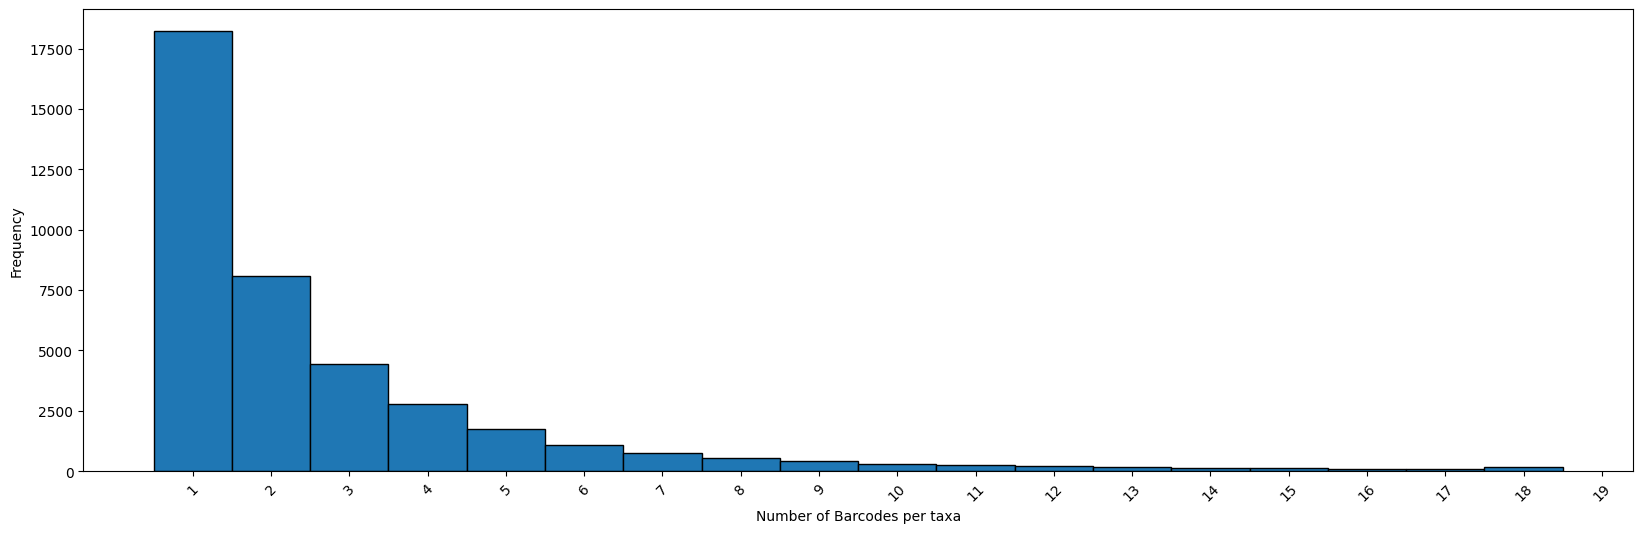

In [46]:
# histogram per number
counts
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
plt.hist(counts['count'], bins=range(1, 20), align='left', edgecolor='black')
plt.xlabel('Number of Barcodes per taxa')
plt.ylabel('Frequency')
plt.xticks(range(1, 20))
plt.xticks(rotation=45)
plt.show()

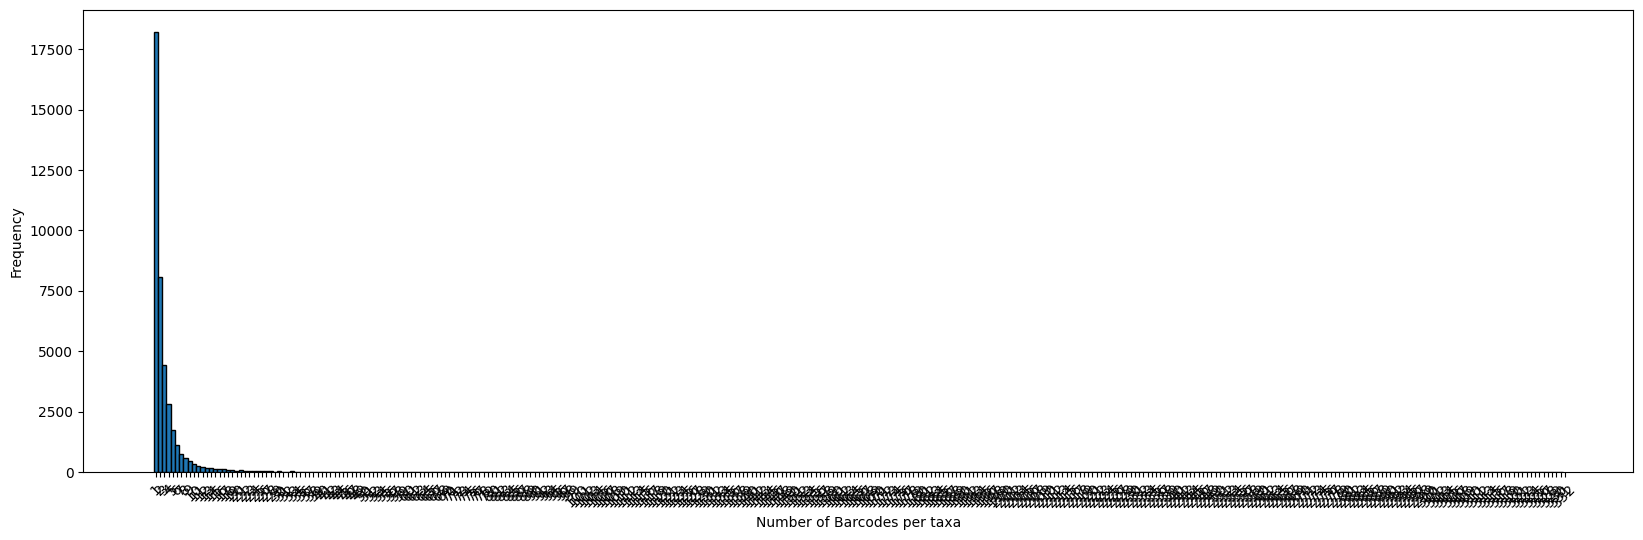

In [48]:
counts
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
plt.hist(counts['count'], bins=range(1, counts['count'].max()), align='left', edgecolor='black')
plt.xlabel('Number of Barcodes per taxa')
plt.ylabel('Frequency')
plt.xticks(range(1, counts['count'].max()))
plt.xticks(rotation=45)
plt.show()

In [25]:
counts_non_unique = counts[counts['count'] > 1]
counts_non_unique

,family,genus,species,count
0,Acanaloniidae,Acanalonia,Acanalonia bivittata,3
1,Acanaloniidae,Acanalonia,Acanalonia conica,2
7,Acanthochitonidae,Acanthochitona,Acanthochitona hemphilli,2
8,Acanthochitonidae,Acanthochitona,Acanthochitona lineata,4
9,Acanthochitonidae,Choneplax,Choneplax lata,3
...,...,...,...,...
40646,Zygaenidae,Triprocris,Triprocris smithsonianus,2
40653,Zygaenidae,Zygaena,Zygaena osterodensis,3
40654,Zygaenidae,Zygaena,Zygaena purpuralis,3
40656,Zygaenidae,Zygaena,Zygaena sarpedon,4


In [17]:
float(round(counts['count'].median(), 2))

2.0

In [21]:
counts['count'].mode()

0    1
Name: count, dtype: int64

In [29]:
float(round(counts_non_unique['count'].median(), 2))

3.0

In [32]:
counts_non_unique['count'].mode()

0    2
Name: count, dtype: int64

In [58]:
sup5 = counts[counts['count'] >=5]
n = sup5.shape[0]
n/counts.shape[0] * 100

17.546362339514978

In [53]:
sup5n = counts_non_unique[counts_non_unique['count'] > 4]
nn = sup5n.shape[0]
nn/counts_non_unique.shape[0] * 100

31.78719422537094

In [25]:
sup5 = counts[counts['count'] > 10]
n = sup5.shape[0]
n/counts.shape[0] * 100

5.474937281715776

In [34]:
sup5nn = counts_non_unique[counts_non_unique['count'] > 10]
nnn = sup5nn.shape[0]
nnn/counts_non_unique.shape[0] * 100

9.918460098917258